# ⚽ تخمین ارزش بازار بازیکنان EA Sports FC 26

**پروژه کامل Data Science — از پاک‌سازی و EDA تا Machine Learning و Deep Learning**

در این پروژه چهار فایل CSV از دو منبع مختلف رو با هم ترکیب می‌کنیم:

| فایل | منبع | محتوا |
|---|---|---|
| `ea_fc26_players.csv` | کارت‌های رسمی EA | همه‌ی بازیکنان (۱۶٬۲۲۸ نفر) با ویژگی‌های ریز، پست، PlayStyle و... |
| `ea_fc26_outfield.csv` | همان منبع | فقط بازیکنان میدانی + ستون سن |
| `ea_fc26_goalkeepers.csv` | همان منبع | فقط دروازه‌بان‌ها + ستون سن |
| `FC26_20250921.csv` | دیتابیس FC26 (نسخه‌ی ۱۹ سپتامبر ۲۰۲۵) | ارزش بازار، پتانسیل، دستمزد، قرارداد، شهرت بین‌المللی، سطح لیگ |

**هدف:** پیش‌بینی ارزش بازار بازیکن (`value_eur`) از روی رتبه، سن، پتانسیل، ویژگی‌های فنی و بدنی و شرایط باشگاه.

**نوع مسئله:** Regression — چون ارزش بازار به‌شدت چوله است، روی `log1p(value_eur)` مدل می‌سازیم.

**مراحل کلی:** بارگذاری و ادغام ← کیفیت داده و پاک‌سازی ← Feature Engineering ← EDA و آزمون‌های آماری ← Feature Selection ← ۱۲ مدل Machine Learning ← مدل‌های Deep Learning ← انتخاب بهترین مدل و ذخیره‌ی آن.

## 1. راهنمای دیتاست

In [1]:
from IPython.display import Markdown, display

display(Markdown("""
### 📌 توضیح کلی پروژه
دو منبع داده داریم که هر دو مربوط به بازی EA Sports FC 26 هستند:

- **منبع EA** (سه فایل): ویژگی‌های ریز هر بازیکن مثل `finishing`، `ballControl`، `reactions`، شش آمار اصلی کارت (`pac, sho, pas, dri, def, phy`)، پست، PlayStyleها و پای برتر.
- **منبع FC26** (یک فایل): اطلاعات اقتصادی و قراردادی مثل `value_eur`، `wage_eur`، `potential`، `international_reputation`، `league_level` و سال پایان قرارداد.

هر دو منبع از شناسه‌ی یکسان بازیکن استفاده می‌کنند (`id` در EA برابر `player_id` در FC26)، پس می‌شود آن‌ها را مستقیم join کرد.

### 🎯 متغیر هدف
`value_eur` — ارزش بازار بازیکن به یورو. به‌خاطر چولگی شدید، مدل‌سازی روی `log_value = log1p(value_eur)` انجام می‌شود.

### 🧾 معرفی ستون‌های مهم
| گروه | ستون‌ها |
|---|---|
| هویت | `id`, نام بازیکن، `team`, `nationality`, `league_name` |
| رتبه و رشد | `overall_rating` (رتبه‌ی EA)، `potential`، `age` |
| فیزیکی | `height`, `weight` |
| شش آمار اصلی کارت | `pac, sho, pas, dri, def, phy` |
| ویژگی‌های ریز فنی | `finishing`, `ball_control`, `vision`, `stamina`, ... (۲۹ ستون) |
| دروازه‌بانی | `gk_diving`, `gk_handling`, `gk_kicking`, `gk_positioning`, `gk_reflexes` |
| سبک بازی | `play_styles`, `play_styles_plus`, `skill_moves`, `weak_foot_ability`, `preferred_foot` |
| بازار و قرارداد | `value_eur`, `wage_eur`, `release_clause_eur`, `club_contract_valid_until_year`, `international_reputation`, `league_level` |

### ❓ سوال‌هایی که قرار است جواب بدهیم
1. ارزش بازار بیشتر تابع رتبه‌ی کلی است یا سن و پتانسیل هم نقش جدی دارند؟
2. منحنی «سن ← ارزش» چه شکلی است و ارزش در چه سنی اوج می‌گیرد؟
3. آیا میان دروازه‌بان، مدافع، هافبک و مهاجم تفاوت معنادار ارزشی وجود دارد؟
4. بازیکنان پنج لیگ بزرگ اروپا چقدر گران‌ترند؟
5. کدام ویژگی‌های ریز بیشترین اثر را روی ارزش دارند؟
6. بازیکنان میدانی از نظر آمار اصلی به چه گروه‌های سبک بازی تقسیم می‌شوند؟
7. یک مدل ML یا DL چقدر دقیق می‌تواند ارزش بازار را تخمین بزند؟
"""))


### 📌 توضیح کلی پروژه
دو منبع داده داریم که هر دو مربوط به بازی EA Sports FC 26 هستند:

- **منبع EA** (سه فایل): ویژگی‌های ریز هر بازیکن مثل `finishing`، `ballControl`، `reactions`، شش آمار اصلی کارت (`pac, sho, pas, dri, def, phy`)، پست، PlayStyleها و پای برتر.
- **منبع FC26** (یک فایل): اطلاعات اقتصادی و قراردادی مثل `value_eur`، `wage_eur`، `potential`، `international_reputation`، `league_level` و سال پایان قرارداد.

هر دو منبع از شناسه‌ی یکسان بازیکن استفاده می‌کنند (`id` در EA برابر `player_id` در FC26)، پس می‌شود آن‌ها را مستقیم join کرد.

### 🎯 متغیر هدف
`value_eur` — ارزش بازار بازیکن به یورو. به‌خاطر چولگی شدید، مدل‌سازی روی `log_value = log1p(value_eur)` انجام می‌شود.

### 🧾 معرفی ستون‌های مهم
| گروه | ستون‌ها |
|---|---|
| هویت | `id`, نام بازیکن، `team`, `nationality`, `league_name` |
| رتبه و رشد | `overall_rating` (رتبه‌ی EA)، `potential`، `age` |
| فیزیکی | `height`, `weight` |
| شش آمار اصلی کارت | `pac, sho, pas, dri, def, phy` |
| ویژگی‌های ریز فنی | `finishing`, `ball_control`, `vision`, `stamina`, ... (۲۹ ستون) |
| دروازه‌بانی | `gk_diving`, `gk_handling`, `gk_kicking`, `gk_positioning`, `gk_reflexes` |
| سبک بازی | `play_styles`, `play_styles_plus`, `skill_moves`, `weak_foot_ability`, `preferred_foot` |
| بازار و قرارداد | `value_eur`, `wage_eur`, `release_clause_eur`, `club_contract_valid_until_year`, `international_reputation`, `league_level` |

### ❓ سوال‌هایی که قرار است جواب بدهیم
1. ارزش بازار بیشتر تابع رتبه‌ی کلی است یا سن و پتانسیل هم نقش جدی دارند؟
2. منحنی «سن ← ارزش» چه شکلی است و ارزش در چه سنی اوج می‌گیرد؟
3. آیا میان دروازه‌بان، مدافع، هافبک و مهاجم تفاوت معنادار ارزشی وجود دارد؟
4. بازیکنان پنج لیگ بزرگ اروپا چقدر گران‌ترند؟
5. کدام ویژگی‌های ریز بیشترین اثر را روی ارزش دارند؟
6. بازیکنان میدانی از نظر آمار اصلی به چه گروه‌های سبک بازی تقسیم می‌شوند؟
7. یک مدل ML یا DL چقدر دقیق می‌تواند ارزش بازار را تخمین بزند؟


## 2. آماده‌سازی محیط و Import کتابخانه‌ها

In [2]:
import os, re, json, time, warnings, itertools
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"          # لاگ‌های اضافه‌ی TensorFlow رو ساکت می‌کنیم
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import Markdown, display
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.ensemble import (IsolationForest, RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor, AdaBoostRegressor, HistGradientBoostingRegressor)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)     # هشدار فرمت h5 رو نمایش نمی‌دیم
warnings.filterwarnings("ignore")

# تنظیمات کلی
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

# مسیر فایل‌ها: کنار Notebook یا یکی از این پوشه‌ها
SEARCH_DIRS = [Path("."), Path("data"), Path("dataset"), Path("/mnt/user-data/uploads")]
def find_file(fname):
    for d in SEARCH_DIRS:
        if (d / fname).exists():
            return d / fname
    raise FileNotFoundError(f"فایل {fname} پیدا نشد؛ کنار Notebook بذارش یا مسیرش رو به SEARCH_DIRS اضافه کن.")

# پوشه‌ی خروجی برای مدل‌ها و فایل‌های ذخیره‌شده
OUT_DIR = Path("fc26_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU") or "پیدا نشد (روی CPU اجرا می‌شود)")

I0000 00:00:1789915829.778549      89 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1789915850.265299      89 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: پیدا نشد (روی CPU اجرا می‌شود)


## 3. بارگذاری چهار فایل و نگاه اولیه

اول ببینیم چهار فایلی که دستمون رسیده هرکدوم چه شکلی هستند.

In [3]:
# اول هر چهار فایل رو می‌خونیم
df_players  = pd.read_csv(find_file("ea_fc26_players.csv"))
df_outfield = pd.read_csv(find_file("ea_fc26_outfield.csv"))
df_gk       = pd.read_csv(find_file("ea_fc26_goalkeepers.csv"))
df_fc26     = pd.read_csv(find_file("FC26_20250921.csv"), low_memory=False)

raw_files = {"players (EA)": df_players, "outfield (EA)": df_outfield,
             "goalkeepers (EA)": df_gk, "FC26_20250921": df_fc26}

# یه خلاصه‌ی سریع از هر فایل
def overview(d, name):
    miss = d.isna().mean()
    print(f"📄 {name}")
    print(f"   شکل: {d.shape} | ستون‌های عددی: {d.select_dtypes('number').shape[1]} | غیرعددی: {d.select_dtypes(exclude='number').shape[1]}")
    print(f"   ستون‌های دارای Missing: {(miss > 0).sum()} | بیشترین: {miss.idxmax()} ({miss.max():.1%}) | ردیف تکراری: {d.duplicated().sum()}")

for name, d in raw_files.items():
    overview(d, name)

📄 players (EA)
   شکل: (16228, 60) | ستون‌های عددی: 48 | غیرعددی: 12
   ستون‌های دارای Missing: 4 | بیشترین: playStylesPlus (99.3%) | ردیف تکراری: 0
📄 outfield (EA)
   شکل: (14412, 56) | ستون‌های عددی: 44 | غیرعددی: 12
   ستون‌های دارای Missing: 4 | بیشترین: playStylesPlus (99.2%) | ردیف تکراری: 0
📄 goalkeepers (EA)
   شکل: (1816, 26) | ستون‌های عددی: 15 | غیرعددی: 11
   ستون‌های دارای Missing: 4 | بیشترین: alternatePositions (100.0%) | ردیف تکراری: 0
📄 FC26_20250921
   شکل: (18405, 110) | ستون‌های عددی: 64 | غیرعددی: 46
   ستون‌های دارای Missing: 24 | بیشترین: work_rate (100.0%) | ردیف تکراری: 0


In [4]:
# نمونه‌ای از هر فایل
display(df_players.head(3))
display(df_fc26.iloc[:3, :30])

,id,rank,overallRating,firstName,lastName,commonName,birthdate,height,weight,skillMoves,weakFootAbility,preferredFoot,position,positionType,alternatePositions,nationality,team,leagueName,playStyles,playStylesPlus,pac,sho,pas,dri,def,phy,acceleration,sprintSpeed,finishing,shotPower,longShots,volleys,penalties,positioning,shortPassing,longPassing,curve,freeKickAccuracy,crossing,vision,dribbling,ballControl,agility,balance,reactions,composure,interceptions,defensiveAwareness,standingTackle,slidingTackle,headingAccuracy,aggression,jumping,stamina,strength,gkDiving,gkHandling,gkKicking,gkPositioning,gkReflexes
0,209331,1,91,Mohamed,Salah,NaN,6/15/1992 12:00:00 AM,175,72,4,3,2,RM,Midfielder,RW,Egypt,Liverpool,Premier League,"Low Driven Shot,Gamechanger,Whipped Pass,Inven...",Finesse Shot+,89,88,86,90,45,76,88,89,94,83,78,83,88,93,88,81,88,69,86,89,90,90,86,91,94,93,55,38,43,41,59,63,79,88,75,14,14,9,11,14
1,231747,3,91,Kylian,Mbappé,NaN,12/20/1998 12:00:00 AM,182,75,5,4,1,ST,Attack,"LW,LM",France,Real Madrid,LALIGA EA SPORTS,"Finesse Shot,Acrobatic,Low Driven Shot,Gamecha...",Quick Step+,97,90,81,92,37,76,97,97,92,91,86,87,82,91,87,74,80,69,78,83,92,93,93,82,91,88,38,26,34,32,78,61,90,83,77,13,5,7,11,6
2,231443,5,90,Ousmane,Dembélé,NaN,5/15/1997 12:00:00 AM,178,67,5,5,2,ST,Attack,"RW,CAM",France,Paris SG,Ligue 1 McDonald's,"Low Driven Shot,Pinged Pass,Inventive,Trickste...",Rapid+,91,88,83,93,50,69,93,89,90,91,85,79,80,95,89,78,85,68,80,84,94,94,94,81,91,88,45,49,49,39,74,58,84,76,69,6,6,14,10,13


,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,league_id,league_name,league_level,club_team_id,club_name,club_position,club_jersey_number,club_loaned_from,club_joined_date,club_contract_valid_until_year,nationality_id,nationality_name,nation_team_id,nation_position
0,252371,/player/252371/jude-bellingham/260004/,26,4,2025-09-19,J. Bellingham,Jude Victor William Bellingham,"CAM, CM",90,94,174500000,320000,22,2003-06-29,186,75,53.0,La Liga,1.0,243.0,Real Madrid,CAM,5.0,NaN,2023-07-01,2029.0,14,England,1318.0,CAM
1,239053,/player/239053/federico-valverde/260004/,26,4,2025-09-19,F. Valverde,Federico Santiago Valverde Dipetta,"CM, CDM, RB",89,90,120500000,340000,26,1998-07-22,182,74,53.0,La Liga,1.0,243.0,Real Madrid,RDM,8.0,NaN,2016-07-22,2029.0,60,Uruguay,NaN,NaN
2,212622,/player/212622/joshua-kimmich/260004/,26,4,2025-09-19,J. Kimmich,Joshua Walter Kimmich,"CDM, RB, CM",89,89,86000000,140000,30,1995-02-08,177,75,19.0,Bundesliga,1.0,21.0,FC Bayern München,RDM,6.0,NaN,2015-07-01,2029.0,21,Germany,1337.0,RCM


In [5]:
# اطلاعات کامل فایل اصلی EA
df_players.info()

<class 'pandas.DataFrame'>
RangeIndex: 16228 entries, 0 to 16227
Data columns (total 60 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  16228 non-null  int64
 1   rank                16228 non-null  int64
 2   overallRating       16228 non-null  int64
 3   firstName           16228 non-null  str  
 4   lastName            16228 non-null  str  
 5   commonName          2354 non-null   str  
 6   birthdate           16228 non-null  str  
 7   height              16228 non-null  int64
 8   weight              16228 non-null  int64
 9   skillMoves          16228 non-null  int64
 10  weakFootAbility     16228 non-null  int64
 11  preferredFoot       16228 non-null  int64
 12  position            16228 non-null  str  
 13  positionType        16228 non-null  str  
 14  alternatePositions  10485 non-null  str  
 15  nationality         16228 non-null  str  
 16  team                16228 non-null  str  
 17  leag

In [6]:
# آمار توصیفی ستون‌های عددی مهم در دو منبع
display(df_players[["overallRating", "height", "weight", "skillMoves", "weakFootAbility", "pac", "sho", "pas", "dri", "def", "phy"]].describe().T)
display(df_fc26[["overall", "potential", "value_eur", "wage_eur", "age", "international_reputation", "league_level"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
overallRating,16228.0,66.241126,6.823219,47.0,62.0,66.0,70.0,91.0
height,16228.0,182.104018,6.895519,155.0,177.0,182.0,187.0,210.0
weight,16228.0,75.283276,6.932973,47.0,70.0,75.0,80.0,105.0
skillMoves,16228.0,2.375770,0.774531,1.0,2.0,2.0,3.0,5.0
weakFootAbility,16228.0,2.943493,0.669765,1.0,3.0,3.0,3.0,5.0
pac,16228.0,68.151836,10.435775,30.0,62.0,69.0,75.0,97.0
sho,16228.0,54.346069,13.717709,21.0,45.0,57.0,64.0,92.0
pas,16228.0,58.602662,9.615111,25.0,52.0,59.0,65.0,92.0
dri,16228.0,63.659354,9.126835,29.0,58.0,64.0,70.0,93.0
def,16228.0,50.563902,16.533785,15.0,36.0,55.0,64.0,90.0


,count,mean,std,min,25%,50%,75%,max
overall,18405.0,6.576697e+01,6.980628e+00,47.0,61.0,66.0,70.0,91.0
potential,18405.0,7.116517e+01,6.403862e+00,49.0,67.0,71.0,75.0,95.0
value_eur,18405.0,2.931633e+06,7.947787e+06,0.0,475000.0,1000000.0,2100000.0,174500000.0
wage_eur,18405.0,1.009606e+04,2.008298e+04,0.0,1000.0,4000.0,10000.0,610000.0
age,18405.0,2.522255e+01,4.773553e+00,16.0,21.0,25.0,29.0,44.0
international_reputation,18405.0,1.077968e+00,3.871942e-01,1.0,1.0,1.0,1.0,5.0
league_level,18316.0,1.396702e+00,7.646846e-01,1.0,1.0,1.0,2.0,4.0


In [7]:
# تعداد مقادیر یکتا در ستون‌های دسته‌ای
cat_cols_ea = ["position", "positionType", "preferredFoot", "nationality", "team", "leagueName"]
print("EA:", {c: df_players[c].nunique() for c in cat_cols_ea})
cat_cols_fc = ["league_name", "club_name", "nationality_name", "preferred_foot", "body_type", "work_rate"]
print("FC26:", {c: df_fc26[c].nunique() for c in cat_cols_fc})

EA: {'position': 12, 'positionType': 3, 'preferredFoot': 2, 'nationality': 156, 'team': 642, 'leagueName': 45}
FC26: {'league_name': 42, 'club_name': 662, 'nationality_name': 160, 'preferred_foot': 2, 'body_type': 10, 'work_rate': 0}


## 4. رابطه‌ی فایل‌ها با هم

قبل از ادغام باید مطمئن بشیم فایل‌های `outfield` و `goalkeepers` دقیقاً چه نسبتی با فایل `players` دارند و آیا شناسه‌ها با فایل FC26 جور هستند.

In [8]:
# آیا outfield + goalkeepers دقیقاً همون players هستن؟
ids_p, ids_o, ids_g = set(df_players["id"]), set(df_outfield["id"]), set(df_gk["id"])
print("تعداد بازیکن‌های مشترک بین outfield و goalkeepers:", len(ids_o & ids_g))
print("اجتماع outfield و goalkeepers برابر players است؟", (ids_o | ids_g) == ids_p)
print(f"players={len(ids_p)} | outfield={len(ids_o)} | goalkeepers={len(ids_g)} | مجموع={len(ids_o)+len(ids_g)}")

# ستون‌های مشترک هر فایل جدا با فایل players چقدر با هم یکی‌اند؟
# (فرمت تاریخ تولد در دو فایل فرق داره، پس اول یکدستش می‌کنیم)
def check_split(split_df, name):
    m = split_df.merge(df_players, on="id", suffixes=("_split", "_full"))
    cols = [c for c in split_df.columns if c in df_players.columns and c not in ("id", "birthdate")]
    rates = {c: ((m[c + "_split"] == m[c + "_full"]) | (m[c + "_split"].isna() & m[c + "_full"].isna())).mean() for c in cols}
    bd = (pd.to_datetime(m["birthdate_split"]) == pd.to_datetime(m["birthdate_full"], format="%m/%d/%Y %I:%M:%S %p")).mean()
    print(f"{name}: {len(m)} ردیف | کمترین تطابق در {len(cols)} ستون مشترک = {min(rates.values()):.0%} | تطابق تاریخ تولد = {bd:.0%}")

check_split(df_outfield, "outfield")
check_split(df_gk, "goalkeepers")
ea_check = pd.concat([df_outfield, df_gk], ignore_index=True)
print("ستون‌های اضافه در فایل‌های جدا (نسبت به players):", [c for c in ea_check.columns if c not in df_players.columns])

تعداد بازیکن‌های مشترک بین outfield و goalkeepers: 0
اجتماع outfield و goalkeepers برابر players است؟ True
players=16228 | outfield=14412 | goalkeepers=1816 | مجموع=16228
outfield: 14412 ردیف | کمترین تطابق در 53 ستون مشترک = 100% | تطابق تاریخ تولد = 100%
goalkeepers: 1816 ردیف | کمترین تطابق در 23 ستون مشترک = 100% | تطابق تاریخ تولد = 100%
ستون‌های اضافه در فایل‌های جدا (نسبت به players): ['age']


In [9]:
# نکته‌ی مهم درباره‌ی دروازه‌بان‌ها:
# توی فایل EA شش آمار اصلی کارت (pac, sho, ...) برای دروازه‌بان‌ها همون آمار GK هستن
gk_rows = df_players[df_players["position"] == "GK"]
alias = {"pac": "gkDiving", "sho": "gkHandling", "pas": "gkKicking", "dri": "gkReflexes", "phy": "gkPositioning"}
for face, gk_col in alias.items():
    print(f"{face:>3} == {gk_col:<14} -> {(gk_rows[face] == gk_rows[gk_col]).mean():.0%}")

# و positionType دروازه‌بان‌ها چی ثبت شده؟
print()
print(gk_rows["positionType"].value_counts())

pac == gkDiving       -> 100%
sho == gkHandling     -> 100%
pas == gkKicking      -> 100%
dri == gkReflexes     -> 100%
phy == gkPositioning  -> 100%

positionType
Defense    1816
Name: count, dtype: int64


In [10]:
# شناسه‌ها بین EA و FC26 چقدر جور هستن؟
chk = df_players[["id"]].merge(df_fc26[["player_id"]].rename(columns={"player_id": "id"}), on="id", how="outer", indicator=True)
print(chk["_merge"].map({"both": "هر دو فایل", "left_only": "فقط EA", "right_only": "فقط FC26"}).value_counts())

only_fc = df_fc26[~df_fc26["player_id"].isin(df_players["id"])]
only_ea = df_players[~df_players["id"].isin(df_fc26["player_id"])]
print("\nفقط در FC26 — بیشترین لیگ‌ها:")
print(only_fc["league_name"].value_counts(dropna=False).head(5))
print("\nفقط در FC26 — میانگین overall:", round(only_fc["overall"].mean(), 1), "| میانگین overall در کل FC26:", round(df_fc26["overall"].mean(), 1))
print("\nفقط در EA — نمونه:")
display(only_ea[["id", "firstName", "lastName", "overallRating", "team", "leagueName"]].head(5))

_merge
هر دو فایل    16122
فقط FC26       2283
فقط EA          106
Name: count, dtype: int64

فقط در FC26 — بیشترین لیگ‌ها:
league_name
Série A          280
Super League     177
Pro League       172
La Liga 2        169
Primeira Liga    136
Name: count, dtype: int64

فقط در FC26 — میانگین overall: 62.0 | میانگین overall در کل FC26: 65.8

فقط در EA — نمونه:


,id,firstName,lastName,overallRating,team,leagueName
1220,205083,Fayçal,Fajr,76,Al Taawoun,ROSHN Saudi League
1710,269456,Muhammed,Cham,75,Slavia Praha,Česká Liga
1906,263059,Tomás Romano,dos Santos Händel,74,Red Star FC,Ligue 2 BKT
2767,223198,Ali,Adnan,72,Al Najmah,ROSHN Saudi League
3173,245694,Adama,Traoré,72,Gençlerbirliği,Trendyol Süper Lig


In [11]:
print("""برداشت اولیه:
- فایل‌های outfield (۱۴٬۴۱۲) و goalkeepers (۱۸۱۶) دقیقاً همون فایل players (۱۶٬۲۲۸) هستن که به دو بخش شکسته شده؛ هیچ بازیکن مشترکی ندارن، همه‌ی ستون‌های مشترک ۱۰۰٪ یکسانه و فقط ستون `age` اضافه دارن.
- برای دروازه‌بان‌ها شش آمار اصلی کارت همون آمار GK هستن (pac = gkDiving و ...) و EA اون‌ها رو با positionType «Defense» ثبت کرده. پس آمار اصلی بین GK و بازیکن میدانی قابل مقایسه نیست؛ برای همین `pos_group` و `is_gk` رو خودمون می‌سازیم.
- ۱۶٬۱۲۲ بازیکن در هر دو منبع هستن، ۲٬۲۸۳ بازیکن فقط در FC26 و ۱۰۶ بازیکن فقط در EA. گروه «فقط FC26» ضعیف‌تره (میانگین رتبه ۶۲ در برابر ۶۵٫۸) و بیشترین‌شون از Série A (برزیل) هستن؛ پس Inner Join بیشتر بازیکن‌های ضعیف‌تر رو از دست می‌ده، ولی نمونه‌ی ۱۶ هزارتایی برای مدل‌سازی کافیه.
""")

برداشت اولیه:
- فایل‌های outfield (۱۴٬۴۱۲) و goalkeepers (۱۸۱۶) دقیقاً همون فایل players (۱۶٬۲۲۸) هستن که به دو بخش شکسته شده؛ هیچ بازیکن مشترکی ندارن، همه‌ی ستون‌های مشترک ۱۰۰٪ یکسانه و فقط ستون `age` اضافه دارن.
- برای دروازه‌بان‌ها شش آمار اصلی کارت همون آمار GK هستن (pac = gkDiving و ...) و EA اون‌ها رو با positionType «Defense» ثبت کرده. پس آمار اصلی بین GK و بازیکن میدانی قابل مقایسه نیست؛ برای همین `pos_group` و `is_gk` رو خودمون می‌سازیم.
- ۱۶٬۱۲۲ بازیکن در هر دو منبع هستن، ۲٬۲۸۳ بازیکن فقط در FC26 و ۱۰۶ بازیکن فقط در EA. گروه «فقط FC26» ضعیف‌تره (میانگین رتبه ۶۲ در برابر ۶۵٫۸) و بیشترین‌شون از Série A (برزیل) هستن؛ پس Inner Join بیشتر بازیکن‌های ضعیف‌تر رو از دست می‌ده، ولی نمونه‌ی ۱۶ هزارتایی برای مدل‌سازی کافیه.



## 5. ادغام دیتاست‌ها

روش کار: اول ستون‌های EA رو `snake_case` می‌کنیم، ستون سن از فایل‌های `outfield` و `goalkeepers` رو به `players` اضافه می‌کنیم، بعد با `id` به FC26 وصل می‌کنیم. از FC26 فقط ستون‌هایی رو می‌آوریم که در EA نیستند.

In [12]:
# اسم ستون‌های EA رو یکدست می‌کنیم
def to_snake(c):
    return re.sub(r"(?<!^)(?=[A-Z])", "_", c).lower()

ea = df_players.rename(columns={c: to_snake(c) for c in df_players.columns})
# شش آمار اصلی کارت رو با اسم‌های واضح‌تر می‌نویسیم (با ستون‌های ریز هم‌نام نشن)
ea = ea.rename(columns={"pac": "face_pace", "sho": "face_shooting", "pas": "face_passing",
                        "dri": "face_dribbling", "def": "face_defending", "phy": "face_physical"})

# گروه‌بندی ستون‌های ویژگی که بعداً لازم می‌شن
face_stats = ["face_pace", "face_shooting", "face_passing", "face_dribbling", "face_defending", "face_physical"]
detail_attrs = ["acceleration", "sprint_speed", "finishing", "shot_power", "long_shots", "volleys", "penalties",
                "positioning", "short_passing", "long_passing", "curve", "free_kick_accuracy", "crossing", "vision",
                "dribbling", "ball_control", "agility", "balance", "reactions", "composure", "interceptions",
                "defensive_awareness", "standing_tackle", "sliding_tackle", "heading_accuracy", "aggression",
                "jumping", "stamina", "strength"]
gk_attrs = ["gk_diving", "gk_handling", "gk_kicking", "gk_positioning", "gk_reflexes"]

# ستون سن و نوع بازیکن از فایل‌های جدا
ages = pd.concat([df_outfield[["id", "age"]].assign(player_type="outfield"),
                  df_gk[["id", "age"]].assign(player_type="goalkeeper")], ignore_index=True)
ages = ages.rename(columns={"age": "age_ea"})
ea = ea.merge(ages, on="id", how="left", validate="one_to_one")

# از FC26 فقط ستون‌های اقتصادی و قراردادی
fc = df_fc26[["player_id", "overall", "potential", "value_eur", "wage_eur", "age", "international_reputation",
              "league_level", "club_name", "club_contract_valid_until_year", "release_clause_eur"]].copy()
fc = fc.rename(columns={"player_id": "id", "overall": "overall_fc26"})

# ادغام: فقط بازیکن‌هایی که در هر دو منبع هستن
df = ea.merge(fc, on="id", how="inner", validate="one_to_one")
print("EA:", ea.shape, "| FC26 (ستون‌های انتخابی):", fc.shape, "| نتیجه‌ی ادغام:", df.shape)
display(df[["id", "first_name", "last_name", "position", "team", "overall_rating", "overall_fc26", "potential", "age", "age_ea", "value_eur", "wage_eur"]].head())

EA: (16228, 62) | FC26 (ستون‌های انتخابی): (18405, 11) | نتیجه‌ی ادغام: (16122, 72)


,id,first_name,last_name,position,team,overall_rating,overall_fc26,potential,age,age_ea,value_eur,wage_eur
0,209331,Mohamed,Salah,RM,Liverpool,91,91,91,33,33,82000000,370000
1,231747,Kylian,Mbappé,ST,Real Madrid,91,91,94,26,27,173500000,610000
2,231443,Ousmane,Dembélé,ST,Paris SG,90,90,90,28,28,122500000,220000
3,231866,Rodrigo,Hernández Cascante,CDM,Manchester City,90,90,90,29,29,102000000,270000
4,203376,Virgil,van Dijk,CB,Liverpool,90,90,90,33,34,57000000,230000


In [13]:
# دو تا کنترل سریع روی ادغام:
# ۱) رتبه‌ی کلی در دو منبع چقدر شبیه هم هست؟
print("overall EA == overall FC26:", f"{(df['overall_rating'] == df['overall_fc26']).mean():.1%}",
      "| همبستگی:", round(df[["overall_rating", "overall_fc26"]].corr().iloc[0, 1], 4))

# ۲) پای برتر (کد ۱ و ۲ در EA) با متن FC26 جور هست؟ (همین کنترل، کدگذاری رو هم مشخص می‌کنه)
foot_fc = df_fc26.set_index("player_id")["preferred_foot"]
print(pd.crosstab(df["preferred_foot"], df["id"].map(foot_fc), rownames=["EA code"], colnames=["FC26"]))

# ۳) سن EA با سن FC26 چه رابطه‌ای دارد؟ (اگه فرق داشته باشه یعنی دو فایل مربوط به زمان‌های متفاوتن)
print("\nسن EA منهای سن FC26:", (df["age_ea"] - df["age"]).value_counts().to_dict())

# سن رو از روی تاریخ تولد برای چند تاریخ محاسبه می‌کنیم و می‌بینیم سن EA به کدوم تاریخ نزدیک‌تره
bd = pd.to_datetime(df["birthdate"], format="%m/%d/%Y %I:%M:%S %p")
def age_on(birth, date):
    d = pd.Timestamp(date)
    return d.year - birth.dt.year - ((birth.dt.month > d.month) | ((birth.dt.month == d.month) & (birth.dt.day > d.day))).astype(int)

for d in ["2025-09-19", "2026-01-01", "2026-03-01", "2026-04-01", "2026-05-01", "2026-06-01"]:
    print(f"سن محاسبه‌شده در {d} -> تطابق با سن EA: {(age_on(bd, d) == df['age_ea']).mean():.1%}")

overall EA == overall FC26: 96.1% | همبستگی: 0.999
FC26     Left  Right
EA code             
1           5  12200
2        3914      3

سن EA منهای سن FC26: {1: 11237, 0: 4885}
سن محاسبه‌شده در 2025-09-19 -> تطابق با سن EA: 50.2%
سن محاسبه‌شده در 2026-01-01 -> تطابق با سن EA: 73.3%
سن محاسبه‌شده در 2026-03-01 -> تطابق با سن EA: 94.4%
سن محاسبه‌شده در 2026-04-01 -> تطابق با سن EA: 95.6%
سن محاسبه‌شده در 2026-05-01 -> تطابق با سن EA: 86.7%
سن محاسبه‌شده در 2026-06-01 -> تطابق با سن EA: 77.7%


In [14]:
print("""برداشت اولیه:
- رتبه‌ی کلی در دو منبع در ۹۶٪ موارد دقیقاً یکسانه (همبستگی ۰٫۹۹۹)؛ ادغام روی `id` درست کار کرده.
- کدگذاری پای برتر در EA تأیید شد: ۱ = Right و ۲ = Left (فقط چند مورد اختلاف).
- سن EA در حدود ۷۰٪ بازیکن‌ها یک سال بیشتر از سن FC26 است. با محاسبه‌ی سن از روی تاریخ تولد، سن EA بیشترین تطابق (حدود ۹۶٪) رو با اوایل آوریل ۲۰۲۶ داره؛ یعنی فایل‌های EA حدود ۶ ماه دیرتر از فایل FC26 (۱۹ سپتامبر ۲۰۲۵) هستن. برای همین سنِ هم‌زمان با ارزش بازار (`age` از FC26) رو در مدل استفاده می‌کنیم و `age_ea` رو کنار می‌ذاریم.
""")

برداشت اولیه:
- رتبه‌ی کلی در دو منبع در ۹۶٪ موارد دقیقاً یکسانه (همبستگی ۰٫۹۹۹)؛ ادغام روی `id` درست کار کرده.
- کدگذاری پای برتر در EA تأیید شد: ۱ = Right و ۲ = Left (فقط چند مورد اختلاف).
- سن EA در حدود ۷۰٪ بازیکن‌ها یک سال بیشتر از سن FC26 است. با محاسبه‌ی سن از روی تاریخ تولد، سن EA بیشترین تطابق (حدود ۹۶٪) رو با اوایل آوریل ۲۰۲۶ داره؛ یعنی فایل‌های EA حدود ۶ ماه دیرتر از فایل FC26 (۱۹ سپتامبر ۲۰۲۵) هستن. برای همین سنِ هم‌زمان با ارزش بازار (`age` از FC26) رو در مدل استفاده می‌کنیم و `age_ea` رو کنار می‌ذاریم.



## 6. بررسی کیفیت داده

چند چیز رو چک می‌کنیم: Missing، ردیف تکراری، مقادیر غیرمنطقی و ستون‌هایی که بهتره کنار گذاشته بشن.

,missing,percent
play_styles_plus,16003,99.26
common_name,13775,85.44
play_styles,8824,54.73
alternate_positions,5707,35.40
release_clause_eur,1218,7.55


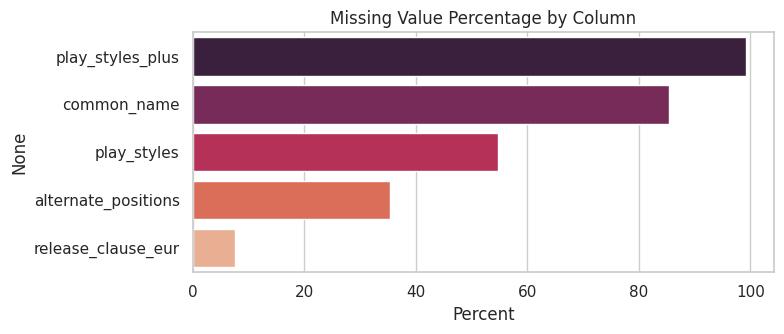

In [15]:
# Missing Values در دیتاست ادغام‌شده
missing = pd.DataFrame({"missing": df.isna().sum(), "percent": (df.isna().mean() * 100).round(2)})
missing = missing[missing["missing"] > 0].sort_values("percent", ascending=False)
display(missing)

plt.figure(figsize=(8, 3.5))
sns.barplot(x=missing["percent"], y=missing.index, hue=missing.index, palette="rocket", legend=False)
plt.title("Missing Value Percentage by Column")
plt.xlabel("Percent")
plt.tight_layout()
plt.show()

In [16]:
# این Missingها واقعاً «داده‌ی گمشده» هستن یا یعنی «ندارد»؟
# اینجا احتمالاً NaN در play_styles و alternate_positions یعنی بازیکن هیچ مورد ثبت‌شده‌ای نداره
print("بازیکن‌های بدون PlayStyle:", df["play_styles"].isna().sum())
print("بازیکن‌های بدون PlayStyle+:", df["play_styles_plus"].isna().sum())
print("بازیکن‌های بدون پست جایگزین:", df["alternate_positions"].isna().sum())
print("ردیف تکراری:", df.duplicated().sum(), "| id تکراری:", df["id"].duplicated().sum())

# مقادیر غیرمنطقی؟
print("\nvalue_eur = 0 :", (df["value_eur"] == 0).sum(), "ردیف")
print("wage_eur = 0  :", (df["wage_eur"] == 0).sum(), "ردیف")
display(df.loc[df["value_eur"] == 0, ["first_name", "last_name", "overall_rating", "age", "team", "wage_eur"]].head(8))

attr_cols = face_stats + detail_attrs + gk_attrs
print("\nمحدوده‌ی ویژگی‌های فنی (بین ۰ تا ۱۰۰ باید باشه):", int(df[attr_cols].min().min()), "تا", int(df[attr_cols].max().max()))
print("قد:", df["height"].min(), "-", df["height"].max(), "| وزن:", df["weight"].min(), "-", df["weight"].max())
print("سال پایان قرارداد:", int(df["club_contract_valid_until_year"].min()), "تا", int(df["club_contract_valid_until_year"].max()))

بازیکن‌های بدون PlayStyle: 8824
بازیکن‌های بدون PlayStyle+: 16003
بازیکن‌های بدون پست جایگزین: 5707


ردیف تکراری: 0 | id تکراری: 0

value_eur = 0 : 15 ردیف
wage_eur = 0  : 0 ردیف


,first_name,last_name,overall_rating,age,team,wage_eur
89,C. Ronaldo,dos Santos Aveiro,85,40,Al Nassr,58000
862,Dante Bonfim,Costa Santos,78,41,OGC Nice,19000
1584,Santiago,Cazorla González,75,40,R. Oviedo,21000
2588,José,Sosa,73,40,Estudiantes,9000
2641,Hernán,Barcos,73,41,Alianza Lima,18000
3352,Paolo,Guerrero,72,41,Alianza Lima,17000
3361,José Miguel,da Rocha Fonte,72,41,Casa Pia AC,5000
3889,Lukas,Podolski,71,40,Górnik Zabrze,5000



محدوده‌ی ویژگی‌های فنی (بین ۰ تا ۱۰۰ باید باشه): 2 تا 97
قد: 155 - 210 | وزن: 47 - 105
سال پایان قرارداد: 2025 تا 2035


In [17]:
print("""برداشت اولیه:
- بیشترین Missing در `play_styles_plus` (۹۹٪)، `common_name` (۸۵٪)، `play_styles` (۵۵٪) و `alternate_positions` (۳۵٪) هست؛ ولی این‌ها واقعاً «گمشده» نیستن و یعنی بازیکن چنین چیزی نداره.
- ردیف یا id تکراری نداریم و ویژگی‌های فنی در محدوده‌ی منطقی (۲ تا ۹۷) هستن.
- ۱۵ بازیکن ارزش صفر دارن و همه ۴۰ ساله یا بالاترن (مثلاً رونالدو با رتبه‌ی ۸۵). این صفرها یعنی «ارزش‌گذاری نشده»، نه ارزش واقعی؛ پس حذفشون منطقیه.
""")

برداشت اولیه:
- بیشترین Missing در `play_styles_plus` (۹۹٪)، `common_name` (۸۵٪)، `play_styles` (۵۵٪) و `alternate_positions` (۳۵٪) هست؛ ولی این‌ها واقعاً «گمشده» نیستن و یعنی بازیکن چنین چیزی نداره.
- ردیف یا id تکراری نداریم و ویژگی‌های فنی در محدوده‌ی منطقی (۲ تا ۹۷) هستن.
- ۱۵ بازیکن ارزش صفر دارن و همه ۴۰ ساله یا بالاترن (مثلاً رونالدو با رتبه‌ی ۸۵). این صفرها یعنی «ارزش‌گذاری نشده»، نه ارزش واقعی؛ پس حذفشون منطقیه.



## 7. پاک‌سازی داده‌ها

تصمیم‌ها:
- بازیکن‌هایی که `value_eur = 0` دارند حذف می‌شوند، چون ارزش صفر یعنی «ارزش‌گذاری نشده» و در لگاریتم هم مشکل ایجاد می‌کند.
- NaN در `play_styles`, `play_styles_plus`, `alternate_positions` یعنی «ندارد»، پس با رشته‌ی خالی پر می‌شود.
- پای برتر EA از کد عددی به متن تبدیل می‌شود (۱ = Right، ۲ = Left؛ در کنترل بالا تأیید شد).
- تاریخ تولد به datetime تبدیل و اسم بازیکن یکپارچه می‌شود.
- ستون‌های `wage_eur` و `release_clause_eur` بعداً **از مدل کنار گذاشته می‌شوند**؛ چرا؟ در بخش Feature Selection توضیح می‌دهیم.

In [18]:
rows_before = len(df)

# ارزش صفر رو حذف می‌کنیم
df = df[df["value_eur"] > 0].copy()
print(f"حذف بازیکن‌های بدون ارزش: {rows_before} -> {len(df)}")

# ستون‌های متنی که NaN یعنی ندارد
for c in ["play_styles", "play_styles_plus", "alternate_positions"]:
    df[c] = df[c].fillna("")

# پای برتر و تاریخ تولد
df["preferred_foot"] = df["preferred_foot"].map({1: "Right", 2: "Left"})
df["birthdate"] = pd.to_datetime(df["birthdate"], format="%m/%d/%Y %I:%M:%S %p")

# اسم بازیکن: اگه common_name داره اون، وگرنه نام + نام‌خانوادگی
df["player_name"] = df["common_name"].fillna(df["first_name"].fillna("") + " " + df["last_name"].fillna(""))
df = df.drop(columns=["common_name", "first_name", "last_name"])

df = df.reset_index(drop=True)
print("شکل بعد از پاک‌سازی:", df.shape)
print("Missing باقی‌مانده در ستون‌های کلیدی:", df[["value_eur", "potential", "overall_rating", "age", "league_level", "club_contract_valid_until_year"]].isna().sum().sum())

حذف بازیکن‌های بدون ارزش: 16122 -> 16107
شکل بعد از پاک‌سازی: (16107, 70)
Missing باقی‌مانده در ستون‌های کلیدی: 0


## 8. Feature Engineering

ویژگی‌های جدیدی که به‌نظر می‌رسه به مدل کمک کنند:

- `pos_group`: گروه پست (GK / DEF / MID / ATT). چون EA دروازه‌بان‌ها رو در `position_type` جزو «Defense» ثبت کرده، خودمون درستش می‌کنیم.
- `is_gk`: دروازه‌بان است یا نه.
- `potential_gap`: فاصله‌ی پتانسیل تا رتبه‌ی فعلی (نشانه‌ی ظرفیت رشد).
- `contract_years_left`: چند سال از قرارداد باقی مانده.
- `bmi`: شاخص توده‌ی بدنی.
- `n_play_styles`, `n_play_styles_plus`, `n_alt_positions`: تعداد PlayStyle، PlayStyle+ و پست‌های جایگزین.
- `top5_league`: بازیکن در یکی از ۵ لیگ بزرگ اروپاست یا نه.
- `age_group` و `is_wonderkid`: برای EDA و آزمون‌های آماری.
- `log_value`: هدف نهایی (`log1p(value_eur)`).

In [19]:
# گروه پست: از position_type خود EA استفاده می‌کنیم و فقط دروازه‌بان‌ها رو اصلاح می‌کنیم
df["pos_group"] = df["position_type"].map({"Defense": "DEF", "Midfielder": "MID", "Attack": "ATT"})
df.loc[df["position"] == "GK", "pos_group"] = "GK"
df["is_gk"] = (df["position"] == "GK").astype(int)

# رشد و قرارداد
df["potential_gap"] = df["potential"] - df["overall_rating"]
df["contract_years_left"] = df["club_contract_valid_until_year"] - 2025      # مبنای دیتاست FC26: سپتامبر ۲۰۲۵

# بدنی
df["bmi"] = df["weight"] / (df["height"] / 100) ** 2

# سبک بازی
count_items = lambda s: s.apply(lambda x: 0 if x == "" else len(x.split(",")))
df["n_play_styles"] = count_items(df["play_styles"])
df["n_play_styles_plus"] = count_items(df["play_styles_plus"])
df["n_alt_positions"] = count_items(df["alternate_positions"])

# ۵ لیگ بزرگ (با اسم‌های موجود در دیتای EA)
top5 = ["Premier League", "LALIGA EA SPORTS", "Bundesliga", "Serie A Enilive", "Ligue 1 McDonald's"]
df["top5_league"] = df["league_name"].isin(top5).astype(int)

# گروه سنی و ستاره‌ی جوان
df["age_group"] = pd.cut(df["age"], bins=[0, 21, 25, 29, 33, 60], labels=["<=21", "22-25", "26-29", "30-33", "34+"])
df["is_wonderkid"] = ((df["age"] <= 21) & (df["potential"] >= 80)).astype(int)

# هدف: لگاریتم ارزش
df["log_value"] = np.log1p(df["value_eur"])

print("چولگی value_eur  :", round(df["value_eur"].skew(), 2))
print("چولگی log_value  :", round(df["log_value"].skew(), 2))
print("بازیکن با potential کمتر از overall (اختلاف زمان دو snapshot):", (df["potential_gap"] < 0).sum())
print("تعداد ستاره‌های جوان (سن ≤ ۲۱ و پتانسیل ≥ ۸۰):", df["is_wonderkid"].sum())
print("تعداد بازیکن در ۵ لیگ بزرگ:", df["top5_league"].sum())
display(df[["player_name", "position", "pos_group", "age", "overall_rating", "potential", "potential_gap", "contract_years_left", "bmi", "n_play_styles", "top5_league", "value_eur", "log_value"]].head())

چولگی value_eur  : 8.16
چولگی log_value  : 0.47
بازیکن با potential کمتر از overall (اختلاف زمان دو snapshot): 82
تعداد ستاره‌های جوان (سن ≤ ۲۱ و پتانسیل ≥ ۸۰): 640
تعداد بازیکن در ۵ لیگ بزرگ: 2534


,player_name,position,pos_group,age,overall_rating,potential,potential_gap,contract_years_left,bmi,n_play_styles,top5_league,value_eur,log_value
0,Mohamed Salah,RM,MID,33,91,91,0,2.0,23.510204,6,1,82000000,18.222230
1,Kylian Mbappé,ST,ATT,26,91,94,3,4.0,22.642193,6,1,173500000,18.971688
2,Ousmane Dembélé,ST,ATT,28,90,90,0,3.0,21.146320,5,1,122500000,18.623622
3,Rodri,CDM,MID,29,90,90,0,2.0,22.714681,5,1,102000000,18.440483
4,Virgil van Dijk,CB,DEF,33,90,90,0,2.0,24.698650,6,1,57000000,17.858562


In [20]:
print("""برداشت اولیه:
- لگاریتم چولگی ارزش رو از ۸٫۱ به ۰٫۴۷ رسوند؛ پس مدل‌سازی روی `log_value` انتخاب درستیه.
- ۸۲ بازیکن پتانسیل کمتر از رتبه دارن؛ به‌خاطر اختلاف زمانی دو snapshot، رتبه‌ی EA (دیرتر) از پتانسیل FC26 جلو زده. تعدادشون کمه و آسیبی به مدل نمی‌زنه.
- حدود ۶۴۰ ستاره‌ی جوان و ۲٬۵۳۴ بازیکن ۵ لیگ بزرگ داریم که در تحلیل‌های بعدی استفاده می‌شن.
""")

برداشت اولیه:
- لگاریتم چولگی ارزش رو از ۸٫۱ به ۰٫۴۷ رسوند؛ پس مدل‌سازی روی `log_value` انتخاب درستیه.
- ۸۲ بازیکن پتانسیل کمتر از رتبه دارن؛ به‌خاطر اختلاف زمانی دو snapshot، رتبه‌ی EA (دیرتر) از پتانسیل FC26 جلو زده. تعدادشون کمه و آسیبی به مدل نمی‌زنه.
- حدود ۶۴۰ ستاره‌ی جوان و ۲٬۵۳۴ بازیکن ۵ لیگ بزرگ داریم که در تحلیل‌های بعدی استفاده می‌شن.



## 9. تحلیل اکتشافی داده (EDA)

ترتیب کار: تک‌متغیره ← دومتغیره ← چندمتغیره ← داده‌های پرت ← آزمون‌های آماری ← خوشه‌بندی.

نکته: این دیتاست فقط یک «عکس فوری» (Snapshot) از سپتامبر ۲۰۲۵ است و بُعد زمانی ندارد. برای همین به‌جای تحلیل سری زمانی، منحنی **سن ← ارزش** رو بررسی می‌کنیم که نقش مشابه «روند» رو بازی می‌کنه.

In [21]:
# ترتیب ثابت گروه‌ها و یک رنگ‌بندی یکدست برای همه‌ی نمودارها
pos_order = ["GK", "DEF", "MID", "ATT"]
pos_palette = dict(zip(pos_order, sns.color_palette("Set2", 4)))
print(df["pos_group"].value_counts().reindex(pos_order))

pos_group
GK     1803
DEF    5402
MID    6038
ATT    2864
Name: count, dtype: int64


### 9.1 تحلیل تک‌متغیره

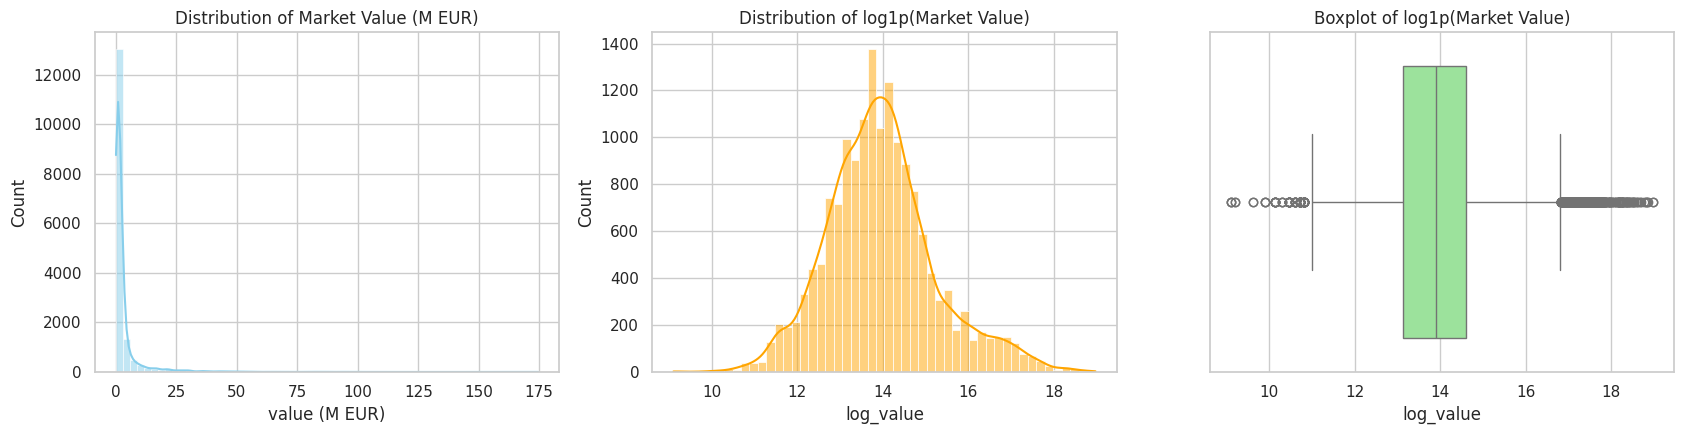

count        16107.0
mean       3189655.0
std        8422789.0
min           9000.0
25%         500000.0
50%        1100000.0
75%        2200000.0
max      174500000.0

میانگین / میانه: 3189655 / 1100000
چولگی قبل و بعد از لگاریتم: 8.16 -> 0.47


In [22]:
# اول ببینیم متغیر هدف چه شکلیه
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(df["value_eur"] / 1e6, bins=60, kde=True, ax=ax[0], color="skyblue")
ax[0].set_title("Distribution of Market Value (M EUR)")
ax[0].set_xlabel("value (M EUR)")
sns.histplot(df["log_value"], bins=50, kde=True, ax=ax[1], color="orange")
ax[1].set_title("Distribution of log1p(Market Value)")
sns.boxplot(x=df["log_value"], ax=ax[2], color="lightgreen")
ax[2].set_title("Boxplot of log1p(Market Value)")
plt.tight_layout()
plt.show()

print(df["value_eur"].describe().round(0).to_string())
print("\nمیانگین / میانه:", round(df["value_eur"].mean()), "/", round(df["value_eur"].median()))
print("چولگی قبل و بعد از لگاریتم:", round(df["value_eur"].skew(), 2), "->", round(df["log_value"].skew(), 2))

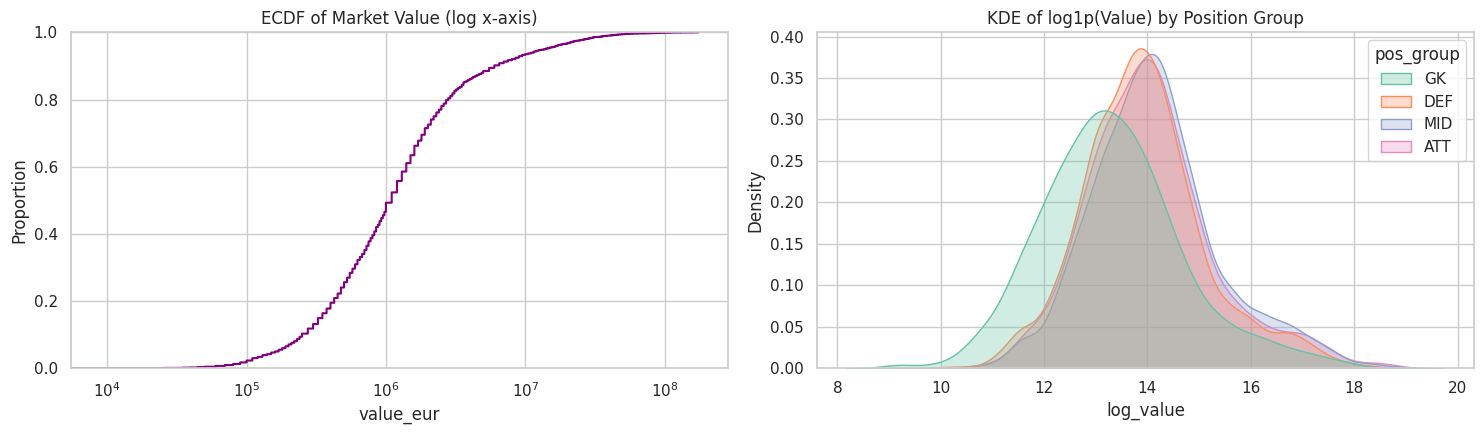

ارزش کمتر از   0.5M€ : 24.0%
ارزش کمتر از   1.0M€ : 46.6%
ارزش کمتر از   5.0M€ : 88.0%
ارزش کمتر از  20.0M€ : 96.6%
ارزش کمتر از  50.0M€ : 99.4%
بازیکن‌های ≥ ۵۰ میلیون یورو: 91


In [23]:
# ECDF برای اینکه ببینیم چه درصدی از بازیکن‌ها زیر هر سطح ارزش هستن + KDE به تفکیک پست
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
sns.ecdfplot(data=df, x="value_eur", ax=ax[0], color="purple")
ax[0].set_xscale("log")
ax[0].set_title("ECDF of Market Value (log x-axis)")
sns.kdeplot(data=df, x="log_value", hue="pos_group", hue_order=pos_order, palette=pos_palette,
            fill=True, common_norm=False, alpha=0.3, ax=ax[1])
ax[1].set_title("KDE of log1p(Value) by Position Group")
plt.tight_layout()
plt.show()

for th in [500_000, 1_000_000, 5_000_000, 20_000_000, 50_000_000]:
    print(f"ارزش کمتر از {th/1e6:>5.1f}M€ : {(df['value_eur'] < th).mean():.1%}")
print("بازیکن‌های ≥ ۵۰ میلیون یورو:", (df["value_eur"] >= 50_000_000).sum())

In [24]:
print("""برداشت اولیه:
- ارزش بازار به‌شدت به راست چوله است: میانه ۱٫۱ میلیون یورو ولی میانگین ۳٫۲ میلیون. حدود ۴۷٪ بازیکن‌ها زیر ۱ میلیون و ۸۸٪ زیر ۵ میلیون یورو ارزش دارن؛ فقط ۹۱ بازیکن ≥ ۵۰ میلیون یورو هستن.
- بعد از لگاریتم توزیع تقریباً زنگوله‌ای می‌شه؛ فقط یه شانه‌ی کوچک در سمت راست می‌مونه که مربوط به ستاره‌هاست.
- KDE به تفکیک پست نشون می‌ده منحنی دروازه‌بان‌ها به‌طور مشخص به چپ (ارزان‌تر) متمایله.
""")

برداشت اولیه:
- ارزش بازار به‌شدت به راست چوله است: میانه ۱٫۱ میلیون یورو ولی میانگین ۳٫۲ میلیون. حدود ۴۷٪ بازیکن‌ها زیر ۱ میلیون و ۸۸٪ زیر ۵ میلیون یورو ارزش دارن؛ فقط ۹۱ بازیکن ≥ ۵۰ میلیون یورو هستن.
- بعد از لگاریتم توزیع تقریباً زنگوله‌ای می‌شه؛ فقط یه شانه‌ی کوچک در سمت راست می‌مونه که مربوط به ستاره‌هاست.
- KDE به تفکیک پست نشون می‌ده منحنی دروازه‌بان‌ها به‌طور مشخص به چپ (ارزان‌تر) متمایله.



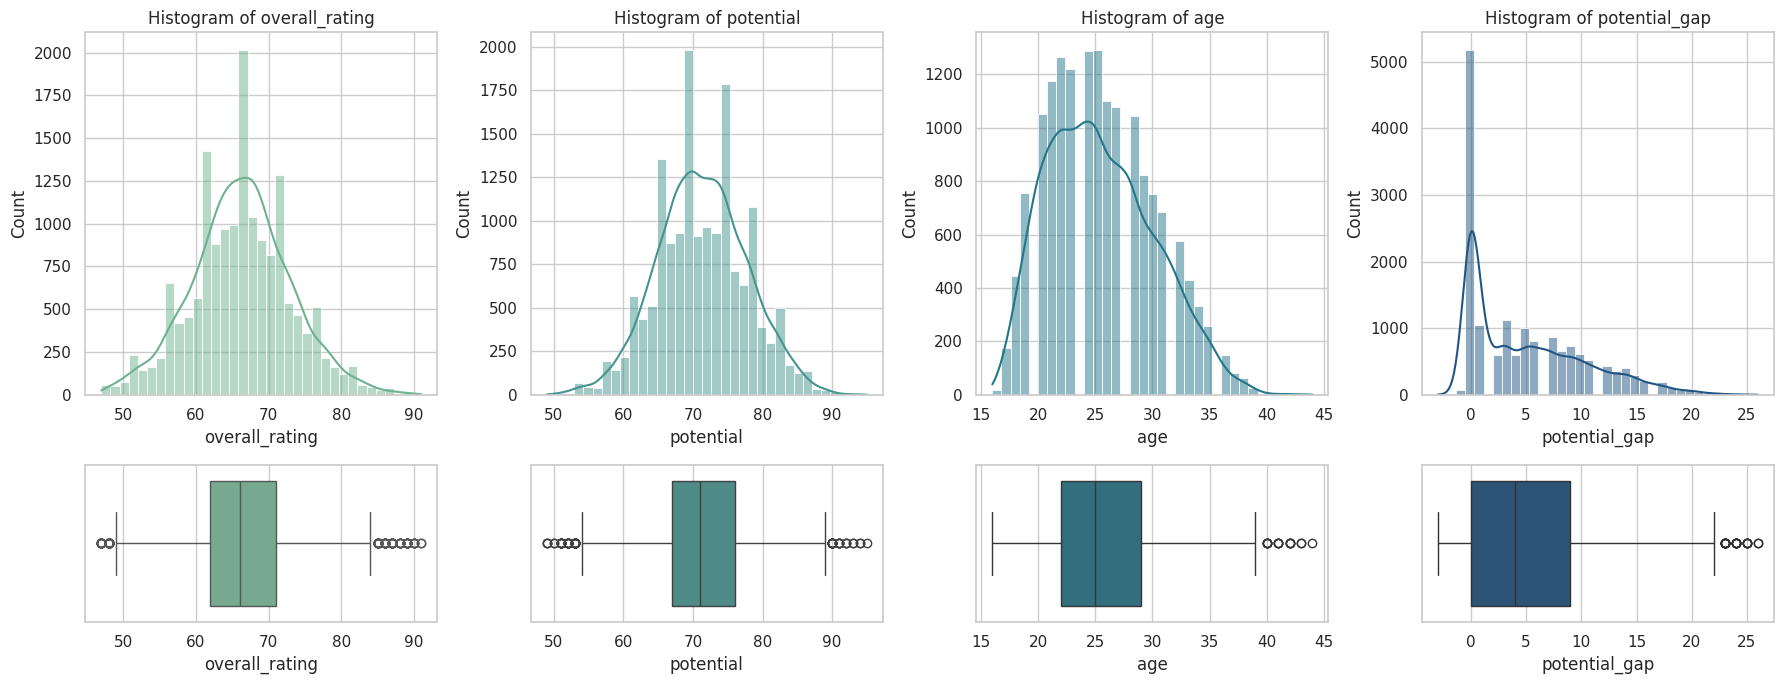

        overall_rating  potential    age  potential_gap
mean             66.26      71.33  25.49           5.07
median           66.00      71.00  25.00           4.00
skew              0.07       0.01   0.41           0.90


In [25]:
# توزیع رتبه، پتانسیل، سن و فاصله‌ی رشد + Boxplot هرکدوم
num_view = ["overall_rating", "potential", "age", "potential_gap"]
fig, ax = plt.subplots(2, 4, figsize=(18, 7), gridspec_kw={"height_ratios": [3, 1.3]})
for i, c in enumerate(num_view):
    sns.histplot(df[c], kde=True, ax=ax[0, i], color=sns.color_palette("crest", 4)[i], bins=35)
    ax[0, i].set_title(f"Histogram of {c}")
    sns.boxplot(x=df[c], ax=ax[1, i], color=sns.color_palette("crest", 4)[i])
plt.tight_layout()
plt.show()
print(df[num_view].agg(["mean", "median", "skew"]).round(2))

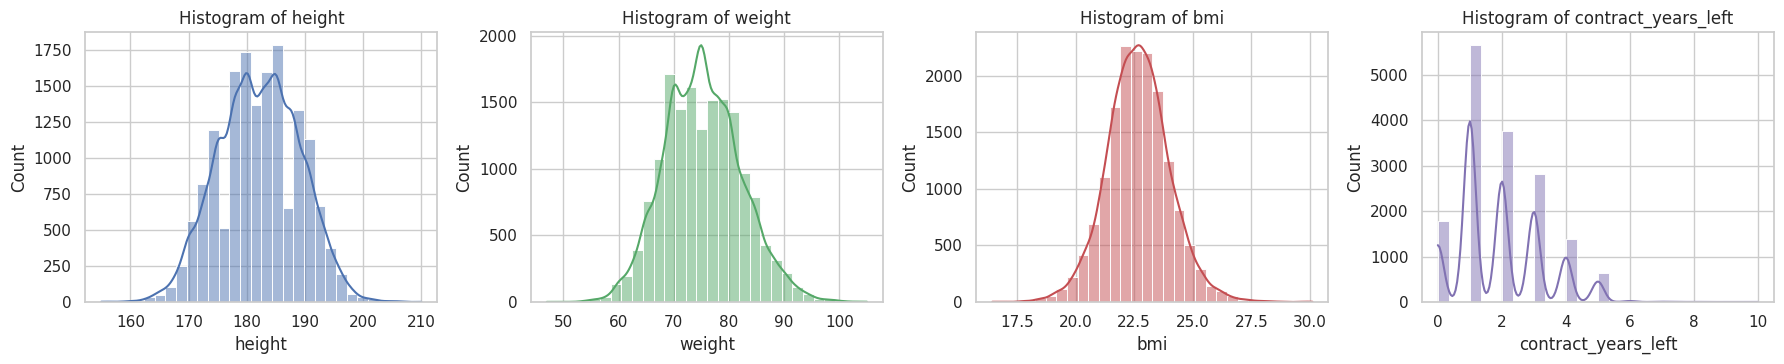

In [26]:
# ویژگی‌های بدنی و قرارداد
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
for a, c, col in zip(ax, ["height", "weight", "bmi", "contract_years_left"], ["#4c72b0", "#55a868", "#c44e52", "#8172b2"]):
    sns.histplot(df[c], kde=True, ax=a, color=col, bins=30)
    a.set_title(f"Histogram of {c}")
plt.tight_layout()
plt.show()

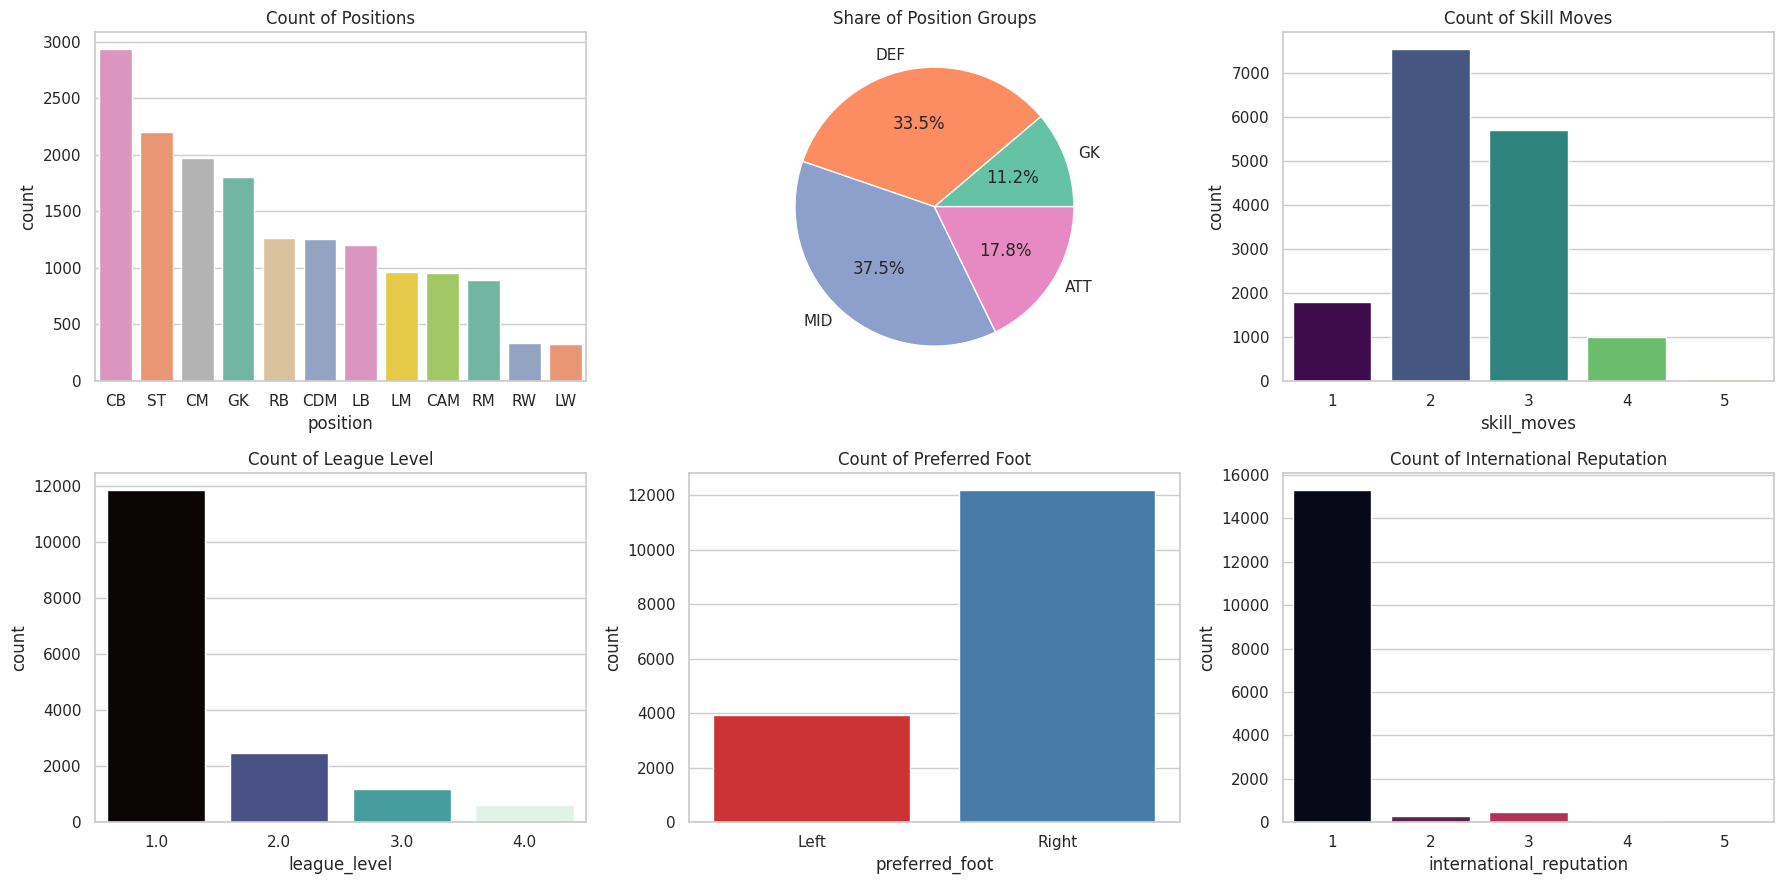

پای چپ: 24.3% | سطح لیگ ۱: 73.7% | شهرت بین‌المللی ۱: 95.1%


In [27]:
# متغیرهای دسته‌ای: پست، گروه پست، حرکات مهارتی، سطح لیگ، پای برتر، ۵ لیگ بزرگ
fig, ax = plt.subplots(2, 3, figsize=(18, 9))
order_pos = df["position"].value_counts().index
sns.countplot(data=df, x="position", order=order_pos, hue="position", palette="Set2", legend=False, ax=ax[0, 0])
ax[0, 0].set_title("Count of Positions")
df["pos_group"].value_counts().reindex(pos_order).plot.pie(autopct="%1.1f%%", colors=[pos_palette[p] for p in pos_order], ax=ax[0, 1])
ax[0, 1].set_title("Share of Position Groups"); ax[0, 1].set_ylabel("")
sns.countplot(data=df, x="skill_moves", hue="skill_moves", palette="viridis", legend=False, ax=ax[0, 2])
ax[0, 2].set_title("Count of Skill Moves")
sns.countplot(data=df, x="league_level", hue="league_level", palette="mako", legend=False, ax=ax[1, 0])
ax[1, 0].set_title("Count of League Level")
sns.countplot(data=df, x="preferred_foot", hue="preferred_foot", palette="Set1", legend=False, ax=ax[1, 1])
ax[1, 1].set_title("Count of Preferred Foot")
sns.countplot(data=df, x="international_reputation", hue="international_reputation", palette="rocket", legend=False, ax=ax[1, 2])
ax[1, 2].set_title("Count of International Reputation")
plt.tight_layout()
plt.show()

print("پای چپ:", f"{(df['preferred_foot'] == 'Left').mean():.1%}", "| سطح لیگ ۱:", f"{(df['league_level'] == 1).mean():.1%}",
      "| شهرت بین‌المللی ۱:", f"{(df['international_reputation'] == 1).mean():.1%}")

In [28]:
print("""برداشت اولیه:
- CB با ۲٬۹۳۷ بازیکن پرتعدادترین پسته. سهم گروه‌ها: هافبک ≈ ۳۷٫۵٪، مدافع ≈ ۳۳٫۵٪، مهاجم ≈ ۱۷٫۸٪ و دروازه‌بان ≈ ۱۱٫۲٪.
- پای چپ فقط ۲۴٪ بازیکن‌هاست. ۷۴٪ بازیکن‌ها در لیگ سطح ۱ هستن و ۹۵٪ شهرت بین‌المللی ۱ دارن، پس ستاره‌ها (شهرت ۳ به بالا) گروه بسیار کوچکی‌ان.
- رتبه‌ی کلی و پتانسیل تقریباً متقارن‌اند (چولگی نزدیک صفر)؛ سن و فاصله‌ی رشد (potential_gap) کمی به راست چوله‌ان.
""")

برداشت اولیه:
- CB با ۲٬۹۳۷ بازیکن پرتعدادترین پسته. سهم گروه‌ها: هافبک ≈ ۳۷٫۵٪، مدافع ≈ ۳۳٫۵٪، مهاجم ≈ ۱۷٫۸٪ و دروازه‌بان ≈ ۱۱٫۲٪.
- پای چپ فقط ۲۴٪ بازیکن‌هاست. ۷۴٪ بازیکن‌ها در لیگ سطح ۱ هستن و ۹۵٪ شهرت بین‌المللی ۱ دارن، پس ستاره‌ها (شهرت ۳ به بالا) گروه بسیار کوچکی‌ان.
- رتبه‌ی کلی و پتانسیل تقریباً متقارن‌اند (چولگی نزدیک صفر)؛ سن و فاصله‌ی رشد (potential_gap) کمی به راست چوله‌ان.



### 9.2 تحلیل دومتغیره

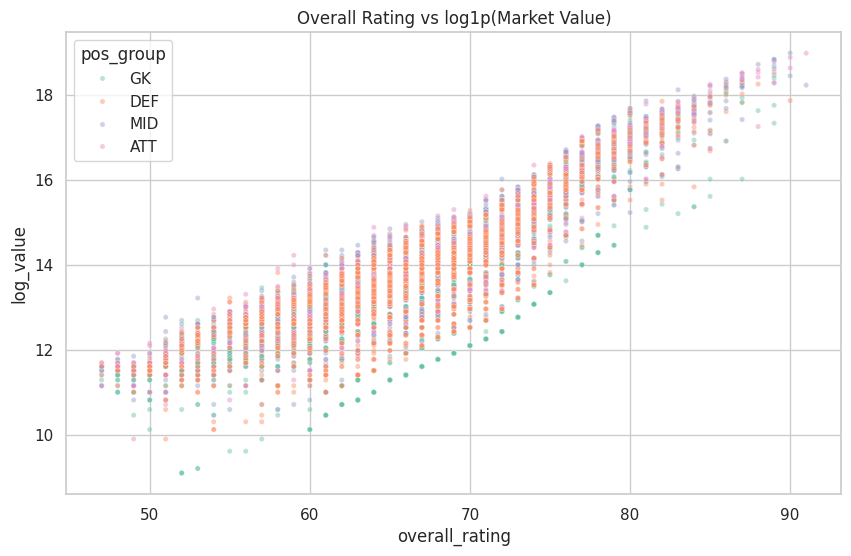

همبستگی پیرسون overall_rating با log_value: 0.883


In [29]:
# اولین سوال: رتبه‌ی کلی چقدر ارزش رو توضیح می‌ده؟
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="overall_rating", y="log_value", hue="pos_group", hue_order=pos_order,
                palette=pos_palette, alpha=0.45, s=14)
plt.title("Overall Rating vs log1p(Market Value)")
plt.show()
print("همبستگی پیرسون overall_rating با log_value:", round(df[["overall_rating", "log_value"]].corr().iloc[0, 1], 3))

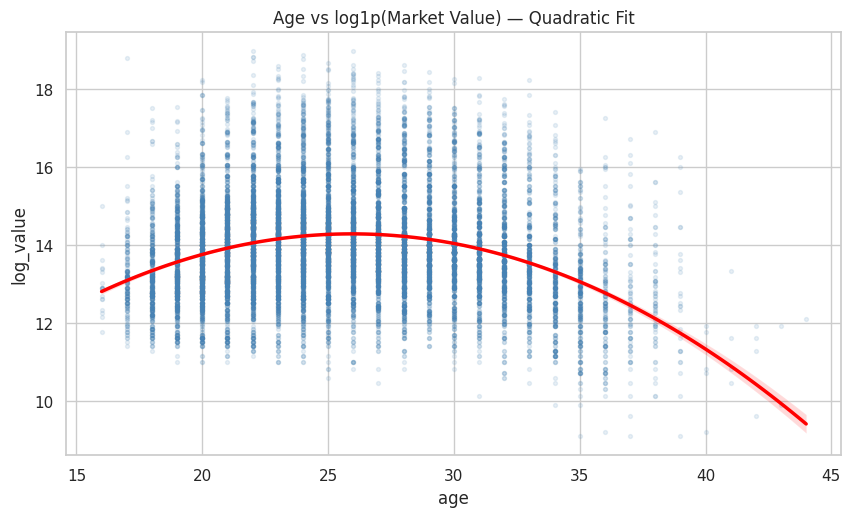

In [30]:
# رابطه‌ی سن با ارزش خطی نیست؛ برای همین یه Reg Plot درجه‌ی ۲ می‌کشیم
plt.figure(figsize=(10, 5.5))
sns.regplot(data=df, x="age", y="log_value", order=2, scatter_kws={"alpha": 0.12, "s": 8, "color": "steelblue"},
            line_kws={"color": "red", "lw": 2.5})
plt.title("Age vs log1p(Market Value) — Quadratic Fit")
plt.show()

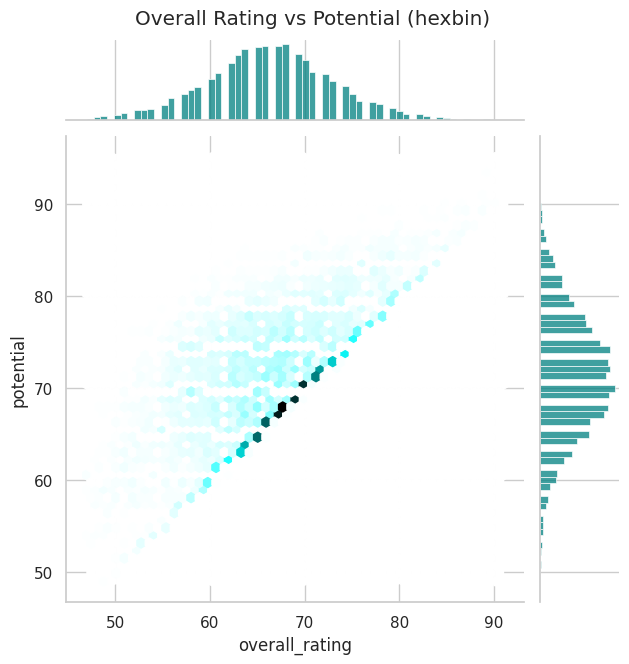

همبستگی overall و potential: 0.678


In [31]:
# رتبه و پتانسیل با هم: Joint Plot از نوع hexbin چون داده حجیمه
g = sns.jointplot(data=df, x="overall_rating", y="potential", kind="hex", height=6.5, color="teal")
g.figure.suptitle("Overall Rating vs Potential (hexbin)", y=1.02)
plt.show()
print("همبستگی overall و potential:", round(df[["overall_rating", "potential"]].corr().iloc[0, 1], 3))

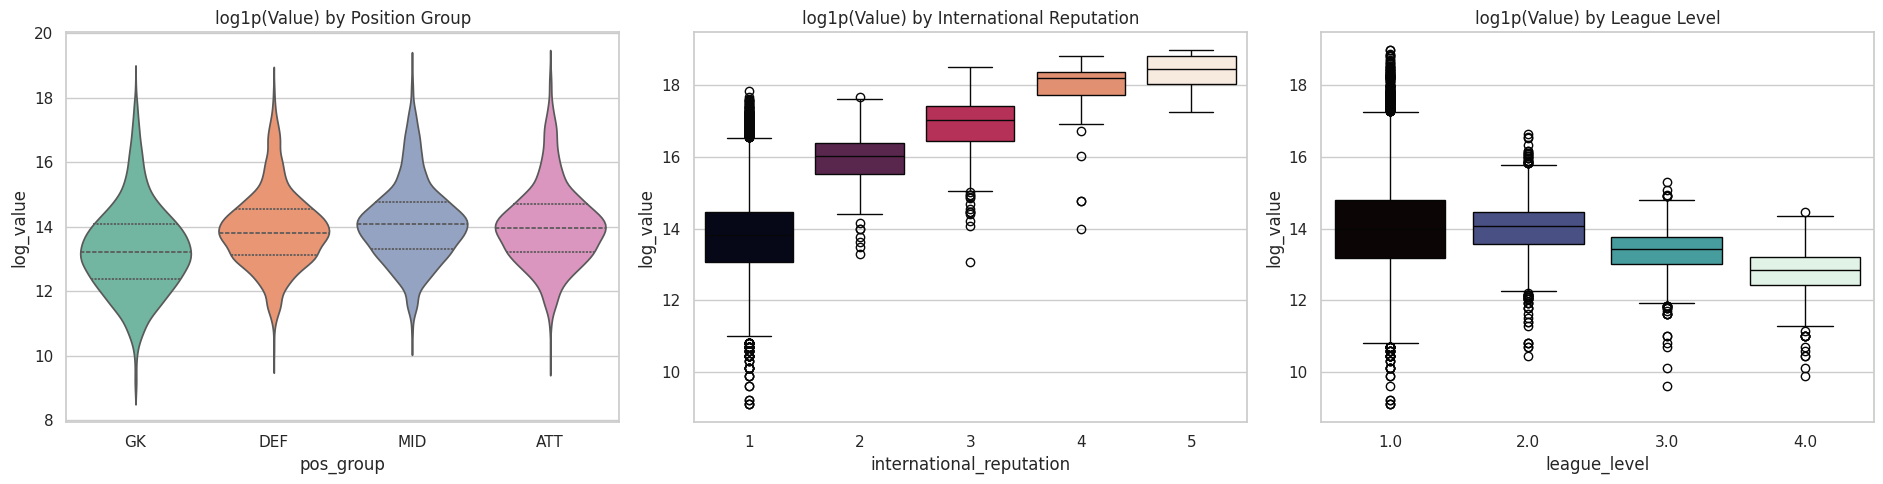

pos_group
GK      550000.0
DEF    1000000.0
MID    1300000.0
ATT    1150000.0
international_reputation
1      1000000.0
2      9000000.0
3     25000000.0
4     79500000.0
5    102000000.0


In [32]:
# ارزش به تفکیک پست، شهرت بین‌المللی و سطح لیگ
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
sns.violinplot(data=df, x="pos_group", y="log_value", order=pos_order, hue="pos_group", palette=pos_palette, legend=False, ax=ax[0], inner="quartile")
ax[0].set_title("log1p(Value) by Position Group")
sns.boxplot(data=df, x="international_reputation", y="log_value", hue="international_reputation", palette="rocket", legend=False, ax=ax[1])
ax[1].set_title("log1p(Value) by International Reputation")
sns.boxplot(data=df, x="league_level", y="log_value", hue="league_level", palette="mako", legend=False, ax=ax[2])
ax[2].set_title("log1p(Value) by League Level")
plt.tight_layout()
plt.show()
print(df.groupby("pos_group")["value_eur"].median().reindex(pos_order).round(0).to_string())
print(df.groupby("international_reputation")["value_eur"].median().round(0).to_string())

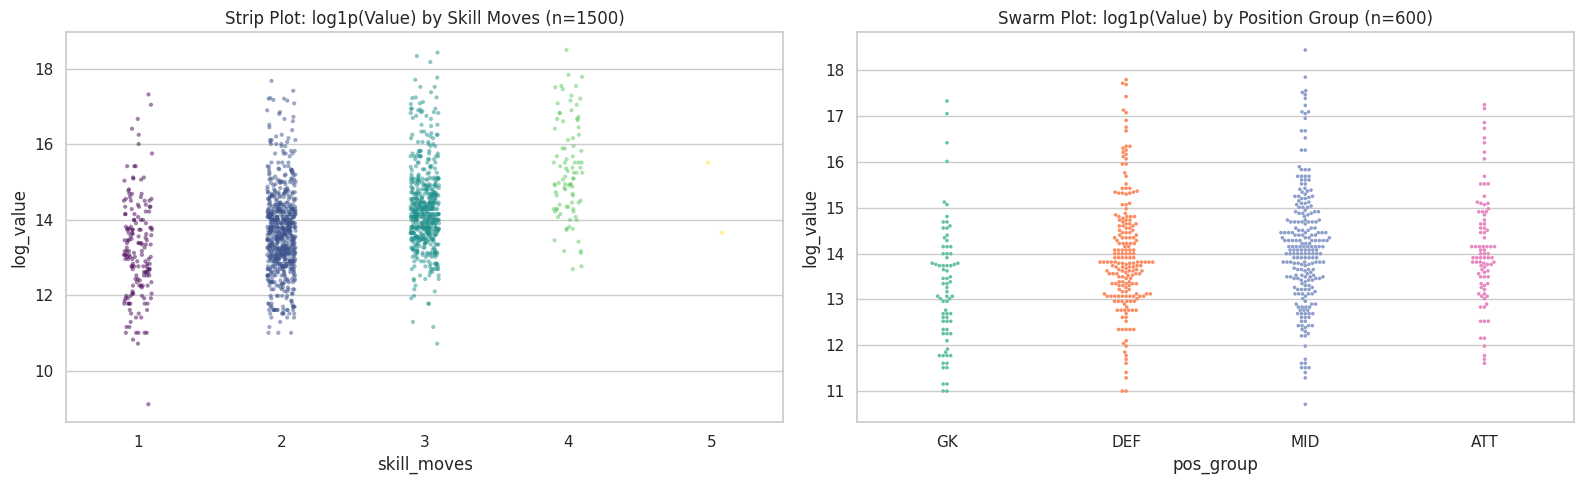

In [33]:
# نقطه‌های خام روی هر دسته: Strip Plot (نمونه‌ی ۱۵۰۰ تایی) و Swarm Plot (نمونه‌ی ۶۰۰ تایی)
sample_1500 = df.sample(1500, random_state=RANDOM_STATE)
sample_600 = df.sample(600, random_state=RANDOM_STATE)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.stripplot(data=sample_1500, x="skill_moves", y="log_value", jitter=True, alpha=0.5, size=3, ax=ax[0], hue="skill_moves", palette="viridis", legend=False)
ax[0].set_title("Strip Plot: log1p(Value) by Skill Moves (n=1500)")
sns.swarmplot(data=sample_600, x="pos_group", y="log_value", order=pos_order, size=2.6, ax=ax[1], hue="pos_group", palette=pos_palette, legend=False)
ax[1].set_title("Swarm Plot: log1p(Value) by Position Group (n=600)")
plt.tight_layout()
plt.show()

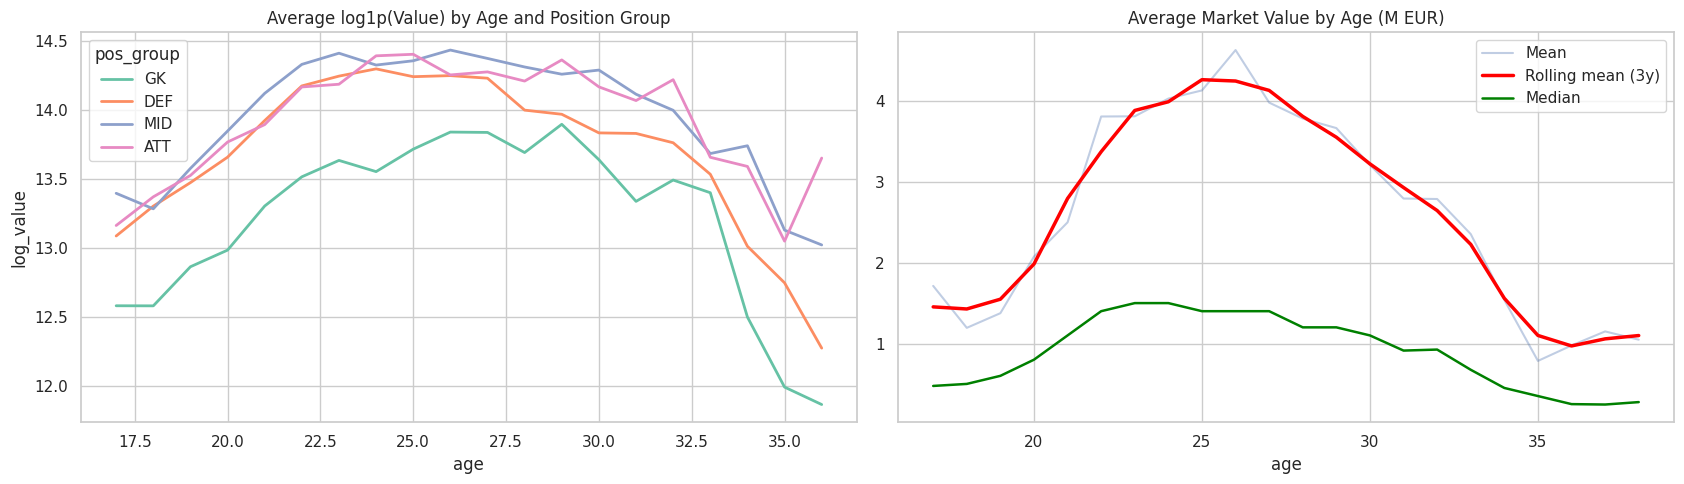

سنی که میانگین ارزش در اون بیشینه است: 26
سنی که میانه‌ی ارزش در اون بیشینه است : 23


In [34]:
# منحنی سن ← ارزش (به جای تحلیل سری زمانی): میانگین لگاریتم ارزش در هر سن به تفکیک پست
age_view = df[df["age"].between(17, 36)]
fig, ax = plt.subplots(1, 2, figsize=(17, 5))
sns.lineplot(data=age_view, x="age", y="log_value", hue="pos_group", hue_order=pos_order, palette=pos_palette, errorbar=None, ax=ax[0], lw=2)
ax[0].set_title("Average log1p(Value) by Age and Position Group")

# میانگین متحرک ۳ ساله روی میانگین ارزش برای دیدن روند نرم‌تر
age_curve = df.groupby("age")["value_eur"].agg(["mean", "median", "count"]).reset_index()
age_curve = age_curve[age_curve["count"] >= 30].copy()
age_curve["rolling_mean"] = age_curve["mean"].rolling(3, center=True, min_periods=1).mean()
ax[1].plot(age_curve["age"], age_curve["mean"] / 1e6, alpha=0.35, label="Mean")
ax[1].plot(age_curve["age"], age_curve["rolling_mean"] / 1e6, color="red", lw=2.5, label="Rolling mean (3y)")
ax[1].plot(age_curve["age"], age_curve["median"] / 1e6, color="green", lw=1.8, label="Median")
ax[1].set_title("Average Market Value by Age (M EUR)")
ax[1].set_xlabel("age"); ax[1].legend()
plt.tight_layout()
plt.show()

print("سنی که میانگین ارزش در اون بیشینه است:", int(age_curve.loc[age_curve["mean"].idxmax(), "age"]))
print("سنی که میانه‌ی ارزش در اون بیشینه است :", int(age_curve.loc[age_curve["median"].idxmax(), "age"]))

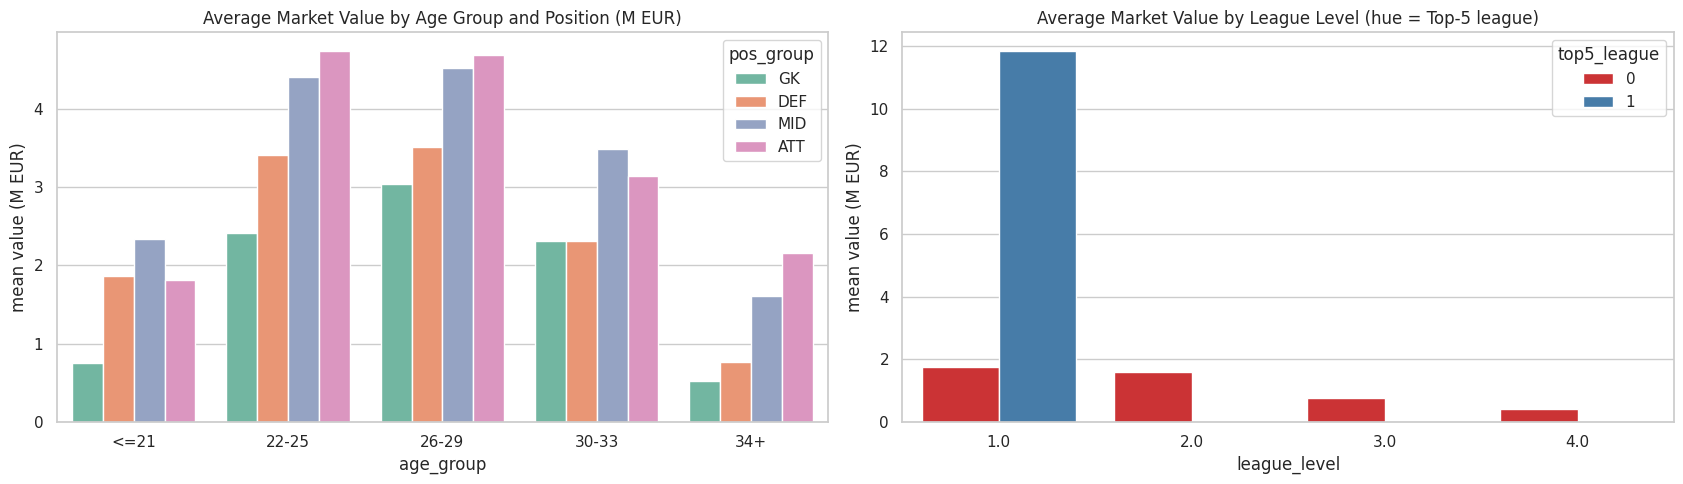

                   mean     median  count
top5_league                              
0             1573730.0   900000.0  13573
1            11845122.0  5500000.0   2534


In [35]:
# مقایسه‌ی گروهی: میانگین ارزش هر گروه سنی به تفکیک پست + اثر ۵ لیگ بزرگ و سطح لیگ
fig, ax = plt.subplots(1, 2, figsize=(17, 5))
sns.barplot(data=df, x="age_group", y=df["value_eur"] / 1e6, hue="pos_group", hue_order=pos_order, palette=pos_palette, errorbar=None, ax=ax[0])
ax[0].set_title("Average Market Value by Age Group and Position (M EUR)")
ax[0].set_ylabel("mean value (M EUR)")
sns.barplot(data=df, x="league_level", y=df["value_eur"] / 1e6, hue="top5_league", palette="Set1", errorbar=None, ax=ax[1])
ax[1].set_title("Average Market Value by League Level (hue = Top-5 league)")
ax[1].set_ylabel("mean value (M EUR)")
plt.tight_layout()
plt.show()
print(df.groupby("top5_league")["value_eur"].agg(["mean", "median", "count"]).round(0))

In [36]:
print("""برداشت اولیه:
- رتبه‌ی کلی همبستگی ۰٫۸۸ با لگاریتم ارزش دارد (رابطه‌ی نزدیک به خطی در مقیاس لگاریتمی)؛ رتبه و پتانسیل هم ۰٫۶۸ با هم همبسته‌اند.
- منحنی سن ← ارزش کوهانی است: میانگین ارزش نزدیک ۲۶ سالگی اوج می‌گیره ولی میانه‌ی ارزش زودتر (حدود ۲۳ سالگی) به اوج می‌رسه؛ یعنی جوان‌ها بیشتر ارزش می‌گیرن و بعد از ۳۰ سالگی افت تندتر می‌شه. به همین دلیل همبستگی خطی سن با ارزش تقریباً صفره (−۰٫۰۶) ولی رابطه واقعی و غیرخطیه.
- در همه‌ی سنین دروازه‌بان‌ها ارزان‌تر از بقیه هستن (میانه ۰٫۵۵ میلیون در برابر ۱ تا ۱٫۳ میلیون).
- شهرت بین‌المللی اثر پله‌ای شدیدی داره: میانه‌ی ارزش از ۱ میلیون (سطح ۱) به ۹ میلیون (۲)، ۲۵ میلیون (۳) و بیش از ۷۹ میلیون (۴) می‌رسه.
- بازیکن‌های ۵ لیگ بزرگ میانگین ۱۱٫۸ میلیون و میانه‌ی ۵٫۵ میلیون دارن؛ بقیه ۱٫۶ و ۰٫۹ میلیون.
""")

برداشت اولیه:
- رتبه‌ی کلی همبستگی ۰٫۸۸ با لگاریتم ارزش دارد (رابطه‌ی نزدیک به خطی در مقیاس لگاریتمی)؛ رتبه و پتانسیل هم ۰٫۶۸ با هم همبسته‌اند.
- منحنی سن ← ارزش کوهانی است: میانگین ارزش نزدیک ۲۶ سالگی اوج می‌گیره ولی میانه‌ی ارزش زودتر (حدود ۲۳ سالگی) به اوج می‌رسه؛ یعنی جوان‌ها بیشتر ارزش می‌گیرن و بعد از ۳۰ سالگی افت تندتر می‌شه. به همین دلیل همبستگی خطی سن با ارزش تقریباً صفره (−۰٫۰۶) ولی رابطه واقعی و غیرخطیه.
- در همه‌ی سنین دروازه‌بان‌ها ارزان‌تر از بقیه هستن (میانه ۰٫۵۵ میلیون در برابر ۱ تا ۱٫۳ میلیون).
- شهرت بین‌المللی اثر پله‌ای شدیدی داره: میانه‌ی ارزش از ۱ میلیون (سطح ۱) به ۹ میلیون (۲)، ۲۵ میلیون (۳) و بیش از ۷۹ میلیون (۴) می‌رسه.
- بازیکن‌های ۵ لیگ بزرگ میانگین ۱۱٫۸ میلیون و میانه‌ی ۵٫۵ میلیون دارن؛ بقیه ۱٫۶ و ۰٫۹ میلیون.



### 9.3 تحلیل چندمتغیره

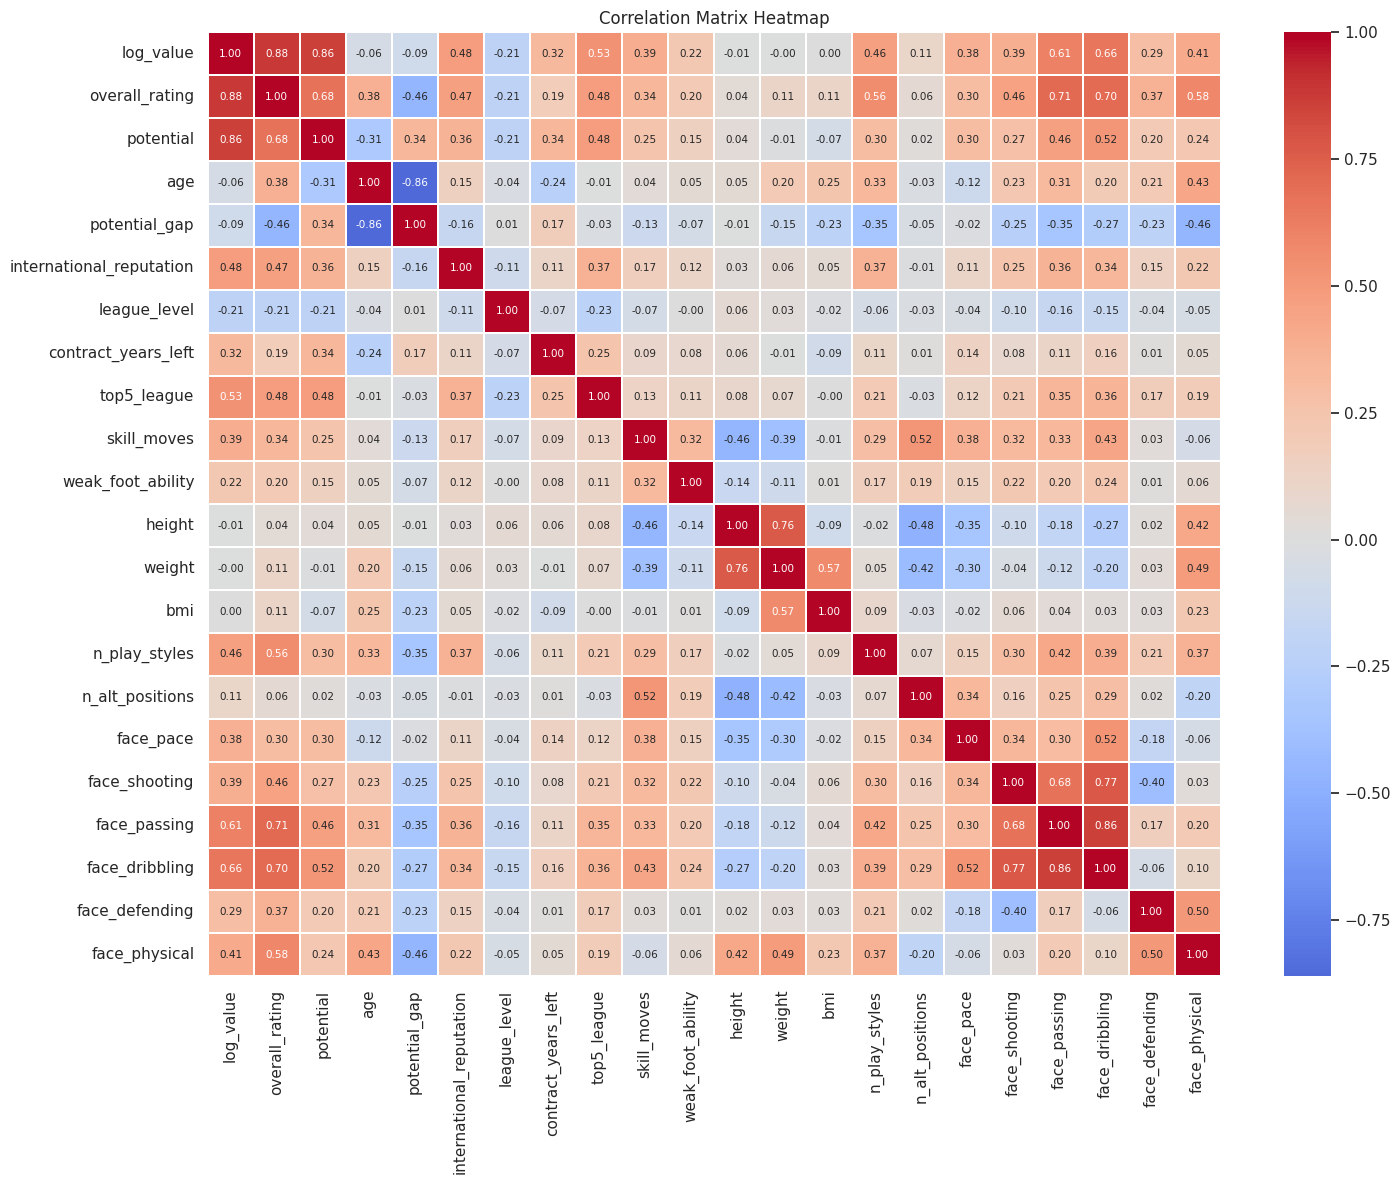

In [37]:
# نقشه‌ی همبستگی متغیرهای اصلی
heat_cols = ["log_value", "overall_rating", "potential", "age", "potential_gap", "international_reputation", "league_level",
             "contract_years_left", "top5_league", "skill_moves", "weak_foot_ability", "height", "weight", "bmi",
             "n_play_styles", "n_alt_positions"] + face_stats
plt.figure(figsize=(15, 12))
sns.heatmap(df[heat_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7.5}, linewidths=0.3)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

قوی‌ترین همبستگی‌های مثبت:
overall_rating    0.883
potential         0.857
reactions         0.780
face_dribbling    0.657
composure         0.626
face_passing      0.613
short_passing     0.571
vision            0.538

قوی‌ترین همبستگی‌های منفی:
league_level   -0.210
is_gk          -0.181
gk_kicking     -0.141
gk_handling    -0.141


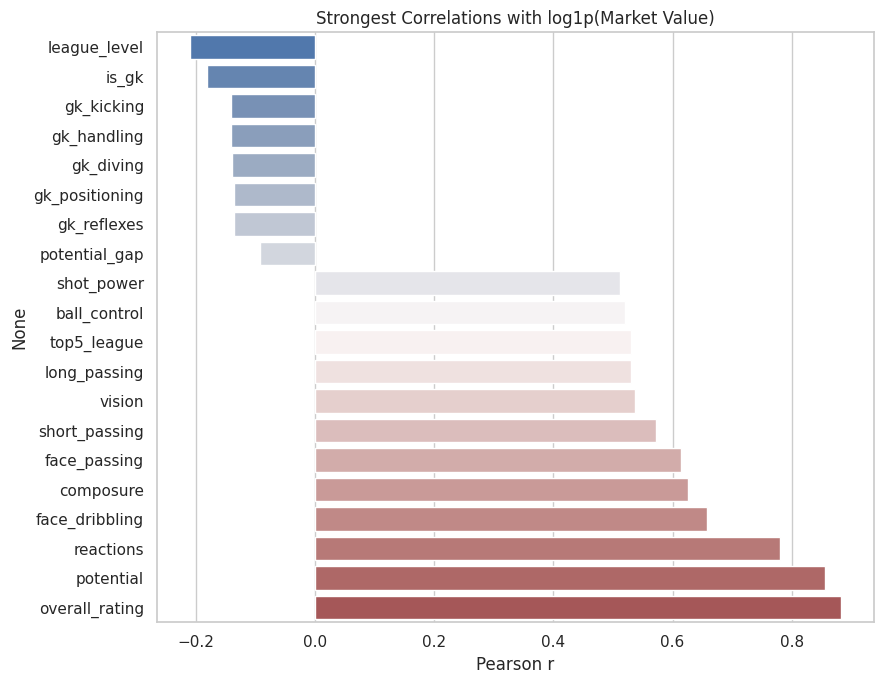

In [38]:
# کدوم ویژگی‌ها بیشترین همبستگی با هدف رو دارن؟ (همه‌ی ستون‌های عددی کاندید)
cand_for_corr = ["overall_rating", "potential", "age", "potential_gap", "height", "weight", "bmi", "skill_moves", "weak_foot_ability",
                 "international_reputation", "league_level", "contract_years_left", "n_play_styles", "n_play_styles_plus",
                 "n_alt_positions", "top5_league", "is_gk"] + face_stats + detail_attrs + gk_attrs
corr_target = df[cand_for_corr].corrwith(df["log_value"]).sort_values()
top_corr = pd.concat([corr_target.head(8), corr_target.tail(12)])
print("قوی‌ترین همبستگی‌های مثبت:")
print(corr_target.sort_values(ascending=False).head(8).round(3).to_string())
print("\nقوی‌ترین همبستگی‌های منفی:")
print(corr_target.head(4).round(3).to_string())
plt.figure(figsize=(9, 7))
sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index, palette="vlag", legend=False)
plt.title("Strongest Correlations with log1p(Market Value)")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

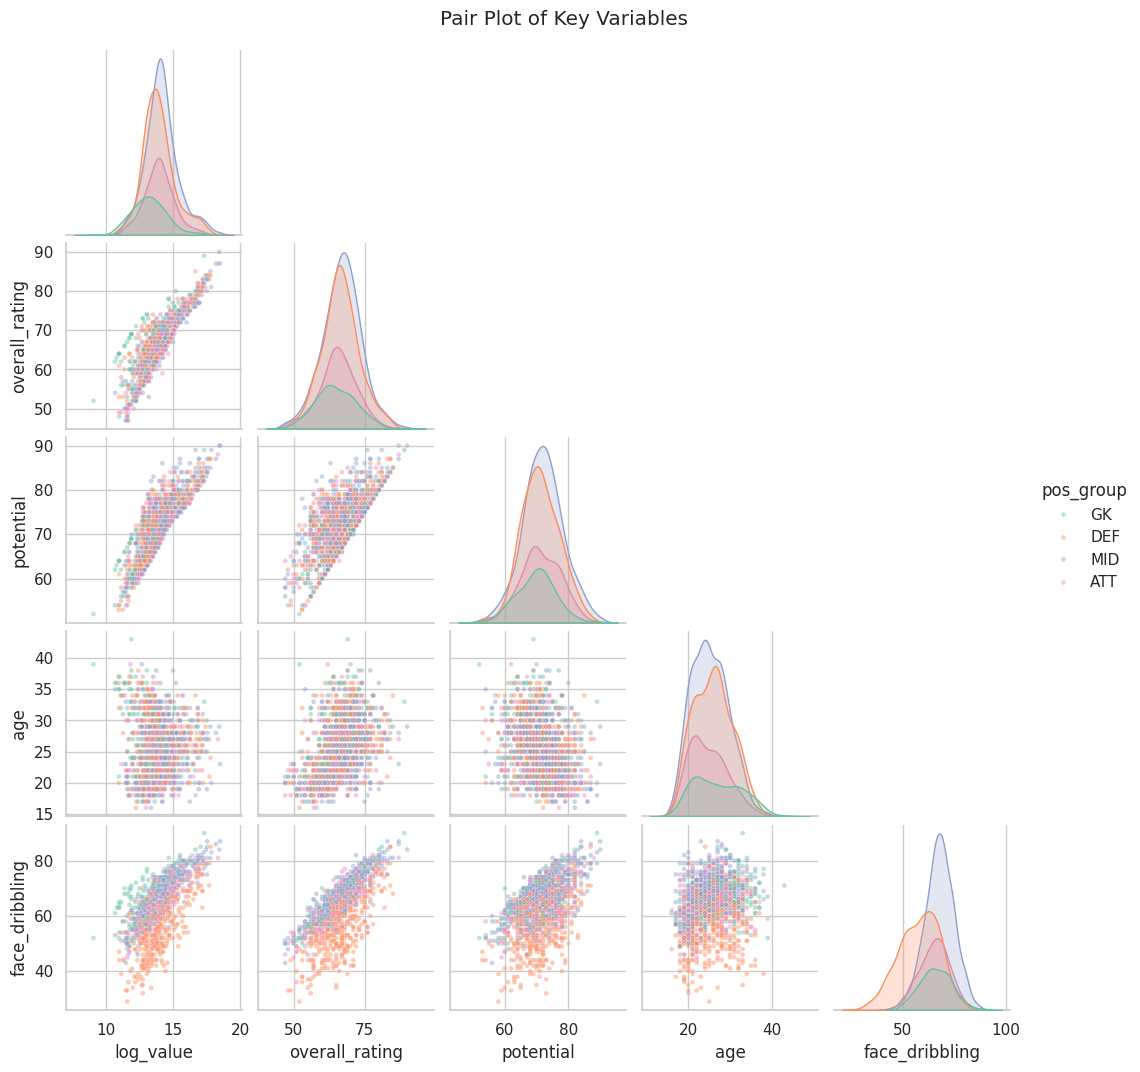

In [39]:
# Pair Plot روی متغیرهای اصلی (نمونه‌ی ۱۵۰۰ تایی تا سنگین نشه)
sns.pairplot(df.sample(1500, random_state=RANDOM_STATE), vars=["log_value", "overall_rating", "potential", "age", "face_dribbling"],
             hue="pos_group", hue_order=pos_order, palette=pos_palette, corner=True, plot_kws={"alpha": 0.45, "s": 12}, height=2.1)
plt.suptitle("Pair Plot of Key Variables", y=1.02)
plt.show()

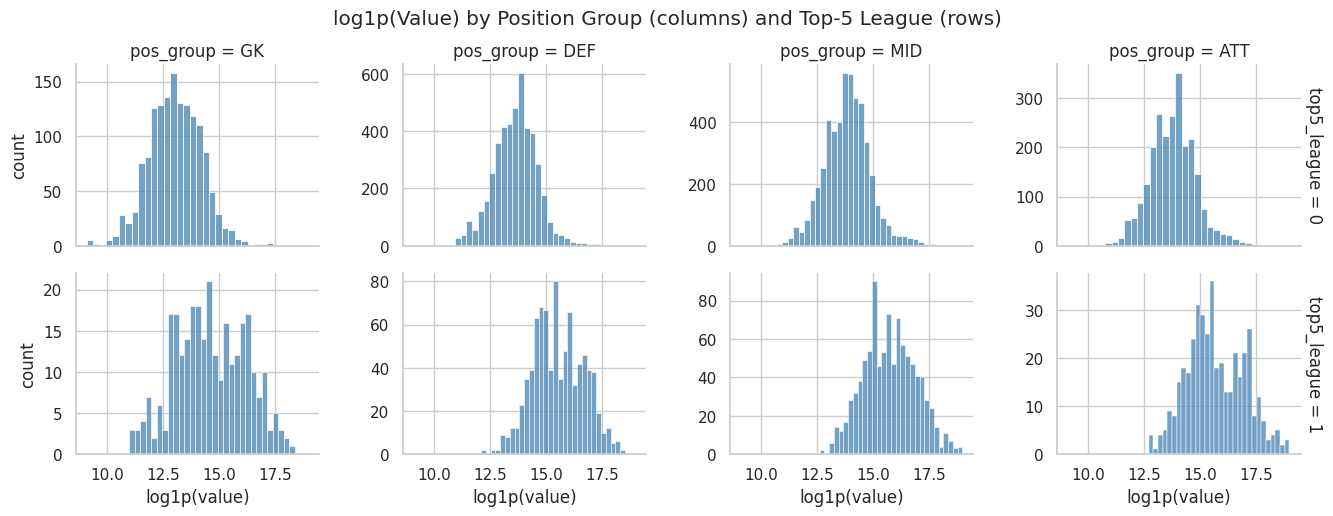

In [40]:
# Facet Grid: توزیع ارزش به تفکیک پست (ستون‌ها) و ۵ لیگ بزرگ (ردیف‌ها)
g = sns.FacetGrid(df, row="top5_league", col="pos_group", col_order=pos_order, height=2.5, aspect=1.35, margin_titles=True, sharey=False)
g.map_dataframe(sns.histplot, x="log_value", bins=30, color="steelblue")
g.set_axis_labels("log1p(value)", "count")
g.figure.suptitle("log1p(Value) by Position Group (columns) and Top-5 League (rows)", y=1.03)
plt.show()

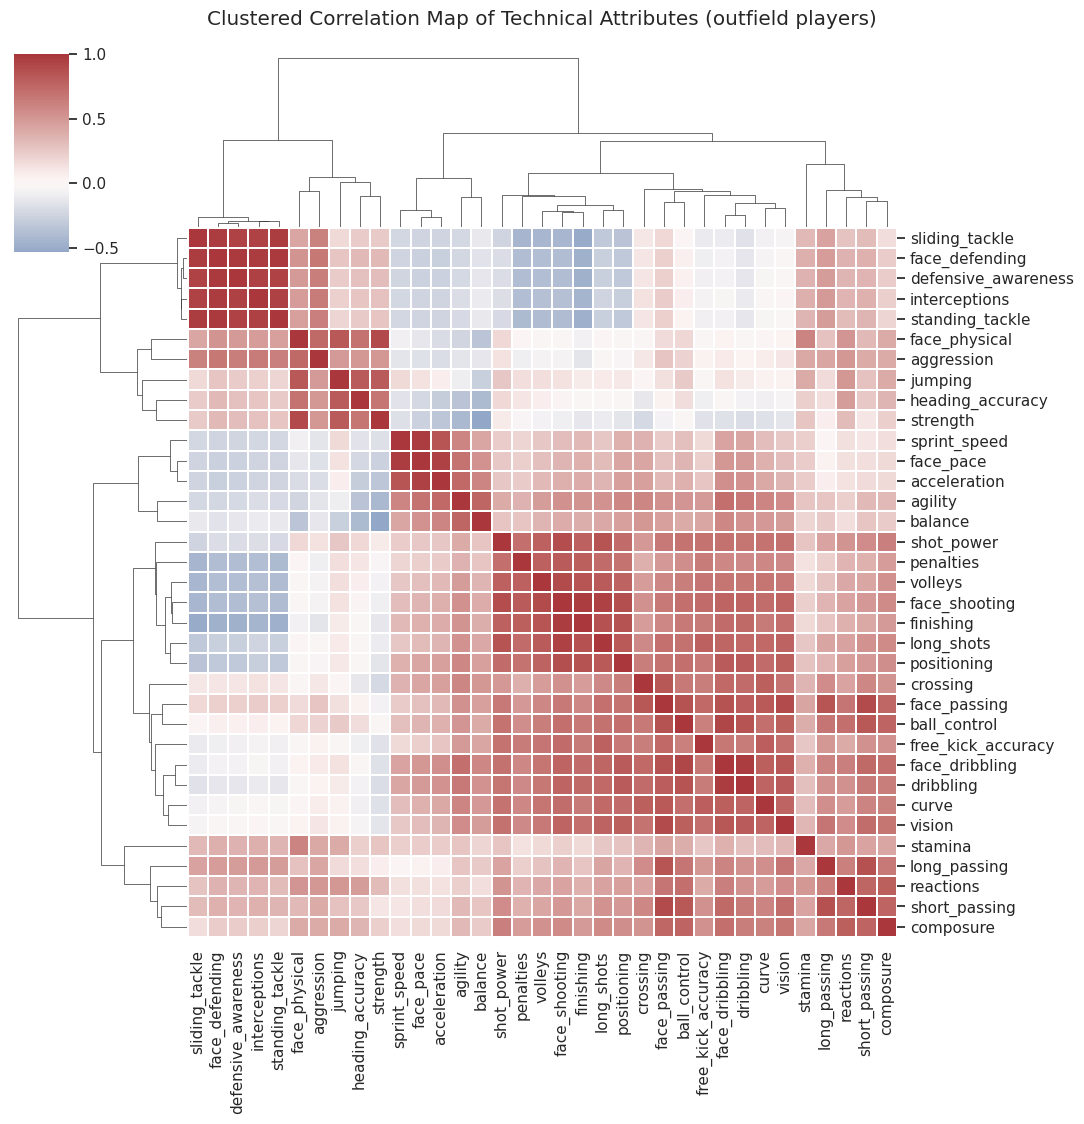

In [41]:
# Cluster Map: ویژگی‌های فنی بازیکنان میدانی رو بر اساس همبستگی گروه‌بندی می‌کنیم
# (دروازه‌بان‌ها رو کنار می‌ذاریم چون شش آمار اصلی‌شون در واقع آمار GK هست)
outfield = df[df["is_gk"] == 0]
cg = sns.clustermap(outfield[face_stats + detail_attrs].corr(), cmap="vlag", center=0, figsize=(11, 11),
                    xticklabels=True, yticklabels=True, linewidths=0.2)
cg.figure.suptitle("Clustered Correlation Map of Technical Attributes (outfield players)", y=1.02)
plt.show()

In [42]:
print("""برداشت اولیه:
- بعد از رتبه و پتانسیل، قوی‌ترین همبستگی‌ها با ارزش مربوط به آمار dribbling و passing (حدود ۰٫۶۵ و ۰٫۶۱)، لیگ‌های بزرگ (۰٫۵۳)، شهرت بین‌المللی (۰٫۴۸) و تعداد PlayStyle (۰٫۴۶) است. قد و وزن تقریباً هیچ رابطه‌ای ندارن.
- `potential_gap` با سن همبستگی ۰٫۸۶− داره؛ یعنی «ظرفیت رشد» عملاً شکل دیگه‌ای از جوان بودنه.
- Clustermap ویژگی‌های فنی رو در بلوک‌های منطقی قرار می‌ده: حمله (shooting, dribbling, passing)، دفاع (تکل، intercept، awareness) و بدنی (strength, jumping, stamina).
- Facet Grid نشون می‌ده شکل توزیع ارزش در همه‌ی پست‌ها مشابهه و ۵ لیگ بزرگ کل توزیع رو به سمت ارزش‌های بالاتر جابه‌جا می‌کنه.
""")

برداشت اولیه:
- بعد از رتبه و پتانسیل، قوی‌ترین همبستگی‌ها با ارزش مربوط به آمار dribbling و passing (حدود ۰٫۶۵ و ۰٫۶۱)، لیگ‌های بزرگ (۰٫۵۳)، شهرت بین‌المللی (۰٫۴۸) و تعداد PlayStyle (۰٫۴۶) است. قد و وزن تقریباً هیچ رابطه‌ای ندارن.
- `potential_gap` با سن همبستگی ۰٫۸۶− داره؛ یعنی «ظرفیت رشد» عملاً شکل دیگه‌ای از جوان بودنه.
- Clustermap ویژگی‌های فنی رو در بلوک‌های منطقی قرار می‌ده: حمله (shooting, dribbling, passing)، دفاع (تکل، intercept، awareness) و بدنی (strength, jumping, stamina).
- Facet Grid نشون می‌ده شکل توزیع ارزش در همه‌ی پست‌ها مشابهه و ۵ لیگ بزرگ کل توزیع رو به سمت ارزش‌های بالاتر جابه‌جا می‌کنه.



### 9.4 داده‌های پرت (Outliers)

In [43]:
# اول روش IQR روی چند متغیر کلیدی
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

rows = []
for c in ["value_eur", "log_value", "overall_rating", "potential", "age", "bmi", "height", "weight"]:
    n = iqr_outliers(df[c])
    rows.append({"column": c, "outliers": n, "percent": round(100 * n / len(df), 2)})
display(pd.DataFrame(rows).set_index("column"))

# ده بازیکن گران‌قیمت
display(df.nlargest(10, "value_eur")[["player_name", "team", "position", "age", "overall_rating", "potential", "value_eur"]])

,outliers,percent
column,,
value_eur,2000,12.42
log_value,599,3.72
overall_rating,153,0.95
potential,82,0.51
age,16,0.10
bmi,281,1.74
height,26,0.16
weight,61,0.38


,player_name,team,position,age,overall_rating,potential,value_eur
5,Jude Bellingham,Real Madrid,CAM,22,90,94,174500000
1,Kylian Mbappé,Real Madrid,ST,26,91,94,173500000
6,Erling Haaland,Manchester City,ST,24,90,92,157000000
18,Florian Wirtz,Liverpool,CAM,22,89,93,150500000
12,Pedri,FC Barcelona,CM,22,89,93,149500000
9,Lamine Yamal,FC Barcelona,RM,17,89,95,147000000
17,Vini Jr.,Real Madrid,LW,24,89,92,141000000
23,Jamal Musiala,FC Bayern München,CAM,22,88,92,133500000
10,Vitinha,Paris SG,CM,25,89,91,128500000
2,Ousmane Dembélé,Paris SG,ST,28,90,90,122500000


تعداد بازیکن‌های مشکوک: 323
pos_group
GK     0.042
DEF    0.014
MID    0.019
ATT    0.022


,player_name,position,age,overall_rating,potential,bmi,value_eur
15558,Richard Brush,GK,40,53,53,25.127831,10000
9,Lamine Yamal,RM,17,89,95,22.222222,147000000
4,Virgil van Dijk,CB,33,90,90,24.698650,57000000
15717,Karanjit Singh,GK,39,52,52,23.198315,9000
12,Pedri,CM,22,89,93,19.817677,149500000
46,Viktor Gyökeres,ST,27,87,88,26.315053,93000000
16046,Yang He,ST,35,49,49,21.629649,20000
0,Mohamed Salah,RM,33,91,91,23.510204,82000000
16084,Anisse Saidi,ST,17,48,73,19.576333,150000
6,Erling Haaland,ST,24,90,92,24.720579,157000000


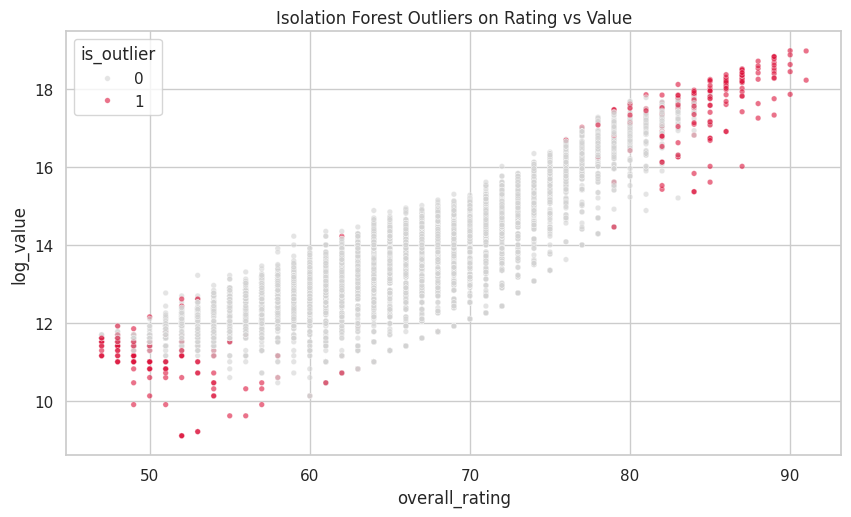

In [44]:
# حالا Isolation Forest که چندبعدی نگاه می‌کنه (contamination = ۲٪)
iso_cols = ["overall_rating", "potential", "age", "log_value", "bmi"]
iso = IsolationForest(contamination=0.02, random_state=RANDOM_STATE)
df["is_outlier"] = (iso.fit_predict(df[iso_cols]) == -1).astype(int)
df["anomaly_score"] = iso.decision_function(df[iso_cols])

print("تعداد بازیکن‌های مشکوک:", df["is_outlier"].sum())
print(df.groupby("pos_group")["is_outlier"].mean().reindex(pos_order).round(3).to_string())
display(df[df["is_outlier"] == 1].nsmallest(10, "anomaly_score")[["player_name", "position", "age", "overall_rating", "potential", "bmi", "value_eur"]])

plt.figure(figsize=(10, 5.5))
sns.scatterplot(data=df, x="overall_rating", y="log_value", hue="is_outlier", palette={0: "lightgray", 1: "crimson"}, alpha=0.6, s=16)
plt.title("Isolation Forest Outliers on Rating vs Value")
plt.show()

In [45]:
print("""برداشت اولیه:
- روش IQR روی خود `value_eur` حدود ۱۲٪ بازیکن‌ها رو پرت می‌دونه ولی روی `log_value` فقط ۳٫۷٪؛ یعنی «پرت» بودن بیشتر ناشی از چولگیه.
- Isolation Forest ۳۲۳ بازیکن (۲٪) رو مشکوک دونست: ستاره‌های جوان یا پرارزش مثل یامال، هالند و پدری، و بازیکن‌های خیلی مسن با رتبه‌ی پایین مثل دروازه‌بان‌های ۴۰ ساله. سهم دروازه‌بان‌ها در پرت‌ها (≈۴٪) بیشتر از بقیه‌ست.
- این‌ها خطای داده نیستن و ذاتی بازارن (ستاره‌های گران)، پس **هیچ‌کدوم حذف نمی‌شن**.
""")

برداشت اولیه:
- روش IQR روی خود `value_eur` حدود ۱۲٪ بازیکن‌ها رو پرت می‌دونه ولی روی `log_value` فقط ۳٫۷٪؛ یعنی «پرت» بودن بیشتر ناشی از چولگیه.
- Isolation Forest ۳۲۳ بازیکن (۲٪) رو مشکوک دونست: ستاره‌های جوان یا پرارزش مثل یامال، هالند و پدری، و بازیکن‌های خیلی مسن با رتبه‌ی پایین مثل دروازه‌بان‌های ۴۰ ساله. سهم دروازه‌بان‌ها در پرت‌ها (≈۴٪) بیشتر از بقیه‌ست.
- این‌ها خطای داده نیستن و ذاتی بازارن (ستاره‌های گران)، پس **هیچ‌کدوم حذف نمی‌شن**.



### 9.5 آزمون‌های آماری

In [46]:
# ۱) همبستگی پیرسون و اسپیرمن هر ویژگی با لگاریتم ارزش
# (اسپیرمن رو هم می‌ذاریم چون رابطه‌ها لزوماً خطی نیستن)
rows = []
for c in ["overall_rating", "potential", "age", "international_reputation", "contract_years_left", "face_dribbling", "height"]:
    r, p = stats.pearsonr(df[c], df["log_value"])
    rho, p2 = stats.spearmanr(df[c], df["log_value"])
    rows.append({"feature": c, "pearson_r": round(r, 3), "pearson_p": f"{p:.1e}", "spearman_rho": round(rho, 3), "spearman_p": f"{p2:.1e}"})
display(pd.DataFrame(rows).set_index("feature"))

,pearson_r,pearson_p,spearman_rho,spearman_p
feature,,,,
overall_rating,0.883,0.0e+00,0.867,0.0e+00
potential,0.857,0.0e+00,0.838,0.0e+00
age,-0.056,1.0e-12,-0.013,1.1e-01
international_reputation,0.479,0.0e+00,0.347,0.0e+00
contract_years_left,0.317,0.0e+00,0.294,0.0e+00
face_dribbling,0.657,0.0e+00,0.675,0.0e+00
height,-0.009,2.6e-01,-0.013,1.1e-01


In [47]:
# ۲) ANOVA: آیا میانگین log_value بین چهار گروه پست فرق می‌کنه؟ (Kruskal-Wallis به‌عنوان نسخه‌ی غیرپارامتری)
groups = [g["log_value"].values for _, g in df.groupby("pos_group")]
F, p_anova = stats.f_oneway(*groups)
H, p_kw = stats.kruskal(*groups)
ss_between = sum(len(g) * (g.mean() - df["log_value"].mean()) ** 2 for g in groups)
eta2 = ss_between / ((df["log_value"] - df["log_value"].mean()) ** 2).sum()
print(f"ANOVA:   F = {F:.2f} | p = {p_anova:.2e} | eta² = {eta2:.4f}")
print(f"Kruskal: H = {H:.2f} | p = {p_kw:.2e}")
print(df.groupby("pos_group")["log_value"].mean().reindex(pos_order).round(3).to_string())

ANOVA:   F = 209.61 | p = 2.19e-133 | eta² = 0.0376
Kruskal: H = 604.70 | p = 9.66e-131
pos_group
GK     13.307
DEF    13.928
MID    14.139
ATT    14.055


In [48]:
# ۳) t-test (Welch): آیا بازیکن‌های ۵ لیگ بزرگ به‌طور معنادار گران‌ترند؟
a = df.loc[df["top5_league"] == 1, "log_value"]
b = df.loc[df["top5_league"] == 0, "log_value"]
t, p_t = stats.ttest_ind(a, b, equal_var=False)
cohen_d = (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)
print(f"Welch t-test: t = {t:.2f} | p = {p_t:.2e} | Cohen's d = {cohen_d:.2f}")
med_top5 = df.loc[df["top5_league"] == 1, "value_eur"].median()
med_other = df.loc[df["top5_league"] == 0, "value_eur"].median()
print(f"میانه‌ی ارزش: ۵ لیگ بزرگ = {med_top5:,.0f}€ | بقیه = {med_other:,.0f}€ | نسبت = {med_top5 / med_other:.1f}x")

# ۴) t-test زوجی: آیا رتبه‌ی EA و رتبه‌ی FC26 (دو snapshot متفاوت) اختلاف معناداری دارن؟
diff = df["overall_rating"] - df["overall_fc26"]
t2, p_pair = stats.ttest_rel(df["overall_rating"], df["overall_fc26"])
print(f"\nPaired t-test (EA - FC26): میانگین اختلاف = {diff.mean():.3f} | t = {t2:.2f} | p = {p_pair:.2e}")
print("درصد بازیکن‌هایی که رتبه‌شون فرق دارد:", f"{(diff != 0).mean():.1%}", "| بیشترین اختلاف مطلق:", int(diff.abs().max()))

Welch t-test: t = 69.18 | p = 0.00e+00 | Cohen's d = 1.60
میانه‌ی ارزش: ۵ لیگ بزرگ = 5,500,000€ | بقیه = 900,000€ | نسبت = 6.1x

Paired t-test (EA - FC26): میانگین اختلاف = -0.030 | t = -12.59 | p = 3.40e-36
درصد بازیکن‌هایی که رتبه‌شون فرق دارد: 3.8% | بیشترین اختلاف مطلق: 5


In [49]:
# ۵) Chi-Square: آیا پای برتر به پست بازیکن وابسته است؟
ct = pd.crosstab(df["pos_group"], df["preferred_foot"]).reindex(pos_order)
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"Chi-square (position group × preferred foot): chi2 = {chi2:.1f} | dof = {dof} | p = {p_chi:.2e} | Cramér's V = {cramers_v:.3f}")
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))

# ۶) Chi-Square: آیا ستاره‌های جوان بیشتر در ۵ لیگ بزرگ متمرکز هستن؟
ct2 = pd.crosstab(df["is_wonderkid"], df["top5_league"])
chi2b, p_chi2, dof2, _ = stats.chi2_contingency(ct2)
print(f"\nChi-square (wonderkid × top-5 league): chi2 = {chi2b:.1f} | p = {p_chi2:.2e}")
print("سهم بازیکنان ۵ لیگ بزرگ در ستاره‌های جوان:", f"{df.loc[df['is_wonderkid'] == 1, 'top5_league'].mean():.1%}",
      "| در بقیه:", f"{df.loc[df['is_wonderkid'] == 0, 'top5_league'].mean():.1%}")

Chi-square (position group × preferred foot): chi2 = 542.0 | dof = 3 | p = 3.83e-117 | Cramér's V = 0.183
preferred_foot  Left  Right
pos_group                  
GK              11.1   88.9
DEF             34.4   65.6
MID             22.0   78.0
ATT             18.3   81.7

Chi-square (wonderkid × top-5 league): chi2 = 461.0 | p = 2.85e-102
سهم بازیکنان ۵ لیگ بزرگ در ستاره‌های جوان: 46.1% | در بقیه: 14.5%


In [50]:
print("""برداشت اولیه:
- **پیرسون/اسپیرمن:** رتبه (۰٫۸۸) و پتانسیل (۰٫۸۶) قوی‌ترین رابطه‌ها هستن. سن (r = ۰٫۰۶−) و قد (r ≈ ۰٫۰۱−) رابطه‌ی خطی ناچیز دارن (اسپیرمن سن و قد معنادار نیست).
- **ANOVA:** میانگین ارزش بین چهار گروه پست فرق معنادار دارد (F ≈ ۲۱۰، p ≈ ۱۰⁻¹³³)، اما اندازه‌ی اثر کوچکه (eta² ≈ ۰٫۰۴)؛ یعنی پست فقط حدود ۴٪ از تغییرات ارزش رو توضیح می‌ده. Kruskal-Wallis هم همین نتیجه رو تأیید کرد.
- **Welch t-test:** تفاوت ۵ لیگ بزرگ با بقیه بسیار بزرگه (Cohen's d ≈ ۱٫۶) و میانه‌ی ارزششون حدود ۶٫۱ برابره.
- **t-test زوجی:** اختلاف رتبه‌ی EA و FC26 از نظر آماری معناداره ولی از نظر عملی ناچیزه (میانگین ۰٫۰۳ امتیاز، فقط ۳٫۸٪ بازیکن‌ها متفاوت).
- **Chi-square:** پای برتر به پست وابسته است (Cramér's V ≈ ۰٫۱۸، اثر کوچک تا متوسط): ۳۴٪ مدافع‌ها چپ‌پا هستن (به‌خاطر LB) ولی فقط ۱۱٪ دروازه‌بان‌ها. ستاره‌های جوان هم به‌طور معناداری بیشتر در ۵ لیگ بزرگ‌اند (۴۶٪ در برابر ۱۴٫۵٪).
""")

برداشت اولیه:
- **پیرسون/اسپیرمن:** رتبه (۰٫۸۸) و پتانسیل (۰٫۸۶) قوی‌ترین رابطه‌ها هستن. سن (r = ۰٫۰۶−) و قد (r ≈ ۰٫۰۱−) رابطه‌ی خطی ناچیز دارن (اسپیرمن سن و قد معنادار نیست).
- **ANOVA:** میانگین ارزش بین چهار گروه پست فرق معنادار دارد (F ≈ ۲۱۰، p ≈ ۱۰⁻¹³³)، اما اندازه‌ی اثر کوچکه (eta² ≈ ۰٫۰۴)؛ یعنی پست فقط حدود ۴٪ از تغییرات ارزش رو توضیح می‌ده. Kruskal-Wallis هم همین نتیجه رو تأیید کرد.
- **Welch t-test:** تفاوت ۵ لیگ بزرگ با بقیه بسیار بزرگه (Cohen's d ≈ ۱٫۶) و میانه‌ی ارزششون حدود ۶٫۱ برابره.
- **t-test زوجی:** اختلاف رتبه‌ی EA و FC26 از نظر آماری معناداره ولی از نظر عملی ناچیزه (میانگین ۰٫۰۳ امتیاز، فقط ۳٫۸٪ بازیکن‌ها متفاوت).
- **Chi-square:** پای برتر به پست وابسته است (Cramér's V ≈ ۰٫۱۸، اثر کوچک تا متوسط): ۳۴٪ مدافع‌ها چپ‌پا هستن (به‌خاطر LB) ولی فقط ۱۱٪ دروازه‌بان‌ها. ستاره‌های جوان هم به‌طور معناداری بیشتر در ۵ لیگ بزرگ‌اند (۴۶٪ در برابر ۱۴٫۵٪).



### 9.6 خوشه‌بندی اکتشافی: سبک‌های بازی

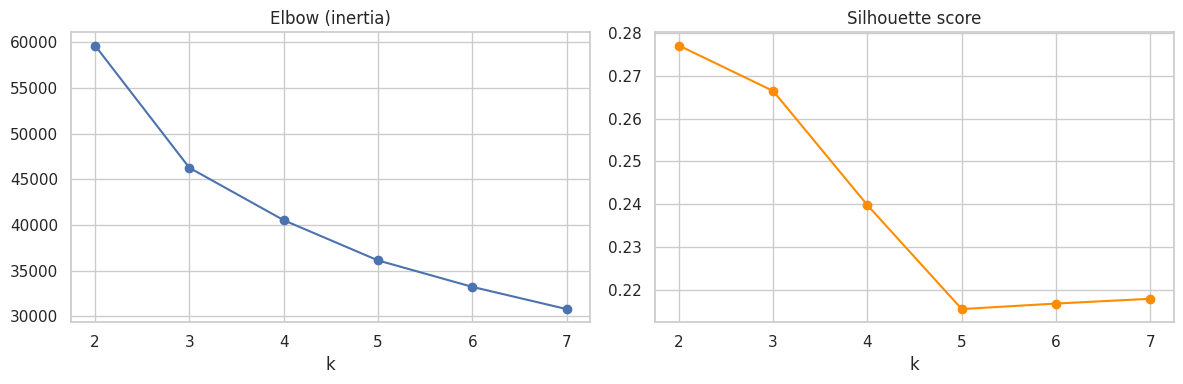

silhouette: {2: 0.277, 3: 0.266, 4: 0.24, 5: 0.215, 6: 0.217, 7: 0.218} | k انتخابی: 3


In [51]:
# بازیکنان میدانی رو بر اساس شش آمار اصلی کارت خوشه‌بندی می‌کنیم
# (دروازه‌بان‌ها جدا هستن، پس کنارشون می‌ذاریم)
out = df[df["is_gk"] == 0].copy()
X_face = StandardScaler().fit_transform(out[face_stats])

sil, inertia = {}, {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_face)
    sil[k] = silhouette_score(X_face, km.labels_, sample_size=4000, random_state=RANDOM_STATE)
    inertia[k] = km.inertia_

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(inertia), list(inertia.values()), marker="o"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(list(sil), list(sil.values()), marker="o", color="darkorange"); ax[1].set_title("Silhouette score"); ax[1].set_xlabel("k")
plt.tight_layout()
plt.show()

# k رو از بین ۳ تا ۶ انتخاب می‌کنیم (k=2 معمولاً فقط مدافع/مهاجم رو جدا می‌کنه)
best_k = max(range(3, 7), key=lambda k: sil[k])
print("silhouette:", {k: round(v, 3) for k, v in sil.items()}, "| k انتخابی:", best_k)

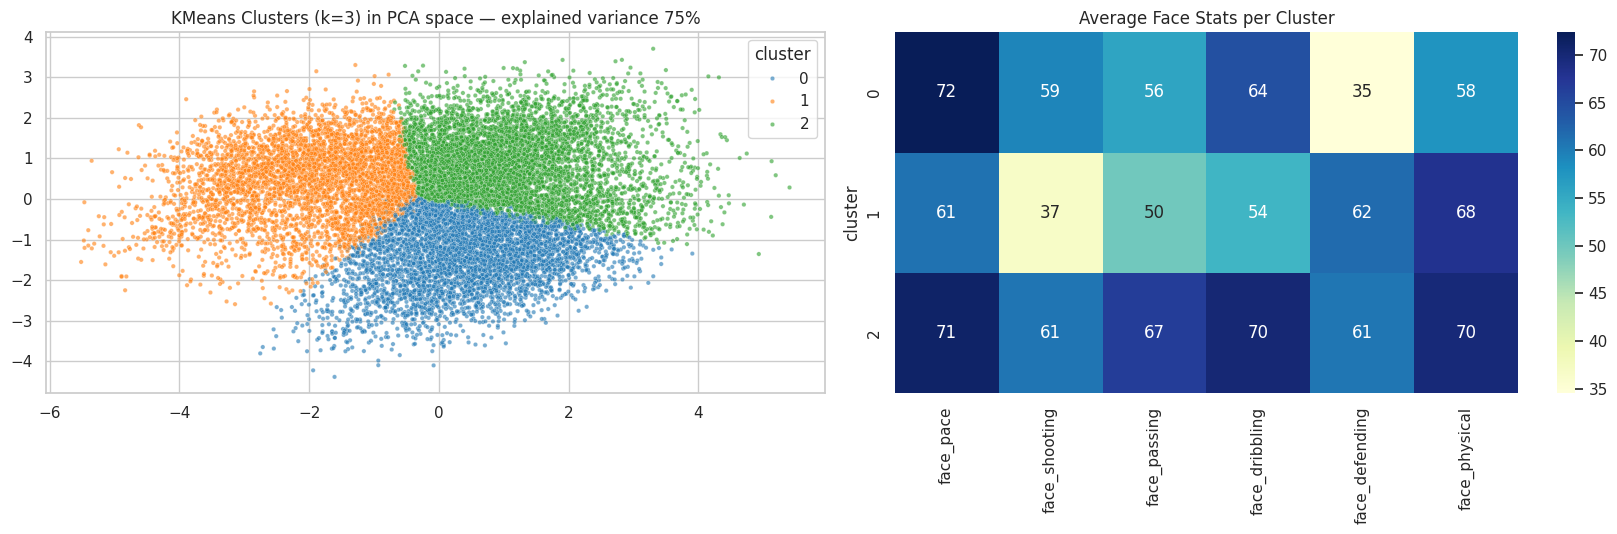

position  CAM  CB  CDM  CM  LB  LM  LW  RB  RM  RW  ST
cluster                                               
0          12   0    1   8   2  15   5   2  13   6  37
1           0  60   10   5  11   0   0  12   0   0   1
2           7   8   14  25  12   5   1  12   6   1   8

میانگین ارزش هر خوشه (میلیون یورو):
cluster
0    1.39
1    1.30
2    6.55


In [52]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(X_face)
out["cluster"] = km.labels_

# نمایش ۲ بعدی با PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_face)
fig, ax = plt.subplots(1, 2, figsize=(17, 5.5))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=out["cluster"], palette="tab10", s=10, alpha=0.6, ax=ax[0])
ax[0].set_title(f"KMeans Clusters (k={best_k}) in PCA space — explained variance {pca.explained_variance_ratio_.sum():.0%}")
profile = out.groupby("cluster")[face_stats].mean()
sns.heatmap(profile, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax[1])
ax[1].set_title("Average Face Stats per Cluster")
plt.tight_layout()
plt.show()

# هر خوشه بیشتر شامل کدوم پست‌هاست؟
print((pd.crosstab(out["cluster"], out["position"], normalize="index") * 100).round(0).astype(int))
print("\nمیانگین ارزش هر خوشه (میلیون یورو):")
print((out.groupby("cluster")["value_eur"].mean() / 1e6).round(2).to_string())

In [53]:
print("""برداشت اولیه:
- بهترین k بین ۳ تا ۶ برابر ۳ است ولی silhouette حدود ۰٫۲۷ است؛ یعنی خوشه‌ها مرز تیز ندارن و سبک‌های بازی بیشتر یک پیوستارند.
- خوشه‌ها: (۰) بازیکنان سریع و تهاجمی با pace بالا و defending پایین (مثلاً ۳۷٪ مهاجم)؛ (۱) بازیکنان دفاعی با defending و physical بالا و shooting پایین (۶۰٪ CB)؛ (۲) بازیکنان همه‌فن‌حریف با آمار بالاتر در همه‌ی بخش‌ها.
- خوشه‌ی همه‌فن‌حریف میانگین ارزش ۶٫۵ میلیون دارد در برابر حدود ۱٫۳ تا ۱٫۴ برای دو خوشه‌ی دیگه؛ یعنی خوشه‌بندی بیشتر «کیفیت کلی» رو جدا کرده تا صرفاً سبک بازی.
""")

برداشت اولیه:
- بهترین k بین ۳ تا ۶ برابر ۳ است ولی silhouette حدود ۰٫۲۷ است؛ یعنی خوشه‌ها مرز تیز ندارن و سبک‌های بازی بیشتر یک پیوستارند.
- خوشه‌ها: (۰) بازیکنان سریع و تهاجمی با pace بالا و defending پایین (مثلاً ۳۷٪ مهاجم)؛ (۱) بازیکنان دفاعی با defending و physical بالا و shooting پایین (۶۰٪ CB)؛ (۲) بازیکنان همه‌فن‌حریف با آمار بالاتر در همه‌ی بخش‌ها.
- خوشه‌ی همه‌فن‌حریف میانگین ارزش ۶٫۵ میلیون دارد در برابر حدود ۱٫۳ تا ۱٫۴ برای دو خوشه‌ی دیگه؛ یعنی خوشه‌بندی بیشتر «کیفیت کلی» رو جدا کرده تا صرفاً سبک بازی.



## 10. Feature Selection

سه سوال مهم قبل از مدل‌سازی:
1. کدوم ستون‌ها **نشت اطلاعات (Data Leakage)** دارند؟
2. کدوم ستون‌ها تکراری یا مشتق‌شده‌ی ستون‌های دیگه‌اند؟
3. کدوم ویژگی‌های عددی همبستگی خیلی بالا با هم دارند؟

In [54]:
# اول ببینیم wage_eur و release_clause_eur چه رابطه‌ای با ارزش دارند
corr_wage = np.corrcoef(np.log1p(df["wage_eur"]), df["log_value"])[0, 1]
ratio = (df["release_clause_eur"] / df["value_eur"]).dropna()
print(f"همبستگی log(wage) با log(value): {corr_wage:.3f}")
print(f"نسبت release_clause به value -> میانه: {ratio.median():.2f} | چارک اول تا سوم: {ratio.quantile(0.25):.2f} تا {ratio.quantile(0.75):.2f}")
print(f"همبستگی رتبه‌ی EA و overall_rating (اسپیرمن): {abs(df[['rank', 'overall_rating']].corr(method='spearman').iloc[0, 1]):.3f}")
print(f"همبستگی overall_rating و overall_fc26: {df[['overall_rating', 'overall_fc26']].corr().iloc[0, 1]:.4f}")

همبستگی log(wage) با log(value): 0.816
نسبت release_clause به value -> میانه: 1.75 | چارک اول تا سوم: 1.55 تا 2.00
همبستگی رتبه‌ی EA و overall_rating (اسپیرمن): 0.999
همبستگی overall_rating و overall_fc26: 0.9990


In [55]:
# ستون‌هایی که وارد مدل نمی‌شن و دلیلش
excluded = pd.DataFrame([
    ("value_eur, log_value", "متغیر هدف"),
    ("release_clause_eur", "تقریباً ضریبی از خود ارزش بازار است (نشت اطلاعات)"),
    ("wage_eur", "خروجی/نتیجه‌ی همان ارزش‌گذاری است، نه ویژگی مستقل"),
    ("rank", "از روی overall_rating ساخته شده"),
    ("overall_fc26", "تکراری overall_rating (همبستگی ≈ ۰.۹۹۹)"),
    ("age_ea", "تکراری age با یک snapshot دیگر"),
    ("player_type, position_type, pos_group", "مشتق از position / is_gk"),
    ("club_contract_valid_until_year", "در contract_years_left خلاصه شده"),
    ("play_styles, play_styles_plus, alternate_positions", "متنی‌اند؛ تعدادشان به‌عنوان ویژگی وارد شده"),
    ("id, player_name, birthdate", "شناسه یا هویت"),
    ("team, club_name, nationality, league_name", "تعداد سطح‌های زیاد؛ اثر اصلی‌شان در league_level, top5_league و international_reputation هست"),
    ("age_group, is_wonderkid, is_outlier, anomaly_score", "ستون‌های کمکی EDA"),
], columns=["column(s)", "reason"])
display(excluded)

,column(s),reason
0,"value_eur, log_value",متغیر هدف
1,release_clause_eur,تقریباً ضریبی از خود ارزش بازار است (نشت اطلاعات)
2,wage_eur,خروجی/نتیجه‌ی همان ارزش‌گذاری است، نه ویژگی مستقل
3,rank,از روی overall_rating ساخته شده
4,overall_fc26,تکراری overall_rating (همبستگی ≈ ۰.۹۹۹)
5,age_ea,تکراری age با یک snapshot دیگر
6,"player_type, position_type, pos_group",مشتق از position / is_gk
7,club_contract_valid_until_year,در contract_years_left خلاصه شده
8,"play_styles, play_styles_plus, alternate_posit...",متنی‌اند؛ تعدادشان به‌عنوان ویژگی وارد شده
9,"id, player_name, birthdate",شناسه یا هویت


In [56]:
# ویژگی‌های کاندید
base_num = ["overall_rating", "potential", "age", "potential_gap", "height", "weight", "bmi", "skill_moves", "weak_foot_ability",
            "international_reputation", "league_level", "contract_years_left", "n_play_styles", "n_play_styles_plus",
            "n_alt_positions", "top5_league", "is_gk"]
candidate_num = base_num + face_stats + detail_attrs + gk_attrs
candidate_cat = ["position", "preferred_foot"]

# جفت‌ویژگی‌هایی که همبستگی مطلقشون از ۰.۹۵ بیشتره: از هر جفت، اونی که با هدف رابطه‌ی ضعیف‌تری داره حذف می‌شه
# (چهار ستون اصلی محافظت‌شده هستن)
corr_abs = df[candidate_num].corr().abs()
target_corr = df[candidate_num].corrwith(df["log_value"]).abs()
protected = {"overall_rating", "potential", "age", "is_gk"}

to_drop, pairs = set(), []
for a, b in itertools.combinations(candidate_num, 2):
    if a in to_drop or b in to_drop or corr_abs.loc[a, b] <= 0.95:
        continue
    drop = a if target_corr[a] < target_corr[b] else b
    if drop in protected:
        drop = b if drop == a else a
    to_drop.add(drop)
    pairs.append((a, b, round(corr_abs.loc[a, b], 3), drop))

print(pd.DataFrame(pairs, columns=["feature_a", "feature_b", "|r|", "dropped"]).to_string(index=False))
final_num = [c for c in candidate_num if c not in to_drop]
final_cat = candidate_cat
print(f"\nویژگی‌های عددی: {len(candidate_num)} -> {len(final_num)} | دسته‌ای: {final_cat}")

          feature_a           feature_b   |r|         dropped
              is_gk           gk_diving 0.978       gk_diving
              is_gk         gk_handling 0.977     gk_handling
              is_gk          gk_kicking 0.975      gk_kicking
              is_gk      gk_positioning 0.975  gk_positioning
              is_gk         gk_reflexes 0.977     gk_reflexes
          dribbling        ball_control 0.951       dribbling
      interceptions defensive_awareness 0.958   interceptions
defensive_awareness     standing_tackle 0.958 standing_tackle
defensive_awareness      sliding_tackle 0.954  sliding_tackle

ویژگی‌های عددی: 57 -> 48 | دسته‌ای: ['position', 'preferred_foot']


In [57]:
print("""برداشت اولیه:
- ۹ ویژگی به‌خاطر همبستگی بیشتر از ۰٫۹۵ حذف شد: پنج آمار GK (چون با `is_gk` تقریباً یکی‌اند و اطلاعات‌شون از طریق شش آمار اصلی کارت که برای GK همون آمار GK هستن حفظ می‌شه)، `dribbling` (در برابر ball_control) و سه ویژگی دفاعی (interceptions، standing_tackle، sliding_tackle که با defensive_awareness هم‌پوشانی دارن).
- تعداد ویژگی‌های عددی از ۵۷ به ۴۸ رسید. برای مدل‌های درختی این حذف ضروری نبود، ولی برای Linear Regression، KNN و MLP مفیده.
""")

برداشت اولیه:
- ۹ ویژگی به‌خاطر همبستگی بیشتر از ۰٫۹۵ حذف شد: پنج آمار GK (چون با `is_gk` تقریباً یکی‌اند و اطلاعات‌شون از طریق شش آمار اصلی کارت که برای GK همون آمار GK هستن حفظ می‌شه)، `dribbling` (در برابر ball_control) و سه ویژگی دفاعی (interceptions، standing_tackle، sliding_tackle که با defensive_awareness هم‌پوشانی دارن).
- تعداد ویژگی‌های عددی از ۵۷ به ۴۸ رسید. برای مدل‌های درختی این حذف ضروری نبود، ولی برای Linear Regression، KNN و MLP مفیده.



## 11. آماده‌سازی داده برای Machine Learning

- `X`: ویژگی‌های نهایی، `y`: `log_value`
- تقسیم ۸۰/۲۰ با `stratify` روی گروه پست (تا نسبت دروازه‌بان/مدافع/هافبک/مهاجم در Train و Test یکسان باشه)
- Scaling فقط روی ستون‌های عددی و One-Hot Encoding برای ستون‌های دسته‌ای — هر دو **فقط روی Train** فیت می‌شن (برای جلوگیری از نشت اطلاعات).

In [58]:
X = df[final_num + final_cat].copy()
y = df["log_value"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=df["pos_group"])
print("Train:", X_train.shape, "| Test:", X_test.shape)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), final_num),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), final_cat),
])
X_train_s = preprocessor.fit_transform(X_train)
X_test_s = preprocessor.transform(X_test)
feature_names = [n.split("__", 1)[1] for n in preprocessor.get_feature_names_out()]
print("تعداد ویژگی بعد از پردازش:", X_train_s.shape[1])
print("نسبت گروه‌های پست در Train و Test:")
print(pd.concat([df.loc[X_train.index, "pos_group"].value_counts(normalize=True).rename("train"),
                 df.loc[X_test.index, "pos_group"].value_counts(normalize=True).rename("test")], axis=1).round(3))

Train:

 (12885, 50) | Test: (3222, 50)
تعداد ویژگی بعد از پردازش: 62
نسبت گروه‌های پست در Train و Test:
           train   test
pos_group              
MID        0.375  0.375
DEF        0.335  0.335
ATT        0.178  0.178
GK         0.112  0.112


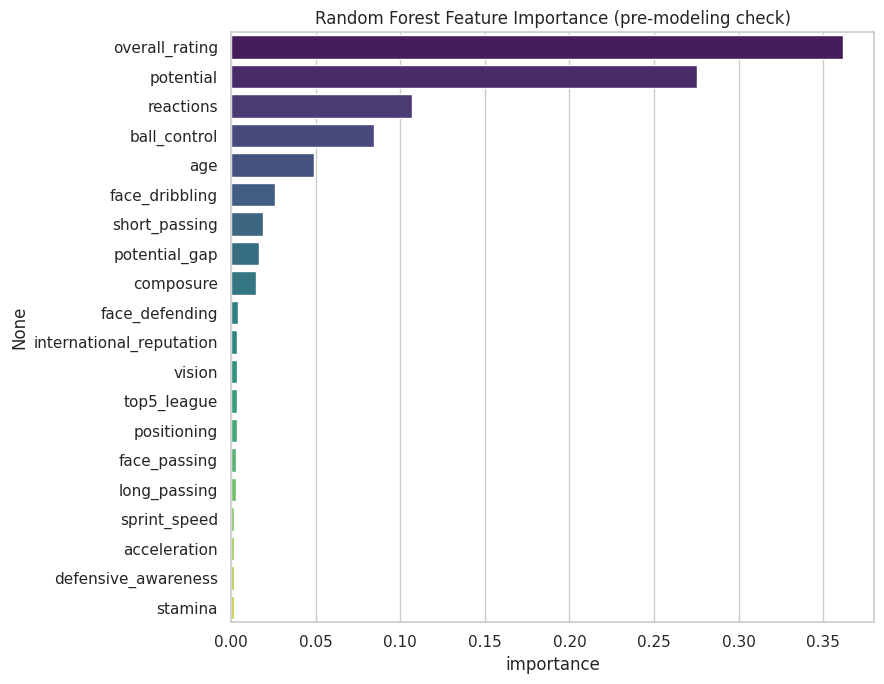

سهم ۵ ویژگی اول از کل اهمیت: 87.8%
ویژگی‌هایی با اهمیت کمتر از ۰.۰۰۱: 36 از 62


In [59]:
# یه نگاه سریع به اهمیت ویژگی‌ها قبل از مدل‌سازی (فقط روی داده‌ی Train)
rf_probe = RandomForestRegressor(n_estimators=120, max_features=0.4, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE)
rf_probe.fit(X_train_s, y_train)
probe_imp = pd.Series(rf_probe.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=probe_imp.head(20).values, y=probe_imp.head(20).index, hue=probe_imp.head(20).index, palette="viridis", legend=False)
plt.title("Random Forest Feature Importance (pre-modeling check)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()
print("سهم ۵ ویژگی اول از کل اهمیت:", f"{probe_imp.head(5).sum():.1%}")
print("ویژگی‌هایی با اهمیت کمتر از ۰.۰۰۱:", int((probe_imp < 0.001).sum()), "از", len(probe_imp))

In [60]:
print(f"""برداشت اولیه:
- پنج ویژگی مهم‌تر: {', '.join(probe_imp.head(5).index)} — روی هم {probe_imp.head(5).sum():.0%} از کل اهمیت رو دارن.
- {int((probe_imp < 0.001).sum())} ویژگی از {len(probe_imp)} ویژگی اهمیت تقریباً صفر دارن؛ برای مدل‌های درختی مشکلی ایجاد نمی‌کنن، ولی نشون می‌ده بخش بزرگی از ارزش با چند ویژگی اصلی توضیح داده می‌شه.
""")

برداشت اولیه:
- پنج ویژگی مهم‌تر: overall_rating, potential, reactions, ball_control, age — روی هم 88% از کل اهمیت رو دارن.
- 36 ویژگی از 62 ویژگی اهمیت تقریباً صفر دارن؛ برای مدل‌های درختی مشکلی ایجاد نمی‌کنن، ولی نشون می‌ده بخش بزرگی از ارزش با چند ویژگی اصلی توضیح داده می‌شه.



## 12. مدل‌های Machine Learning

۱۲ الگوریتم Regression آموزش داده می‌شود. مدل‌ها روی `log_value` آموزش می‌بینند؛ معیارها هم روی همین مقیاس گزارش می‌شوند و برای درک بهتر، **MAE به یورو** هم (بعد از `expm1`) محاسبه می‌شود.

In [61]:
# تابع ارزیابی: معیارهای رگرسیون روی مقیاس لگاریتمی + خطای میانگین به یورو
def evaluate_regression(y_true_log, y_pred_log):
    mse = mean_squared_error(y_true_log, y_pred_log)
    return {
        "MAE": mean_absolute_error(y_true_log, y_pred_log),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true_log, y_pred_log),
        "MAE_EUR": mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log)),
    }

ml_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(min_samples_leaf=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=250, max_features=0.5, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesRegressor(n_estimators=250, max_features=0.7, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.08, max_depth=4, subsample=0.8, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostRegressor(n_estimators=150, learning_rate=0.5, random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(n_neighbors=8, weights="distance", n_jobs=-1),
    "SVR": SVR(C=5, epsilon=0.05),
    "XGBoost": XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=700, learning_rate=0.05, num_leaves=31, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=900, learning_rate=0.08, depth=6, random_seed=RANDOM_STATE, verbose=0),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=500, learning_rate=0.06, random_state=RANDOM_STATE),
}
print("تعداد مدل‌ها:", len(ml_models))

تعداد مدل‌ها: 12


In [62]:
# آموزش همه‌ی مدل‌ها و ثبت نتایج (بسته به سیستم چند دقیقه طول می‌کشه)
ml_rows, ml_preds = [], {}
for name, model in ml_models.items():
    t0 = time.time()
    model.fit(X_train_s, y_train)
    fit_time = time.time() - t0
    pred_test = model.predict(X_test_s)
    ml_preds[name] = pred_test
    row = {"Model": name, "Train_R2": r2_score(y_train, model.predict(X_train_s)), **evaluate_regression(y_test, pred_test), "Fit_time_s": fit_time}
    ml_rows.append(row)
    print(f"✔ {name:<22} R2 test = {row['R2']:.4f} | RMSE = {row['RMSE']:.4f} | {fit_time:.1f}s")

ml_results = pd.DataFrame(ml_rows).sort_values("RMSE").reset_index(drop=True)

✔ Linear Regression      R2 test = 0.9677 | RMSE = 0.2259 | 0.0s


✔ Decision Tree          R2 test = 0.9929 | RMSE = 0.1062 | 0.3s


✔ Random Forest          R2 test = 0.9964 | RMSE = 0.0754 | 25.4s


✔ Extra Trees            R2 test = 0.9959 | RMSE = 0.0803 | 16.6s


✔ Gradient Boosting      R2 test = 0.9976 | RMSE = 0.0612 | 20.1s


...

✔ SVR                    R2 test = 0.9847 | RMSE = 0.1554 | 76.5s


✔ XGBoost                R2 test = 0.9977 | RMSE = 0.0606 | 1.4s


✔ LightGBM               R2 test = 0.9978 | RMSE = 0.0591 | 1.8s


✔ CatBoost               R2 test = 0.9983 | RMSE = 0.0521 | 4.0s


✔ HistGradientBoosting   R2 test = 0.9976 | RMSE = 0.0612 | 1.4s


### 12.1 جدول مقایسه‌ی مدل‌های ML

,Model,Train_R2,MAE,MSE,RMSE,R2,MAE_EUR,Fit_time_s
0,CatBoost,0.9993,0.0293,0.0027,0.0521,0.9983,89403.8059,4.0152
1,LightGBM,0.9995,0.0356,0.0035,0.0591,0.9978,114881.0632,1.7524
2,XGBoost,0.9992,0.0383,0.0037,0.0606,0.9977,123815.1487,1.4486
3,Gradient Boosting,0.9986,0.0388,0.0037,0.0612,0.9976,105121.7881,20.1277
4,HistGradientBoosting,0.9988,0.0361,0.0037,0.0612,0.9976,108728.5201,1.3972
5,Random Forest,0.9992,0.0456,0.0057,0.0754,0.9964,156848.8823,25.4222
6,Extra Trees,0.9998,0.0452,0.0064,0.0803,0.9959,159092.9570,16.6397
7,Decision Tree,0.9978,0.0595,0.0113,0.1062,0.9929,217944.0221,0.2822
8,SVR,0.9971,0.1064,0.0241,0.1554,0.9847,395036.9838,76.5144
9,Linear Regression,0.9708,0.1637,0.0510,0.2259,0.9677,599866.5014,0.0308



🏆 بهترین مدل ML (کمترین RMSE): CatBoost


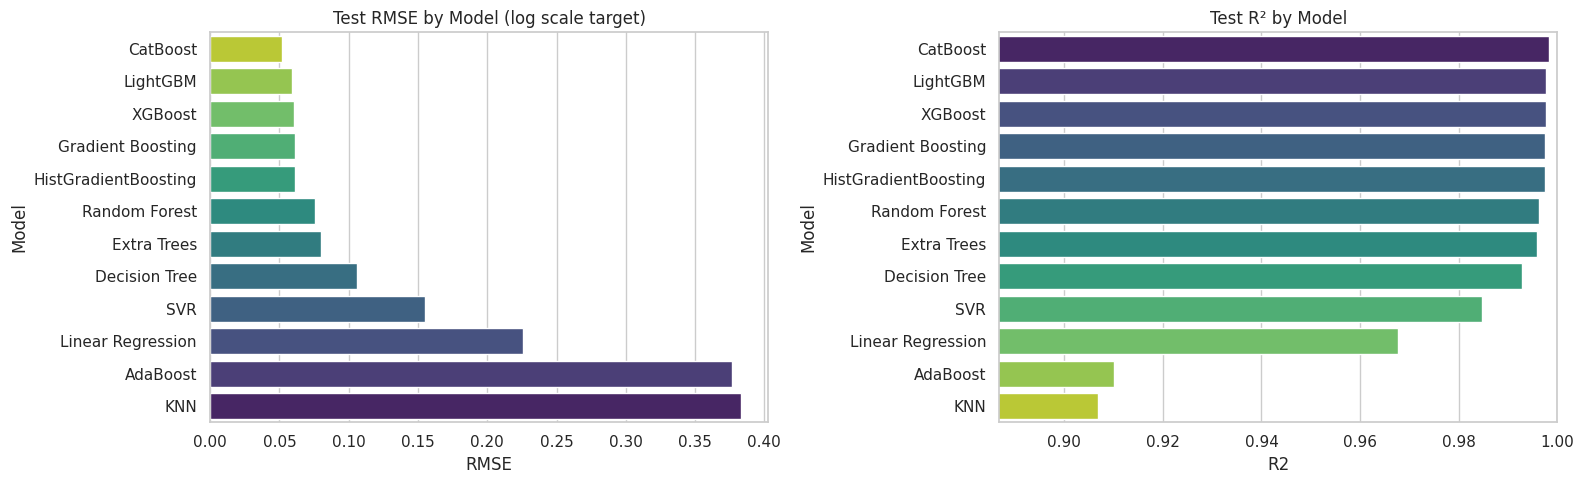

In [63]:
display(ml_results.round(4))

best_ml_name = ml_results.loc[0, "Model"]
best_ml_model = ml_models[best_ml_name]
print(f"\n🏆 بهترین مدل ML (کمترین RMSE): {best_ml_name}")

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
order = ml_results["Model"]
sns.barplot(data=ml_results, y="Model", x="RMSE", order=order, hue="Model", palette="viridis_r", legend=False, ax=ax[0])
ax[0].set_title("Test RMSE by Model (log scale target)")
sns.barplot(data=ml_results, y="Model", x="R2", order=order, hue="Model", palette="viridis", legend=False, ax=ax[1])
ax[1].set_xlim(max(0, ml_results["R2"].min() - 0.02), 1.0)
ax[1].set_title("Test R² by Model")
plt.tight_layout()
plt.show()

In [64]:
# بررسی Overfitting: فاصله‌ی R² آموزش و آزمون
gap = (ml_results.set_index("Model")["Train_R2"] - ml_results.set_index("Model")["R2"]).sort_values(ascending=False)
print("فاصله‌ی R² آموزش و آزمون (بیشتر = احتمال Overfitting بیشتر):")
print(gap.round(4).to_string())

فاصله‌ی R² آموزش و آزمون (بیشتر = احتمال Overfitting بیشتر):
Model
KNN                     0.0932
SVR                     0.0124
AdaBoost                0.0055
Decision Tree           0.0050
Extra Trees             0.0038
Linear Regression       0.0032
Random Forest           0.0028
LightGBM                0.0017
XGBoost                 0.0015
HistGradientBoosting    0.0012
CatBoost                0.0010
Gradient Boosting       0.0010


### 12.2 ارزیابی دقیق‌تر بهترین مدل ML

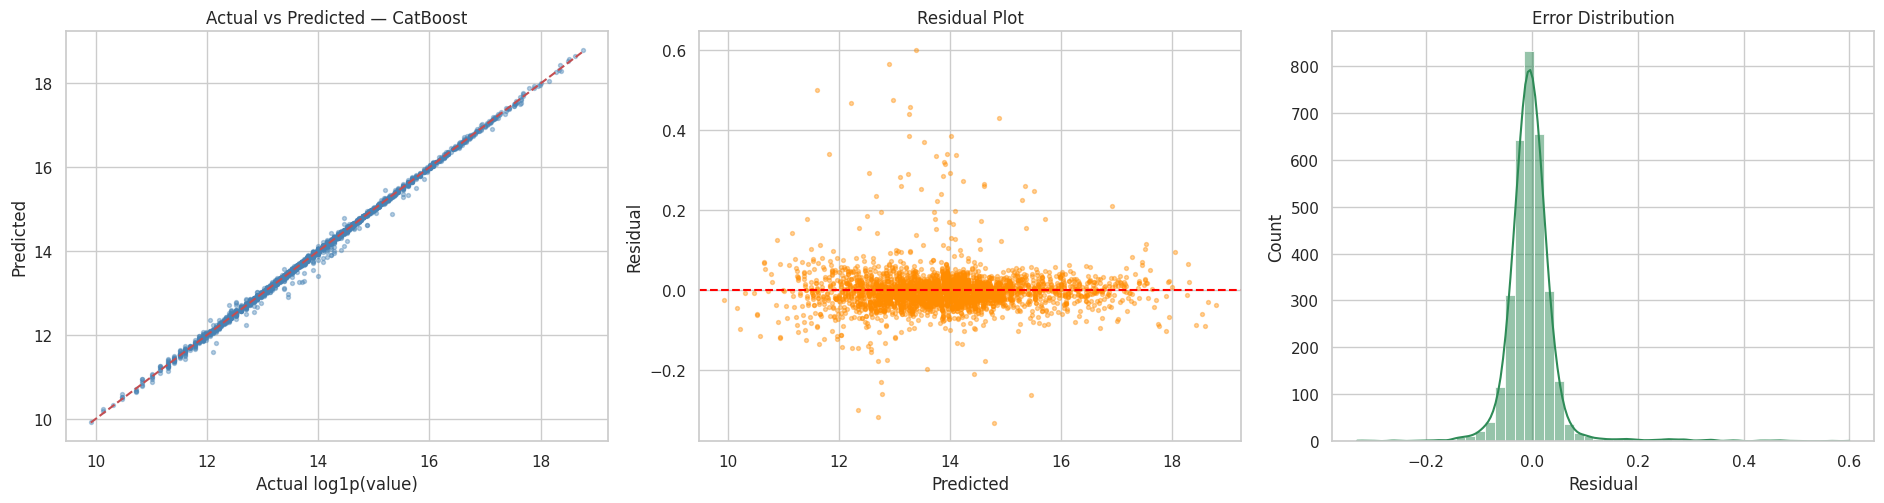

میانگین خطا: -0.0014 | انحراف معیار خطا: 0.0521


In [65]:
# Actual vs Predicted، Residual Plot و توزیع خطا برای بهترین مدل
pred_best = ml_preds[best_ml_name]
resid = y_test.values - pred_best

fig, ax = plt.subplots(1, 3, figsize=(19, 5.2))
ax[0].scatter(y_test, pred_best, s=8, alpha=0.4, color="steelblue")
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, "r--", lw=1.5)
ax[0].set_xlabel("Actual log1p(value)"); ax[0].set_ylabel("Predicted"); ax[0].set_title(f"Actual vs Predicted — {best_ml_name}")
ax[1].scatter(pred_best, resid, s=8, alpha=0.4, color="darkorange")
ax[1].axhline(0, color="red", ls="--")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Residual"); ax[1].set_title("Residual Plot")
sns.histplot(resid, kde=True, bins=50, ax=ax[2], color="seagreen")
ax[2].set_title("Error Distribution"); ax[2].set_xlabel("Residual")
plt.tight_layout()
plt.show()
print(f"میانگین خطا: {resid.mean():.4f} | انحراف معیار خطا: {resid.std():.4f}")

In [66]:
# خطای درصدی به یورو در بازه‌های مختلف ارزش (کدوم بخش بازار سخت‌تر پیش‌بینی می‌شه؟)
actual_eur = np.expm1(y_test.values)
pred_eur = np.expm1(pred_best)
ape = np.abs(pred_eur - actual_eur) / actual_eur
buckets = pd.cut(actual_eur, bins=[0, 1e6, 5e6, 20e6, 1e9], labels=["<1M", "1-5M", "5-20M", "20M+"])
bucket_table = pd.DataFrame({"bucket": buckets, "ape": ape, "abs_err_eur": np.abs(pred_eur - actual_eur)}).groupby("bucket", observed=True).agg(
    players=("ape", "size"), median_APE_pct=("ape", lambda s: 100 * s.median()), mean_abs_error_eur=("abs_err_eur", "mean")).round(1)
display(bucket_table)

,players,median_APE_pct,mean_abs_error_eur
bucket,,,
<1M,1626,2.0,13890.0
1-5M,1247,1.9,53819.3
5-20M,267,1.7,239137.1
20M+,82,2.2,1640387.0


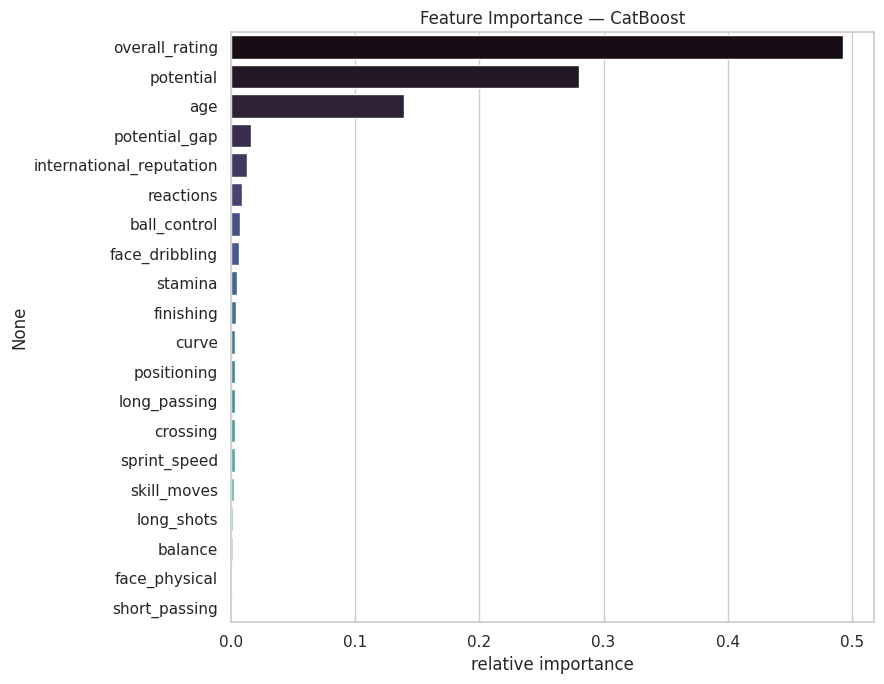

5-fold CV R² (CatBoost): 0.9983 ± 0.0002 | R² روی Test: 0.9983


In [67]:
# اهمیت ویژگی‌ها در بهترین مدل (اگه مدل feature_importances_ داشته باشه، وگرنه Permutation Importance)
if hasattr(best_ml_model, "feature_importances_"):
    imp = pd.Series(best_ml_model.feature_importances_, index=feature_names)
    imp_title = f"Feature Importance — {best_ml_name}"
else:
    from sklearn.inspection import permutation_importance
    pi = permutation_importance(best_ml_model, X_test_s[:3000], y_test.values[:3000], n_repeats=3, random_state=RANDOM_STATE)
    imp = pd.Series(pi.importances_mean, index=feature_names)
    imp_title = f"Permutation Importance — {best_ml_name}"
imp = (imp / imp.sum()).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=imp.head(20).values, y=imp.head(20).index, hue=imp.head(20).index, palette="mako", legend=False)
plt.title(imp_title); plt.xlabel("relative importance")
plt.tight_layout()
plt.show()

# اعتبارسنجی ۵-فولد روی Train برای اینکه مطمئن بشیم نتیجه به یه تقسیم خاص وابسته نیست
from sklearn.base import clone
cv_r2 = cross_val_score(clone(best_ml_model), X_train_s, y_train, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
print(f"5-fold CV R² ({best_ml_name}): {cv_r2.mean():.4f} ± {cv_r2.std():.4f} | R² روی Test: {ml_results.loc[0, 'R2']:.4f}")

In [68]:
_top3 = ml_results.head(3)
_bottom2 = ml_results.tail(2)
_fmt = lambda t: ", ".join(r.Model + " (R²=" + format(r.R2, ".4f") + ")" for r in t.itertuples())
_lin_r2 = ml_results.loc[ml_results["Model"] == "Linear Regression", "R2"].iloc[0]
print(f"""برداشت اولیه:
- سه مدل برتر: {_fmt(_top3)}. اختلاف مدل‌های Boosting با هم خیلی کمه.
- ضعیف‌ترین‌ها: {_fmt(_bottom2)}. KNN و AdaBoost با فضای چندبعدی و رابطه‌ی غیرخطی سن و ارزش مشکل دارن.
- Linear Regression با R²={_lin_r2:.4f} هم بد نیست، چون رابطه‌ی اصلی (لگاریتم ارزش با رتبه و پتانسیل) تقریباً خطیه؛ مدل‌های درختی باقی‌مونده‌ی غیرخطی سن و اثر تعاملی رو می‌گیرن.
- خطای درصدی میانه در همه‌ی بازه‌های ارزشی نزدیک به هم است؛ یعنی مدل هم برای بازیکن ارزان و هم گران دقت نسبی مشابهی داره (خطای یورویی در بازه‌ی گران‌ها بزرگ‌تره چون خود ارزش بزرگ‌تره).
""")

برداشت اولیه:
- سه مدل برتر: CatBoost (R²=0.9983), LightGBM (R²=0.9978), XGBoost (R²=0.9977). اختلاف مدل‌های Boosting با هم خیلی کمه.
- ضعیف‌ترین‌ها: AdaBoost (R²=0.9100), KNN (R²=0.9068). KNN و AdaBoost با فضای چندبعدی و رابطه‌ی غیرخطی سن و ارزش مشکل دارن.
- Linear Regression با R²=0.9677 هم بد نیست، چون رابطه‌ی اصلی (لگاریتم ارزش با رتبه و پتانسیل) تقریباً خطیه؛ مدل‌های درختی باقی‌مونده‌ی غیرخطی سن و اثر تعاملی رو می‌گیرن.
- خطای درصدی میانه در همه‌ی بازه‌های ارزشی نزدیک به هم است؛ یعنی مدل هم برای بازیکن ارزان و هم گران دقت نسبی مشابهی داره (خطای یورویی در بازه‌ی گران‌ها بزرگ‌تره چون خود ارزش بزرگ‌تره).



## 13. Deep Learning

**معماری:** داده‌ی ما جدولی (Tabular) است، پس معماری مناسب **MLP (لایه‌های Dense)** است؛ نه CNN چون تصویر نداریم، نه LSTM چون ترتیب زمانی نداریم.

**نوع مسئله: Regression** — طبق جدول Compile: خروجی `linear` (یک نورون Dense بدون activation)، loss = `mean_squared_error`، optimizer = `adam`.

**مدل‌ها:**
1. **Model 1 — Baseline:** یک لایه‌ی مخفی ساده
2. **Model 2 — Improved:** عمیق‌تر و با ظرفیت بیشتر
3. **Model 3 — Regularized:** با BatchNormalization و Dropout
4. **⭐ Model 4 — Bonus:** عریض‌تر + ReduceLROnPlateau؛ فقط اگه بهبود معنادار داشته باشه (بیش از ۲٪ کاهش RMSE نسبت به بهترین مدل ۱ تا ۳) وارد مقایسه‌ی اصلی می‌شود.

**Batch Size = 256** (حدود ۱۳ هزار نمونه‌ی آموزش) و **حداکثر ۱۵۰ Epoch** با EarlyStopping (`patience=20`). چون هدف لگاریتمی حدود ۱۴ است، برای پایداری آموزش هدف رو برای DL استاندارد می‌کنیم و بعد از پیش‌بینی برمی‌گردونیم.

In [69]:
# اول دیتا رو آماده می‌کنیم: ویژگی‌ها قبلاً scale شدن، هدف رو هم استاندارد می‌کنیم
x_train, x_test = X_train_s.astype("float32"), X_test_s.astype("float32")
y_scaler = StandardScaler()
y_train_dl = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel().astype("float32")
y_test_dl = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel().astype("float32")
n_features = x_train.shape[1]
print("ورودی مدل:", x_train.shape, "| تعداد ویژگی:", n_features)

ورودی مدل: (12885, 62) | تعداد ویژگی: 62


### 13.1 تعریف مدل‌ها

In [70]:
# Model 1 — Baseline: ساده‌ترین MLP
model1 = Sequential()
model1.add(Dense(64, input_dim=n_features, activation="relu"))
model1.add(Dense(1))
model1.compile(loss="mean_squared_error", optimizer="adam", metrics=["mae"])
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
# Model 2 — Improved: عمق و تعداد نورون بیشتر تا الگوهای غیرخطی رو بهتر بگیره
model2 = Sequential()
model2.add(Dense(256, input_dim=n_features, activation="relu"))
model2.add(Dense(128, activation="relu"))
model2.add(Dense(64, activation="relu"))
model2.add(Dense(32, activation="relu"))
model2.add(Dense(1))
model2.compile(loss="mean_squared_error", optimizer="adam", metrics=["mae"])
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,393 (232.00 KB)

 Trainable params: 59,393 (232.00 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
# Model 3 — Regularized: همون عمق ولی با BatchNormalization و Dropout برای کنترل Overfitting
model3 = Sequential()
model3.add(Dense(256, input_dim=n_features, activation="relu"))
model3.add(BatchNormalization())
model3.add(Dropout(0.2))
model3.add(Dense(128, activation="relu"))
model3.add(BatchNormalization())
model3.add(Dropout(0.2))
model3.add(Dense(64, activation="relu"))
model3.add(BatchNormalization())
model3.add(Dropout(0.1))
model3.add(Dense(1))
model3.compile(loss="mean_squared_error", optimizer="adam", metrics=["mae"])
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 256)            │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,137 (231.00 KB)

 Trainable params: 58,241 (227.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [73]:
# Model 4 (Bonus) — عریض‌تر + Dropout سبک، با ReduceLROnPlateau موقع آموزش
model4 = Sequential()
model4.add(Dense(512, input_dim=n_features, activation="relu"))
model4.add(BatchNormalization())
model4.add(Dropout(0.15))
model4.add(Dense(256, activation="relu"))
model4.add(BatchNormalization())
model4.add(Dropout(0.1))
model4.add(Dense(128, activation="relu"))
model4.add(Dense(64, activation="relu"))
model4.add(Dense(1))
model4.compile(loss="mean_squared_error", optimizer="adam", metrics=["mae"])
model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 512)            │        32,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,873 (812.00 KB)

 Trainable params: 206,337 (806.00 KB)

 Non-trainable params: 1,536 (6.00 KB)

### 13.2 آموزش

Callbackها طبق استاندارد پروژه: `ModelCheckpoint` (ذخیره‌ی بهترین مدل بر اساس `val_loss`؛ چون رگرسیون است `mode="min"`) و `EarlyStopping(patience=20)`. تاریخچه‌ی آموزش هر مدل هم ذخیره می‌شود.

In [74]:
dl_histories, dl_ckpt = {}, {}

def train_dl(model, name, epochs=150, batch_size=256, reduce_lr=False):
    ckpt_path = OUT_DIR / f"best-val-loss-{name}.h5"
    cb = [
        ModelCheckpoint(str(ckpt_path), monitor="val_loss", verbose=0, save_best_only=True, mode="min"),
        EarlyStopping(monitor="val_loss", patience=20),
    ]
    if reduce_lr:
        cb.append(ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5, verbose=0))

    _model = model
    t0 = time.time()
    train_history = _model.fit(
        x_train, y_train_dl,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, y_test_dl),
        callbacks=cb,
        verbose=0,
    )
    dl_histories[name] = train_history.history
    dl_ckpt[name] = ckpt_path
    best_ep = int(np.argmin(train_history.history["val_loss"])) + 1
    print(f"✔ {name}: {len(train_history.history['loss'])} epoch اجرا شد | بهترین epoch = {best_ep} | "
          f"بهترین val_loss = {min(train_history.history['val_loss']):.5f} | {time.time() - t0:.0f}s")

train_dl(model1, "model1_baseline")
train_dl(model2, "model2_improved")
train_dl(model3, "model3_regularized")

✔ model1_baseline: 150 epoch اجرا شد | بهترین epoch = 150 | بهترین val_loss = 0.00792 | 28s


✔ model2_improved: 50 epoch اجرا شد | بهترین epoch = 30 | بهترین val_loss = 0.00874 | 16s


✔ model3_regularized: 130 epoch اجرا شد | بهترین epoch = 110 | بهترین val_loss = 0.00530 | 56s


In [75]:
# Model 4 با ReduceLROnPlateau
train_dl(model4, "model4_bonus", reduce_lr=True)

✔ model4_bonus: 100 epoch اجرا شد | بهترین epoch = 80 | بهترین val_loss = 0.00665 | 63s


### 13.3 ارزیابی مدل‌های Deep Learning

In [76]:
# بهترین checkpoint هر مدل رو لود می‌کنیم و روی Test می‌سنجیم (بعد از برگردوندن هدف به مقیاس لگاریتمی اصلی)
def predict_dl(model, x):
    return y_scaler.inverse_transform(model.predict(x, verbose=0)).ravel()

dl_models, dl_preds, dl_rows = {}, {}, []
for name, path in dl_ckpt.items():
    m = tf.keras.models.load_model(str(path))
    dl_models[name] = m
    dl_preds[name] = predict_dl(m, x_test)
    dl_rows.append({"Model": name, **evaluate_regression(y_test, dl_preds[name]),
                    "Epochs_run": len(dl_histories[name]["loss"]),
                    "Best_val_loss": min(dl_histories[name]["val_loss"])})
dl_all = pd.DataFrame(dl_rows).sort_values("RMSE").reset_index(drop=True)
display(dl_all.round(4))

,Model,MAE,MSE,RMSE,R2,MAE_EUR,Epochs_run,Best_val_loss
0,model3_regularized,0.0678,0.0088,0.0937,0.9944,223832.4648,130,0.0053
1,model4_bonus,0.0763,0.0110,0.1049,0.9930,247935.2974,100,0.0067
2,model1_baseline,0.0785,0.0131,0.1145,0.9917,263714.2446,150,0.0079
3,model2_improved,0.0873,0.0145,0.1203,0.9908,278445.0754,50,0.0087


In [77]:
# Model 4 فقط در صورت بهبود معنادار (>۲٪ کاهش RMSE نسبت به بهترین مدل ۱ تا ۳) وارد مقایسه‌ی اصلی می‌شه
core = dl_all[dl_all["Model"] != "model4_bonus"]
best_core_rmse = core["RMSE"].min()
rmse4 = dl_all.loc[dl_all["Model"] == "model4_bonus", "RMSE"].iloc[0]
improvement = (best_core_rmse - rmse4) / best_core_rmse
print(f"بهترین RMSE در مدل‌های ۱ تا ۳: {best_core_rmse:.4f} | RMSE مدل ۴: {rmse4:.4f} | بهبود: {improvement:+.1%}")

if improvement > 0.02:
    dl_results = dl_all.copy()
    print("✅ Model 4 بهبود معنادار داشت و وارد مقایسه‌ی اصلی شد.")
else:
    dl_results = core.reset_index(drop=True)
    print("ℹ️ Model 4 بهبود معناداری نداشت و از مقایسه‌ی اصلی کنار گذاشته شد (نتیجه‌ی بالا برای اطلاع می‌ماند).")

best_dl_name = dl_results.loc[0, "Model"]
print("🏆 بهترین مدل DL:", best_dl_name)
display(dl_results.round(4))

بهترین RMSE در مدل‌های ۱ تا ۳: 0.0937 | RMSE مدل ۴: 0.1049 | بهبود: -12.0%
ℹ️ Model 4 بهبود معناداری نداشت و از مقایسه‌ی اصلی کنار گذاشته شد (نتیجه‌ی بالا برای اطلاع می‌ماند).
🏆 بهترین مدل DL: model3_regularized


,Model,MAE,MSE,RMSE,R2,MAE_EUR,Epochs_run,Best_val_loss
0,model3_regularized,0.0678,0.0088,0.0937,0.9944,223832.4648,130,0.0053
1,model1_baseline,0.0785,0.0131,0.1145,0.9917,263714.2446,150,0.0079
2,model2_improved,0.0873,0.0145,0.1203,0.9908,278445.0754,50,0.0087


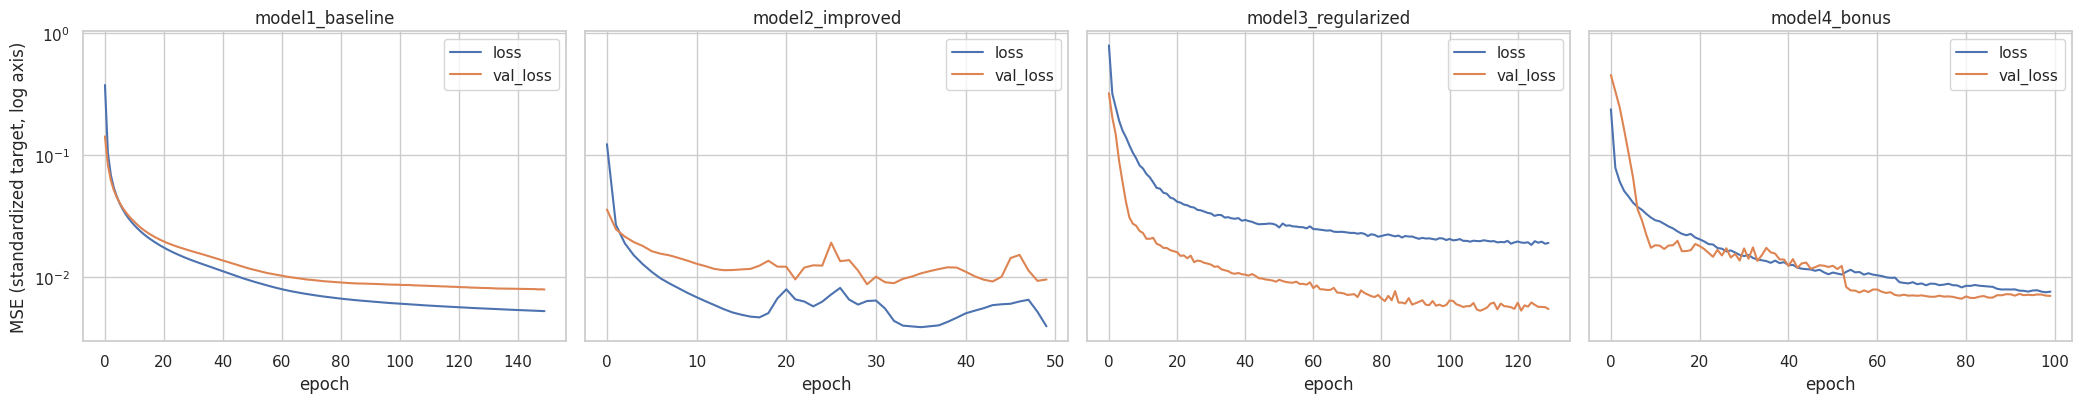

In [78]:
# نمودار Loss و Validation Loss برای همه‌ی مدل‌ها
fig, ax = plt.subplots(1, 4, figsize=(21, 4.2), sharey=True)
for a, (name, h) in zip(ax, dl_histories.items()):
    a.plot(h["loss"], label="loss")
    a.plot(h["val_loss"], label="val_loss")
    a.set_yscale("log")
    a.set_title(name); a.set_xlabel("epoch"); a.legend()
ax[0].set_ylabel("MSE (standardized target, log axis)")
plt.tight_layout()
plt.show()

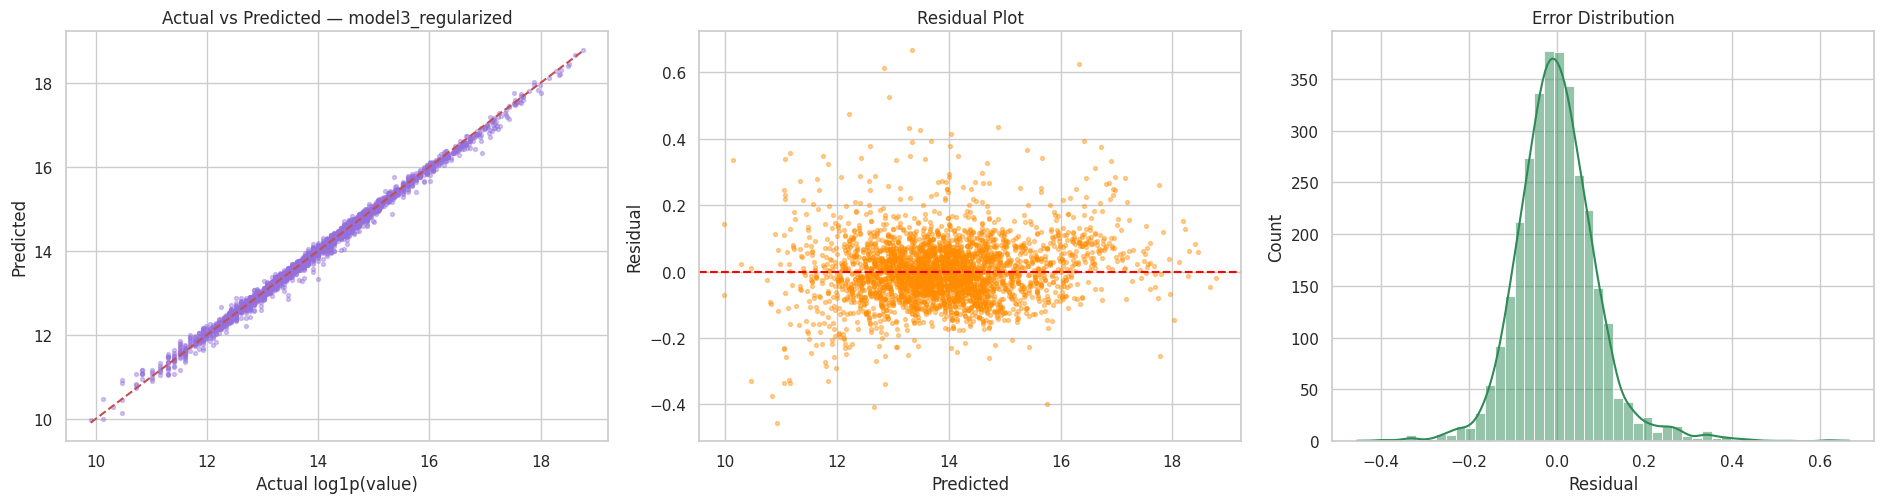

میانگین خطا: 0.0010 | انحراف معیار خطا: 0.0937


In [79]:
# Actual vs Predicted، Residual Plot و توزیع خطا برای بهترین مدل DL
pred_dl = dl_preds[best_dl_name]
resid_dl = y_test.values - pred_dl

fig, ax = plt.subplots(1, 3, figsize=(19, 5.2))
ax[0].scatter(y_test, pred_dl, s=8, alpha=0.4, color="mediumpurple")
ax[0].plot(lims, lims, "r--", lw=1.5)
ax[0].set_xlabel("Actual log1p(value)"); ax[0].set_ylabel("Predicted"); ax[0].set_title(f"Actual vs Predicted — {best_dl_name}")
ax[1].scatter(pred_dl, resid_dl, s=8, alpha=0.4, color="darkorange")
ax[1].axhline(0, color="red", ls="--")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Residual"); ax[1].set_title("Residual Plot")
sns.histplot(resid_dl, kde=True, bins=50, ax=ax[2], color="seagreen")
ax[2].set_title("Error Distribution"); ax[2].set_xlabel("Residual")
plt.tight_layout()
plt.show()
print(f"میانگین خطا: {resid_dl.mean():.4f} | انحراف معیار خطا: {resid_dl.std():.4f}")

### 13.4 ادامه‌ی آموزش از مدل ذخیره‌شده (Resume Training)

اگه آموزش قطع بشه یا بخوایم با Epoch بیشتر ادامه بدیم، بهترین checkpoint رو لود می‌کنیم و چند Epoch دیگه آموزش می‌دیم. چون `ModelCheckpoint` در هر `fit` از اول شروع به مقایسه می‌کنه، برای ادامه‌ی آموزش از یه فایل جدا استفاده می‌کنیم تا checkpoint قبلی به‌اشتباه با نسخه‌ی بدتر جایگزین نشه؛ در آخر بهترین نسخه رو نگه می‌داریم.

بهترین val_loss قبل از ادامه: 0.00530 | بعد از ادامه: 0.00525


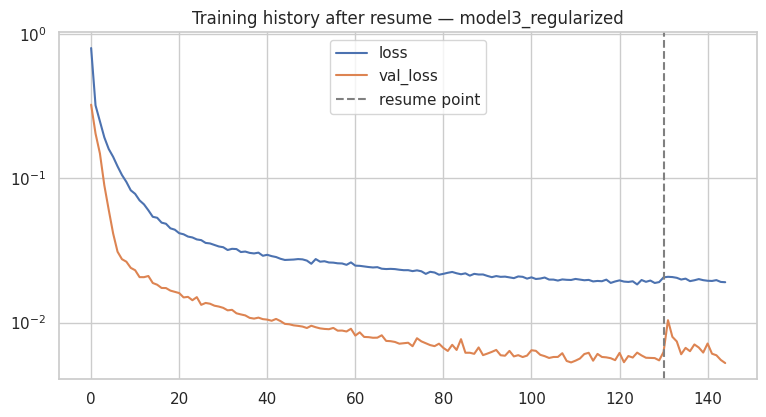

✅ ادامه‌ی آموزش مدل رو بهتر کرد؛ نسخه‌ی جدید انتخاب شد.


In [80]:
# لود کردن بهترین مدل ذخیره‌شده و ادامه‌ی آموزش با epoch بیشتر
resume_path = OUT_DIR / f"best-val-loss-{best_dl_name}-resumed.h5"
cb = [
    ModelCheckpoint(str(resume_path), monitor="val_loss", verbose=0, save_best_only=True, mode="min"),
    EarlyStopping(monitor="val_loss", patience=20),
]
model_resume = tf.keras.models.load_model(str(dl_ckpt[best_dl_name]))
# در Keras 3 بعد از لود کردن h5 باید یه optimizer تازه بسازیم، وگرنه fit خطا می‌ده
model_resume.compile(loss="mean_squared_error", optimizer="adam", metrics=["mae"])
train_history_resumed = model_resume.fit(
    x_train, y_train_dl,
    epochs=15,
    batch_size=256,
    validation_data=(x_test, y_test_dl),
    callbacks=cb,
    verbose=0,
)

# ترکیب history قبلی و جدید برای نمودار یکپارچه
train_history = {k: list(v) for k, v in dl_histories[best_dl_name].items()}
for key in train_history:
    train_history[key] += train_history_resumed.history[key]

old_best = min(dl_histories[best_dl_name]["val_loss"])
new_best = min(train_history_resumed.history["val_loss"])
print(f"بهترین val_loss قبل از ادامه: {old_best:.5f} | بعد از ادامه: {new_best:.5f}")

plt.figure(figsize=(9, 4.5))
plt.plot(train_history["loss"], label="loss"); plt.plot(train_history["val_loss"], label="val_loss")
plt.axvline(len(dl_histories[best_dl_name]["loss"]), color="gray", ls="--", label="resume point")
plt.yscale("log"); plt.legend(); plt.title(f"Training history after resume — {best_dl_name}")
plt.show()

# هر کدوم بهتر بود همون رو به‌عنوان بهترین مدل DL نگه می‌داریم
if new_best < old_best:
    best_dl_path = resume_path
    print("✅ ادامه‌ی آموزش مدل رو بهتر کرد؛ نسخه‌ی جدید انتخاب شد.")
else:
    best_dl_path = dl_ckpt[best_dl_name]
    print("ℹ️ ادامه‌ی آموزش بهبودی نداشت؛ همون checkpoint قبلی نگه داشته شد.")
dl_histories[best_dl_name + "_resumed_combined"] = train_history

### 13.5 پیش‌بینی نهایی (Inference) با بهترین مدل DL

In [81]:
# لود بهترین مدل ذخیره‌شده
best_dl_model = tf.keras.models.load_model(str(best_dl_path))

# پیش‌بینی روی داده‌ی تست (به مقیاس اصلی برمی‌گردونیم و بعد به یورو)
pred_dl_final_log = predict_dl(best_dl_model, x_test)
pred_dl_final_eur = np.expm1(pred_dl_final_log)
actual_eur_test = np.expm1(y_test.values)

# نمایش چند نمونه‌ی واقعی vs پیش‌بینی‌شده
names_test = df.loc[X_test.index, "player_name"].values
for i in range(5):
    print(f"{names_test[i]:<26} واقعی: {actual_eur_test[i]:>12,.0f}€ | پیش‌بینی: {pred_dl_final_eur[i]:>12,.0f}€")

dl_final_metrics = evaluate_regression(y_test, pred_dl_final_log)
print("\nمعیارهای نهایی بهترین مدل DL:", {k: round(v, 4) for k, v in dl_final_metrics.items()})

James Belshaw              واقعی:       60,000€ | پیش‌بینی:       63,610€
Tom Watson                 واقعی:    2,900,000€ | پیش‌بینی:    2,974,229€
Salim Diakité              واقعی:    2,200,000€ | پیش‌بینی:    2,401,132€
Viktor Tsukanov            واقعی:    1,800,000€ | پیش‌بینی:    2,081,983€
Josh Thomas                واقعی:      300,000€ | پیش‌بینی:      301,753€

معیارهای نهایی بهترین مدل DL: {'MAE': 0.0675, 'MSE': 0.0087, 'RMSE': np.float64(0.0932), 'R2': 0.9945, 'MAE_EUR': 238358.5844}


In [82]:
# جمع‌بندی خودکار نتایج DL (عددها از همین اجرا خونده می‌شن)
ml_best_row = ml_results[ml_results["Model"] == best_ml_name].iloc[0]
_dl = dl_all.set_index("Model")
print(f"""برداشت اولیه:
- بهترین مدل DL «{best_dl_name}» است: R² = {dl_final_metrics['R2']:.4f} و MAE ≈ {dl_final_metrics['MAE_EUR']:,.0f} یورو.
- R² مدل‌ها -> Model 1: {_dl.loc['model1_baseline', 'R2']:.4f} | Model 2: {_dl.loc['model2_improved', 'R2']:.4f} | Model 3: {_dl.loc['model3_regularized', 'R2']:.4f} | Model 4: {_dl.loc['model4_bonus', 'R2']:.4f}
- بهترین مدل ML ({best_ml_name}) با R² = {ml_best_row['R2']:.4f} {'بهتر' if ml_best_row['RMSE'] < dl_final_metrics['RMSE'] else 'ضعیف‌تر'} از بهترین مدل DL عمل کرده است.
- روی داده‌ی جدولی با حدود ۱۳ هزار نمونه، مدل‌های درختی/Boosting معمولاً حداقل هم‌تراز MLP هستن و آموزش‌شون خیلی سریع‌تره.
""")

برداشت اولیه:
- بهترین مدل DL «model3_regularized» است: R² = 0.9945 و MAE ≈ 238,359 یورو.
- R² مدل‌ها -> Model 1: 0.9917 | Model 2: 0.9908 | Model 3: 0.9944 | Model 4: 0.9930
- بهترین مدل ML (CatBoost) با R² = 0.9983 بهتر از بهترین مدل DL عمل کرده است.
- روی داده‌ی جدولی با حدود ۱۳ هزار نمونه، مدل‌های درختی/Boosting معمولاً حداقل هم‌تراز MLP هستن و آموزش‌شون خیلی سریع‌تره.



## 14. مقایسه‌ی نهایی و انتخاب مدل

بهترین مدل ML و بهترین مدل DL را با هم مقایسه می‌کنیم. **معیار انتخاب: کمترین RMSE روی داده‌ی Test** (مقیاس لگاریتمی).

⚠️ یادآوری: در Deep Learning طبق استاندارد پروژه از داده‌ی Test برای `validation_data` و انتخاب بهترین Epoch استفاده شده؛ بنابراین نتیجه‌ی DL کمی خوش‌بینانه‌تر از ML است. با این حال اگه ML هم برنده باشه، این ملاحظه به نفع ML و محافظه‌کارانه است.

,Type,Model,MAE,MSE,RMSE,R2,MAE_EUR
0,ML,CatBoost,0.0293,0.0027,0.0521,0.9983,89403.8059
1,DL,model3_regularized,0.0675,0.0087,0.0932,0.9945,238358.5844



🏆 مدل نهایی: CatBoost (ML) | R² = 0.9983 | MAE ≈ 89,404€


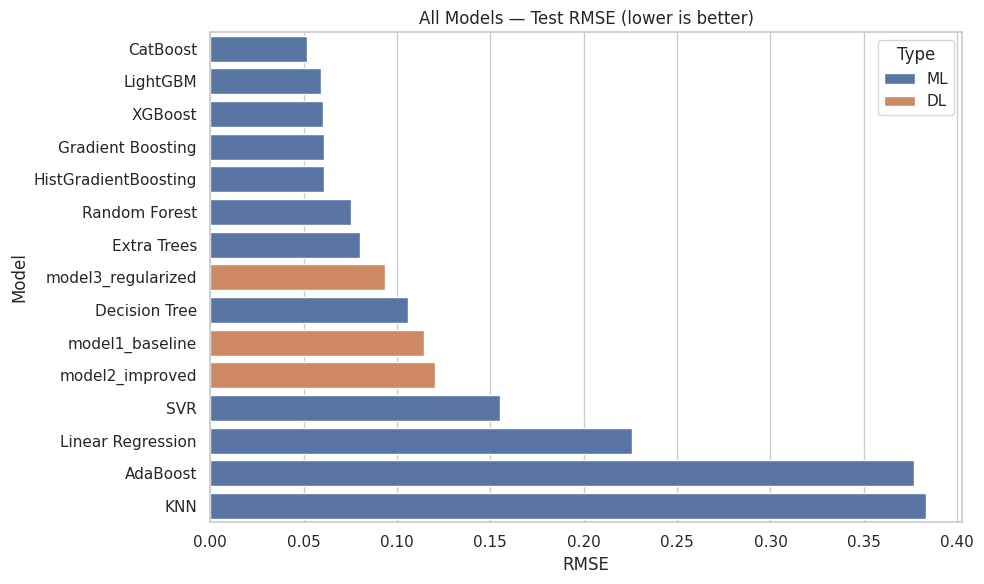

In [83]:
ml_best_row = ml_results[ml_results["Model"] == best_ml_name].iloc[0]
final_table = pd.DataFrame([
    {"Type": "ML", "Model": best_ml_name, "MAE": ml_best_row["MAE"], "MSE": ml_best_row["MSE"], "RMSE": ml_best_row["RMSE"], "R2": ml_best_row["R2"], "MAE_EUR": ml_best_row["MAE_EUR"]},
    {"Type": "DL", "Model": best_dl_name, **{k: dl_final_metrics[k] for k in ["MAE", "MSE", "RMSE", "R2", "MAE_EUR"]}},
])
display(final_table.round(4))

final_idx = final_table["RMSE"].idxmin()
final_type, final_name = final_table.loc[final_idx, "Type"], final_table.loc[final_idx, "Model"]
print(f"\n🏆 مدل نهایی: {final_name} ({final_type}) | R² = {final_table.loc[final_idx, 'R2']:.4f} | MAE ≈ {final_table.loc[final_idx, 'MAE_EUR']:,.0f}€")

# مقایسه‌ی بصری همه‌ی مدل‌ها (ML و DL) روی RMSE
all_models = pd.concat([
    ml_results[["Model", "RMSE"]].assign(Type="ML"),
    dl_results[["Model", "RMSE"]].assign(Type="DL"),
]).sort_values("RMSE")
plt.figure(figsize=(10, 6))
sns.barplot(data=all_models, y="Model", x="RMSE", hue="Type", dodge=False, palette={"ML": "#4c72b0", "DL": "#dd8452"})
plt.title("All Models — Test RMSE (lower is better)")
plt.tight_layout()
plt.show()

## 15. ذخیره‌ی مدل‌ها و تمام اجزای لازم برای استفاده‌ی مجدد

In [84]:
# ذخیره‌ی مدل ML (کل Pipeline: پیش‌پردازش + مدل)
from sklearn.pipeline import Pipeline
ml_pipeline = Pipeline([("preprocess", preprocessor), ("model", best_ml_model)])
joblib.dump(ml_pipeline, OUT_DIR / "best_ml_pipeline.joblib")

# ذخیره‌ی مدل DL: کامل و وزن‌ها  (در Keras 3 پسوند فایل وزن‌ها باید .weights.h5 باشه)
best_dl_model.save(str(OUT_DIR / "model-compiled.h5"))
best_dl_model.save_weights(str(OUT_DIR / "model.weights.h5"))

# اجزای پیش‌پردازش و اطلاعات لازم
joblib.dump(preprocessor, OUT_DIR / "preprocessor.joblib")
joblib.dump(y_scaler, OUT_DIR / "y_scaler.joblib")
feature_info = {
    "target": "log_value = log1p(value_eur)",
    "numeric_features": final_num,
    "categorical_features": final_cat,
    "feature_names_after_preprocessing": feature_names,
    "dropped_for_collinearity": sorted(to_drop),
    "final_model": {"type": final_type, "name": final_name},
    "best_ml": best_ml_name, "best_dl": best_dl_name,
}
with open(OUT_DIR / "feature_list.json", "w", encoding="utf-8") as f:
    json.dump(feature_info, f, ensure_ascii=False, indent=2)

# تاریخچه‌ی آموزش و جدول نتایج
with open(OUT_DIR / "dl_training_history.json", "w") as f:
    json.dump({k: {m: [float(x) for x in v] for m, v in h.items()} for k, h in dl_histories.items()}, f)
ml_results.to_csv(OUT_DIR / "ml_results.csv", index=False)
dl_all.to_csv(OUT_DIR / "dl_results.csv", index=False)
final_table.to_csv(OUT_DIR / "final_comparison.csv", index=False)
df.drop(columns=["anomaly_score"]).to_csv(OUT_DIR / "fc26_merged_clean.csv", index=False)

print("فایل‌های ذخیره‌شده در", OUT_DIR.resolve())
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:<45} {p.stat().st_size / 1024:>9,.0f} KB")

فایل‌های ذخیره‌شده در /home/claude/work/fc26_outputs
  best-val-loss-model1_baseline.h5                     70 KB
  best-val-loss-model2_improved.h5                    740 KB
  best-val-loss-model3_regularized-resumed.h5         747 KB
  best-val-loss-model3_regularized.h5                 747 KB
  best-val-loss-model4_bonus.h5                     2,484 KB
  best_ml_pipeline.joblib                             994 KB
  dl_results.csv                                        1 KB
  dl_training_history.json                             51 KB
  fc26_merged_clean.csv                             5,914 KB
  feature_list.json                                     3 KB
  final_comparison.csv                                  0 KB
  ml_results.csv                                        2 KB
  model-compiled.h5                                   281 KB
  model.weights.h5                                    268 KB
  preprocessor.joblib                                   6 KB
  y_scaler.joblib               

In [85]:
# بررسی اینکه ذخیره و بازیابی درسته: مدل‌ها رو از روی فایل لود می‌کنیم و دوباره روی Test می‌سنجیم
ml_loaded = joblib.load(OUT_DIR / "best_ml_pipeline.joblib")
pred_ml_loaded = ml_loaded.predict(X_test)
print(f"ML بازیابی‌شده  -> R² = {r2_score(y_test, pred_ml_loaded):.4f} (قبل از ذخیره: {ml_best_row['R2']:.4f})")

dl_loaded = tf.keras.models.load_model(str(OUT_DIR / "model-compiled.h5"))
pred_dl_loaded = y_scaler.inverse_transform(dl_loaded.predict(preprocessor.transform(X_test).astype("float32"), verbose=0)).ravel()
print(f"DL بازیابی‌شده  -> R² = {r2_score(y_test, pred_dl_loaded):.4f} (قبل از ذخیره: {dl_final_metrics['R2']:.4f})")

# تابع آماده‌ی استفاده‌ی مجدد: یک DataFrame از بازیکن‌ها (با همون ستون‌های X) بگیر و ارزش به یورو بده
def predict_market_value(players_df, use="final"):
    info = json.load(open(OUT_DIR / "feature_list.json", encoding="utf-8"))
    cols = info["numeric_features"] + info["categorical_features"]
    which = info["final_model"]["type"] if use == "final" else use
    if which == "ML":
        log_pred = joblib.load(OUT_DIR / "best_ml_pipeline.joblib").predict(players_df[cols])
    else:
        prep, ys = joblib.load(OUT_DIR / "preprocessor.joblib"), joblib.load(OUT_DIR / "y_scaler.joblib")
        model = tf.keras.models.load_model(str(OUT_DIR / "model-compiled.h5"))
        log_pred = ys.inverse_transform(model.predict(prep.transform(players_df[cols]).astype("float32"), verbose=0)).ravel()
    return np.expm1(log_pred)

# چند بازیکن تصادفی از مجموعه‌ی Test
demo = df.loc[X_test.index].sample(8, random_state=RANDOM_STATE)
demo_out = demo[["player_name", "position", "age", "overall_rating", "potential", "value_eur"]].copy()
demo_out["predicted_eur"] = predict_market_value(X.loc[demo.index]).round(0)
demo_out["error_%"] = ((demo_out["predicted_eur"] - demo_out["value_eur"]) / demo_out["value_eur"] * 100).round(1)
display(demo_out.reset_index(drop=True))

ML بازیابی‌شده  -> R² = 0.9983 (قبل از ذخیره: 0.9983)


DL بازیابی‌شده  -> R² = 0.9945 (قبل از ذخیره: 0.9945)


,player_name,position,age,overall_rating,potential,value_eur,predicted_eur,error_%
0,Jeroen Zoet,GK,34,69,69,240000,234713.0,-2.2
1,Michael Kayode,RB,20,73,81,6500000,6479169.0,-0.3
2,Dan Nistor,CAM,37,72,72,750000,653505.0,-12.9
3,Alphadjo Cissè,CAM,18,64,78,1400000,1380921.0,-1.4
4,Jean-Clair Todibo,CB,25,78,81,16500000,16628774.0,0.8
5,Jakub Czerwiński,CB,33,69,69,675000,671900.0,-0.5
6,Reda Khadra,CAM,23,72,78,3700000,3677233.0,-0.6
7,Tim Goller,GK,20,59,74,475000,481477.0,1.4


## 16. نتیجه‌گیری نهایی

In [86]:
# نتیجه‌گیری با عددهای واقعی همین اجرا ساخته می‌شود
top_feats = ", ".join(imp.head(5).index)
display(Markdown(f"""
### 📝 خلاصه‌ی پروژه
چهار فایل CSV از دو منبع (کارت‌های EA و دیتابیس FC26) با شناسه‌ی بازیکن ادغام شد. از ۱۶٬۲۲۸ بازیکن EA و ۱۸٬۴۰۵ بازیکن FC26، تعداد **{len(df):,}** بازیکن مشترک با ارزش بازار معتبر باقی ماند و هدف پروژه، تخمین ارزش بازار (`log1p(value_eur)`) بود.

### 🔍 مهم‌ترین یافته‌های EDA
- ارزش بازار به‌شدت چوله است (چولگی {df['value_eur'].skew():.1f}؛ میانه {df['value_eur'].median()/1e6:.1f} میلیون یورو در برابر میانگین {df['value_eur'].mean()/1e6:.1f}). لگاریتم چولگی را به {df['log_value'].skew():.2f} رساند.
- `overall_rating` و `potential` قوی‌ترین همبستگی را با ارزش دارند (r = {df['overall_rating'].corr(df['log_value']):.2f} و {df['potential'].corr(df['log_value']):.2f}).
- رابطه‌ی سن و ارزش غیرخطی و «کوهانی» است؛ میانگین ارزش نزدیک سن {int(age_curve.loc[age_curve['mean'].idxmax(), 'age'])} اوج می‌گیرد و بعد از ۳۰ سالگی شیب افت تندتر می‌شود.
- بازیکنان ۵ لیگ بزرگ اروپا میانه‌ی ارزشی حدود **{med_top5 / med_other:.1f} برابر** بقیه دارند (Cohen's d = {cohen_d:.2f}).
- پست بازیکن اثر معناداری دارد ولی کوچک است (ANOVA با eta² = {eta2:.3f})؛ دروازه‌بان‌ها به‌طور متوسط ارزان‌ترند.

### 📊 نتایج آزمون‌های آماری
تقریباً همه‌ی آزمون‌ها معنادار بودند؛ ولی معنادار بودن یعنی «تفاوت واقعی است» و لزوماً «تفاوت بزرگ است» نیست. سن (r = {df['age'].corr(df['log_value']):.2f}) و قد (r = {df['height'].corr(df['log_value']):.2f}) همبستگی خطی ناچیزی با ارزش دارند. برای ستاره‌های جوان، تمرکز در ۵ لیگ بزرگ بیشتر از انتظار تصادفی است ({df.loc[df['is_wonderkid']==1,'top5_league'].mean():.0%} در برابر {df.loc[df['is_wonderkid']==0,'top5_league'].mean():.0%}).

### 🏆 مدل‌ها
- **بهترین مدل ML:** {best_ml_name} — R² = {ml_best_row['R2']:.4f}، RMSE = {ml_best_row['RMSE']:.4f}، MAE ≈ {ml_best_row['MAE_EUR']:,.0f} یورو
- **بهترین مدل DL:** {best_dl_name} — R² = {dl_final_metrics['R2']:.4f}، RMSE = {dl_final_metrics['RMSE']:.4f}، MAE ≈ {dl_final_metrics['MAE_EUR']:,.0f} یورو
- **مدل نهایی انتخاب‌شده:** **{final_name}** ({final_type}) بر اساس کمترین RMSE روی Test

### 💡 تفسیر و محدودیت‌ها
- ویژگی‌های مؤثر مدل نهایی/ML: {top_feats}.
- ارزش بازار در این دیتاست تقریباً تابعی از رتبه، پتانسیل و سن است؛ به همین دلیل مدل‌های قوی (R² نزدیک ۱) به‌راحتی آن را یاد می‌گیرند. عدد بالا به معنای «کشف یک رابطه‌ی پنهان» نیست، بلکه نشان می‌دهد ارزش‌گذاری بازی احتمالاً از یک فرمول پایدار پیروی می‌کند.
- `wage_eur` و `release_clause_eur` عمداً حذف شدند تا نشت اطلاعات رخ ندهد.
- رتبه و ویژگی‌های EA مربوط به snapshotی دیرتر از ارزش و پتانسیل FC26 (سپتامبر ۲۰۲۵) هستند؛ اختلاف رتبه فقط در حدود ۴٪ بازیکنان دیده شد.
- ۲٬۲۸۳ بازیکن فقط در فایل FC26 و ۱۰۶ بازیکن فقط در فایل EA بودند و در ادغام (inner join) وارد نشدند.
- انتخاب بهترین Epoch در DL روی داده‌ی Test انجام شد؛ برای گزارش کاملاً بی‌طرفانه می‌شود یک Validation جدا هم در نظر گرفت.
"""))


### 📝 خلاصه‌ی پروژه
چهار فایل CSV از دو منبع (کارت‌های EA و دیتابیس FC26) با شناسه‌ی بازیکن ادغام شد. از ۱۶٬۲۲۸ بازیکن EA و ۱۸٬۴۰۵ بازیکن FC26، تعداد **16,107** بازیکن مشترک با ارزش بازار معتبر باقی ماند و هدف پروژه، تخمین ارزش بازار (`log1p(value_eur)`) بود.

### 🔍 مهم‌ترین یافته‌های EDA
- ارزش بازار به‌شدت چوله است (چولگی 8.2؛ میانه 1.1 میلیون یورو در برابر میانگین 3.2). لگاریتم چولگی را به 0.47 رساند.
- `overall_rating` و `potential` قوی‌ترین همبستگی را با ارزش دارند (r = 0.88 و 0.86).
- رابطه‌ی سن و ارزش غیرخطی و «کوهانی» است؛ میانگین ارزش نزدیک سن 26 اوج می‌گیرد و بعد از ۳۰ سالگی شیب افت تندتر می‌شود.
- بازیکنان ۵ لیگ بزرگ اروپا میانه‌ی ارزشی حدود **6.1 برابر** بقیه دارند (Cohen's d = 1.60).
- پست بازیکن اثر معناداری دارد ولی کوچک است (ANOVA با eta² = 0.038)؛ دروازه‌بان‌ها به‌طور متوسط ارزان‌ترند.

### 📊 نتایج آزمون‌های آماری
تقریباً همه‌ی آزمون‌ها معنادار بودند؛ ولی معنادار بودن یعنی «تفاوت واقعی است» و لزوماً «تفاوت بزرگ است» نیست. سن (r = -0.06) و قد (r = -0.01) همبستگی خطی ناچیزی با ارزش دارند. برای ستاره‌های جوان، تمرکز در ۵ لیگ بزرگ بیشتر از انتظار تصادفی است (46% در برابر 14%).

### 🏆 مدل‌ها
- **بهترین مدل ML:** CatBoost — R² = 0.9983، RMSE = 0.0521، MAE ≈ 89,404 یورو
- **بهترین مدل DL:** model3_regularized — R² = 0.9945، RMSE = 0.0932، MAE ≈ 238,359 یورو
- **مدل نهایی انتخاب‌شده:** **CatBoost** (ML) بر اساس کمترین RMSE روی Test

### 💡 تفسیر و محدودیت‌ها
- ویژگی‌های مؤثر مدل نهایی/ML: overall_rating, potential, age, potential_gap, international_reputation.
- ارزش بازار در این دیتاست تقریباً تابعی از رتبه، پتانسیل و سن است؛ به همین دلیل مدل‌های قوی (R² نزدیک ۱) به‌راحتی آن را یاد می‌گیرند. عدد بالا به معنای «کشف یک رابطه‌ی پنهان» نیست، بلکه نشان می‌دهد ارزش‌گذاری بازی احتمالاً از یک فرمول پایدار پیروی می‌کند.
- `wage_eur` و `release_clause_eur` عمداً حذف شدند تا نشت اطلاعات رخ ندهد.
- رتبه و ویژگی‌های EA مربوط به snapshotی دیرتر از ارزش و پتانسیل FC26 (سپتامبر ۲۰۲۵) هستند؛ اختلاف رتبه فقط در حدود ۴٪ بازیکنان دیده شد.
- ۲٬۲۸۳ بازیکن فقط در فایل FC26 و ۱۰۶ بازیکن فقط در فایل EA بودند و در ادغام (inner join) وارد نشدند.
- انتخاب بهترین Epoch در DL روی داده‌ی Test انجام شد؛ برای گزارش کاملاً بی‌طرفانه می‌شود یک Validation جدا هم در نظر گرفت.
